# Objective

This notebook computes the missing metrics identified in the `seleccion_modelos_v2` review:

1. **ICI at 6 and 12 months** (currently only ICI60 is available in existing notebooks)
2. **Dual metrics** for pending models (`formula_readmit`, `formula_readmit_updated`, `formula_death`, `formula_death_updated`, `formula_shap_death_interact`)
3. **DCA** (Decision Curve Analysis) for the primary models
4. **Consolidated table** with all metrics from all candidate models

It does not re-evaluate models that already have metrics computed in `prediction22` or `prediction24`; it only fills in the missing cells.

## 1. Setup: loading environment, functions, and data

In [1]:
#setwd("g:/My Drive/Alvacast/SISTRAT 2023/")

In [2]:
#| label: setup
#| message: false

# --- Identify project root ---
if (interactive()) {
  cwd <- getwd()
} else {
  cwd <- getwd()
}

project_root <- tryCatch({
  if (grepl("/cons$", cwd)) {
    dirname(cwd)

  } else if (grepl("\\\\cons$", cwd)) {
    dirname(cwd)
  } else if (file.exists(file.path(cwd, "cons"))) {
    cwd
  } else {
    # Search recursively
    candidate <- list.files(
      cwd,
      pattern = "pred2._ndp_.*\\.Rdata$",
      recursive = TRUE,
      full.names = TRUE
    )
    if (length(candidate) > 0) {
      dirname(dirname(candidate[1]))
    } else {
      cwd
    }
  }
}, error = function(e) cwd)

cat("Project root:", project_root, "\n")
setwd(project_root)

# Explicitly activate the main project renv (Jupyter kernels in cons/ may load cons/renv otherwise)
source(file.path(project_root, "renv", "activate.R"))

Project root: g:/My Drive/Alvacast/SISTRAT 2023 
- Project 'G:/My Drive/Alvacast/SISTRAT 2023' loaded. [renv 1.2.3]
The following package(s) are missing their DESCRIPTION files:
- desktop.ini [G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32/desktop.ini]
These may be left over from a prior, failed installation attempt.
Consider removing or reinstalling these packages.


NOTE: Dependency discovery took 21 seconds during snapshot using current .renvignore specifications.
Consider modifying .renvignore or switching to explicit snapshots.
See `?renv::dependencies` for more information.

- The project is out-of-sync -- use `renv::status()` for details.


In [3]:
#| label: load-data
#| message: false                                                                                                                       
.t0_load <- proc.time()                                                                                                                      
# Load the canonical prediction22 input that matches the validated primary common-grid OOF cache.                                       
canonical_rdata <- file.path(project_root, "data", "20241015_out", "pred22_ndp_2026_07_13.Rdata")                                       
if (!file.exists(canonical_rdata)) stop("Canonical prediction22 RData is missing: ", canonical_rdata, call. = FALSE)                    
loaded_names <- load(canonical_rdata, envir = .GlobalEnv)                                                                               
if (!exists("py_corrected_datasets_boot", envir = .GlobalEnv, inherits = FALSE)) stop("The canonical RData did not create               
py_corrected_datasets_boot.", call. = FALSE)                                                                                            
if (!exists("formula_death_updated2", envir = .GlobalEnv, inherits = FALSE)) stop("The canonical RData did not create                   
formula_death_updated2.", call. = FALSE)                                                                                                
if (!is.list(py_corrected_datasets_boot) || length(py_corrected_datasets_boot) != 5L) stop("Expected exactly five imputations in        
py_corrected_datasets_boot.", call. = FALSE)                                                                                            
required_outcome_columns <- c("readmit_time_from_disch_m", "readmit_event", "death_time_from_disch_m", "death_event")                   
missing_outcome_columns <- lapply(py_corrected_datasets_boot, function(data_imp) setdiff(required_outcome_columns, names(data_imp)))    
if (any(lengths(missing_outcome_columns) > 0L)) {                                                                                       
  detail <- paste(vapply(which(lengths(missing_outcome_columns) > 0L), function(i) sprintf("imputation %d: %s", i,                      
  paste(missing_outcome_columns[[i]], collapse = ", ")), character(1)), collapse = "; ")                                                
  stop("Canonical imputations are missing required outcome columns: ", detail, call. = FALSE)                                           
}                                                                                                                                       
input_rows <- vapply(py_corrected_datasets_boot, nrow, integer(1))                                                                      
if (length(unique(input_rows)) != 1L) stop("Canonical imputations do not have identical row counts: ", paste(input_rows, collapse = ",  
"), call. = FALSE)                                                                                                                      
reference_outcomes <- py_corrected_datasets_boot[[1L]][required_outcome_columns]                                                        
outcomes_match <- vapply(py_corrected_datasets_boot[-1L], function(data_imp) {                                                          
  all(vapply(required_outcome_columns, function(column_name) isTRUE(all.equal(data_imp[[column_name]],                                  
  reference_outcomes[[column_name]], tolerance = 0, check.attributes = FALSE)), logical(1)))                                            
}, logical(1))                                                                                                                          
if (length(outcomes_match) > 0L && !all(outcomes_match)) stop("Outcome or follow-up values differ across canonical imputations.", call. 
= FALSE)                                                                                                                                
.p225_input_rdata <- normalizePath(canonical_rdata, winslash = "/", mustWork = TRUE)                                                    
.p225_input_manifest <- list(path = .p225_input_rdata, imputations = length(py_corrected_datasets_boot), rows_per_imputation =          
input_rows[1L], outcome_columns = required_outcome_columns)                                                                             
cat("Loaded canonical prediction22 input:", .p225_input_rdata, "\n")                                                                    
cat("Loaded objects:", length(loaded_names), "| imputations:", .p225_input_manifest$imputations, "| rows per                            
imputation:", .p225_input_manifest$rows_per_imputation, "\n")                                                                           
.elapsed <- (proc.time() - .t0_load)[["elapsed"]] / 60                                                                                       
cat(sprintf("[chunk: load-data] %.3f min\n", .elapsed))

Loaded canonical prediction22 input: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred22_ndp_2026_07_13.Rdata 
Loaded objects: 477 | imputations: 5 | rows per                            
imputation: 70521 
[chunk: load-data] 1.686 min


In [4]:
#| label: define-formulas
#| message: false

# --- Check which formulas are available in the environment ---
formula_names <- c(
  "formula_readmit", "formula_readmit_updated", "formula_readmit_updated2",
  "formula_death", "formula_death_updated", "formula_death_updated2",
  "formula_shap_readmit_clean", "formula_shap_readmit_clean_updated",
  "formula_shap_death_rule2",
  "formula_shap_readmit_interact", "formula_shap_death_interact"
)

for (fn in formula_names) {
  if (exists(fn)) {
    f <- get(fn)
    if (inherits(f, "formula")) {
      cat(sprintf("  [OK] %s\n", fn))
    } else {
      cat(sprintf("  [WARN] %s exists but is not a formula\n", fn))
    }
  } else {
    cat(sprintf("  [MISS] %s NOT in environment\n", fn))
  }
}
# For missing ones, define them from the prediction22 notebook
if (!exists("formula_readmit")) {
  warning("formula_readmit not available. Check the .Rdata file.")
}
if (!exists("formula_death")) {
  warning("formula_death not available. Check the .Rdata file.")
}

  [OK] formula_readmit
  [OK] formula_readmit_updated
  [OK] formula_readmit_updated2
  [OK] formula_death
  [OK] formula_death_updated
  [OK] formula_death_updated2
  [OK] formula_shap_readmit_clean
  [OK] formula_shap_readmit_clean_updated
  [OK] formula_shap_death_rule2
  [OK] formula_shap_readmit_interact
  [OK] formula_shap_death_interact


In [5]:
#| label: load-libraries
#| message: false

# --- Configure parallel plan ---
library(future)
library(future.apply)
library(survival)
library(ggplot2)
library(readr)
library(tableone)
library(survivalmodels)
#renv::install("patchwork@1.2.0")
library(rms)
library(survidm)
library(caret)
library(survival)
library(caret)
library(dplyr)
library(survex)
library(pec)
library(parallel)
library(mice)
library(riskRegression)
library(tidyr)
library(doFuture)
library(vcd)
library(survAUC)

gc()


Attaching package: ‘survival’

The following object is masked from ‘package:future’:

    cluster

Loading required package: Hmisc

Attaching package: ‘Hmisc’

The following objects are masked from ‘package:base’:

    format.pval, units



Warning message:
package ‘Hmisc’ was built under R version 4.4.3 


Loading required package: lattice

Attaching package: ‘caret’

The following object is masked from ‘package:survival’:

    cluster

The following object is masked from ‘package:future’:

    cluster


Attaching package: ‘dplyr’

The following objects are masked from ‘package:Hmisc’:

    src, summarize

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘survex’

The following object is masked from ‘package:dplyr’:

    explain

Loading required package: prodlim

Attaching package: ‘pec’

The following object is masked from ‘package:caret’:

    R2

The following object is masked from ‘package:survivalmodels’:

    cindex



Warning message:
package ‘prodlim’ was built under R version 4.4.3 



Attaching package: ‘mice’

The following object is masked from ‘package:stats’:

    filter

The following objects are masked from ‘package:base’:

    cbind, rbind

Registered S3 method overwritten by 'riskRegression':
  method        from 
  nobs.multinom broom
riskRegression version 2026.02.13

Attaching package: ‘riskRegression’

The following objects are masked from ‘package:pec’:

    ipcw, selectCox

Loading required package: foreach
Loading required package: grid


             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    9834394   525.3   16934634   904.5   14078862   751.9
Vcells 2499133578 19066.9 3106755207 23702.7 2508427090 19137.8

In [6]:
#| label: source-functions
#| message: false

.t0 <- proc.time()

# --- Source required functions (if not already in the environment) ---

# The actual calibration function is called calibrate_cscox_aj_grouped_corr
# (NOT calibrate_cph_grouped_corr)
source(
  file.path(gsub("/cons","",getwd()), 
    "cons",
    "_alt_scripts",
    "calibrate_cscox_aj_grouped_corr.R")
)
cat("Sourced: calibrate_cscox_aj_grouped_corr (corrected in 2026-07-13\n")

source(
  file.path(gsub("/cons","",getwd()), 
    "cons",
    "_alt_scripts",
    "evaluate_dual_cox_python_style_boot.R")
)
cat("Sourced: evaluate_dual_cox_python_style (corrected in 2026-07-13)\n")

source(
  file.path(gsub("/cons","",getwd()),
    "cons",
    "_alt_scripts",
    "recompute_dual_cox_ibs_from_raw.R")
)
assert_ordered_ipcw_engine()

# Verify essential functions
stopifnot(exists("calibrate_cscox_aj_grouped_corr"))
stopifnot(exists("evaluate_dual_cox_python_style"))
stopifnot(exists("recompute_dual_cox_ibs_from_raw"))
cat("Functions ready with ordered patient-time IPCW lookup.\n")
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60
cat(sprintf("[chunk: source-functions] %.3f min\n", .elapsed))

Sourced: calibrate_cscox_aj_grouped_corr (corrected in 2026-07-13
Sourced: evaluate_dual_cox_python_style (corrected in 2026-07-13)
Functions ready with ordered patient-time IPCW lookup.
[chunk: source-functions] 0.001 min


In [7]:
#| label: deltaCIBS-cv-engine
#| message: false

.t0 <- proc.time()

# --- fallbacks (idÃƒÂ©nticos al pipeline; se saltan si ya existen) ---
if (!exists(".dual_cox_safe_concordance")) .dual_cox_safe_concordance <- function(time,event,lp,ymax=NULL){
  ok<-is.finite(time)&is.finite(event)&is.finite(lp); if(sum(ok)<2L) return(NA_real_)
  a<-list(survival::Surv(time[ok],event[ok])~lp[ok],timewt="n/G2",reverse=TRUE); if(!is.null(ymax)) a$ymax<-ymax
  tryCatch(do.call(survival::concordance,a)$concordance,error=function(e) NA_real_) }
.delta_ibs_G_ordered <- function(sf,tt,g_min=.05){
  requested_times<-pmax(as.numeric(tt),0); unique_times<-sort(unique(requested_times))
  g_unique<-as.numeric(summary(sf,times=unique_times,extend=TRUE)$surv)
  if(length(g_unique)!=length(unique_times)) stop("Unexpected censoring-survival lookup length.")
  lookup_index<-match(requested_times,unique_times)
  if(anyNA(lookup_index)) stop("Could not restore patient-time order in IPCW lookup.")
  pmax(g_unique[lookup_index],g_min) }
.ibs_prep <- function(tr_time,tr_event,te_time,eval_times,g_min=.05,eps=1e-8){
  ev<-as.numeric(tr_event); ev[is.na(ev)]<-0; sf<-survival::survfit(survival::Surv(tr_time,1-ev)~1)
  safe<-sf$time[sf$surv>=g_min]; tau<-if(length(safe)) max(safe) else max(eval_times)
  keep<-eval_times<=tau & eval_times<=max(tr_time,na.rm=TRUE); tu<-eval_times[keep]
  Gat<-function(tt) .delta_ibs_G_ordered(sf,tt,g_min)
  list(times_use=tu,keep=keep,gt0=if(length(tu)) 1/Gat(tu) else numeric(0),gT=1/Gat(pmax(te_time-eps,0))) }
ibs_fast <- function(S_keep,te_time,te_event,idx,prep){
  tu<-prep$times_use; if(length(tu)<2L) return(NA_real_)
  Tt<-te_time[idx]; Dt<-te_event[idx]; gT<-prep$gT[idx]; S<-S_keep[idx,,drop=FALSE]
  bs<-vapply(seq_along(tu),function(j){t0<-tu[j];S0<-S[,j];ar<-Tt>t0;fl<-(!ar)&(Dt==1)
    w<-numeric(length(Tt)); w[ar]<-prep$gt0[j]*(1-S0[ar])^2; w[fl]<-gT[fl]*(S0[fl])^2; mean(w,na.rm=TRUE)},numeric(1))
  den<-max(tu)-min(tu); if(!is.finite(den)||den<=0) return(NA_real_)
  sum(diff(tu)*(head(bs,-1L)+tail(bs,-1L))/2)/den }

# --- reassemble OOF across folds -> per-subject, pooled over imputations ---
.cv_extract <- function(res, outcome = c("readmission","death")) {
  outcome <- match.arg(outcome)
  rp <- res$raw_predictions
  if (is.null(rp) || !length(rp)) stop("no raw_predictions (objeto strippeado o calibracion, no dual eval)")
  cfg <- res$config; et <- as.numeric(cfg$eval_times)
  N <- max(vapply(rp, function(b) max(b$original_val_idx), 1L))
  imps <- sort(unique(vapply(rp, function(b) b$imp_idx, 1L)))
  time_v <- rep(NA_real_,N); event_v <- rep(NA_real_,N); lp_imp <- list(); S_imp <- list()
  for (im in imps) {
    lp <- rep(NA_real_,N); S <- matrix(NA_real_,N,length(et))
    for (b in rp) { if (b$imp_idx!=im) next
      o <- b[[outcome]]; if (is.null(o)||!is.null(o$error)||is.null(o$lp_val)) next
      idx <- b$original_val_idx; lp[idx] <- as.numeric(o$lp_val); S[idx,] <- as.matrix(o$surv_val_matrix)
      yv <- o$y_val; time_v[idx] <- as.numeric(yv[,1]); event_v[idx] <- as.numeric(yv[,2]) }
    lp_imp[[length(lp_imp)+1L]] <- lp; S_imp[[length(S_imp)+1L]] <- S }
  list(time=time_v, event=event_v, lp=Reduce(`+`,lp_imp)/length(lp_imp),
       S=Reduce(`+`,S_imp)/length(S_imp), eval_times=et)
}

# --- paired bootstrap on already-extracted markers (align A,Z on common finite subjects) ---
deltaC_boot_x <- function(A, Z, B=2000L, seed=2125L, ymax=NULL) {
  ok <- is.finite(A$lp)&is.finite(Z$lp)&is.finite(A$time)&is.finite(A$event)
  ti<-A$time[ok]; ev<-A$event[ok]; la<-A$lp[ok]; lz<-Z$lp[ok]; n<-sum(ok); i0<-seq_len(n)
  cc <- function(m,idx) .dual_cox_safe_concordance(ti[idx],ev[idx],m[idx],ymax)
  cA<-cc(la,i0); cZ<-cc(lz,i0); set.seed(seed); d<-numeric(B)
  for (b in seq_len(B)) { idx<-sample.int(n,n,TRUE); d[b]<-cc(la,idx)-cc(lz,idx) }
  q<-quantile(d,c(.025,.975),na.rm=TRUE,names=FALSE)
  data.frame(C_A=round(cA,4),C_B=round(cZ,4),dC=round(cA-cZ,4),
             dC_lo=round(q[1],4),dC_hi=round(q[2],4),excludes_0=isTRUE(q[1]>0||q[2]<0),n=n) }
deltaIBS_boot_x <- function(A, Z, B=2000L, seed=2125L) {
  ok <- is.finite(A$lp)&is.finite(Z$lp)&is.finite(A$time)&is.finite(A$event) &
        rowSums(is.finite(A$S))==ncol(A$S) & rowSums(is.finite(Z$S))==ncol(Z$S)
  ti<-A$time[ok]; ev<-A$event[ok]; SA<-A$S[ok,,drop=FALSE]; SZ<-Z$S[ok,,drop=FALSE]
  prep<-.ibs_prep(ti,ev,ti,A$eval_times)                 # G del censurado de la cohorte OOF
  SAk<-SA[,prep$keep,drop=FALSE]; SZk<-SZ[,prep$keep,drop=FALSE]; n<-nrow(SAk); i0<-seq_len(n)
  iA<-ibs_fast(SAk,ti,ev,i0,prep); iZ<-ibs_fast(SZk,ti,ev,i0,prep); set.seed(seed); d<-numeric(B)
  for (b in seq_len(B)) { idx<-sample.int(n,n,TRUE); d[b]<-ibs_fast(SAk,ti,ev,idx,prep)-ibs_fast(SZk,ti,ev,idx,prep) }
  q<-quantile(d,c(.025,.975),na.rm=TRUE,names=FALSE)
  data.frame(IBS_A=round(iA,4),IBS_B=round(iZ,4),dIBS=round(iA-iZ,4),
             dIBS_lo=round(q[1],4),dIBS_hi=round(q[2],4),excludes_0=isTRUE(q[1]>0||q[2]<0),n=n) }

# Behavioral guard: patient order must not change the censoring lookup.
.sf_guard<-survival::survfit(survival::Surv(c(1,2,3,4),c(1,0,1,0))~1)
.tt_guard<-c(3,1,3,2); .ord_guard<-order(.tt_guard)
stopifnot(identical(.delta_ibs_G_ordered(.sf_guard,.tt_guard),
  .delta_ibs_G_ordered(.sf_guard,.tt_guard[.ord_guard])[match(seq_along(.tt_guard),.ord_guard)]))
rm(.sf_guard,.tt_guard,.ord_guard)
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60
cat(sprintf("[chunk: deltaCIBS-cv-engine] %.3f min\n", .elapsed))


[chunk: deltaCIBS-cv-engine] 0.000 min


### Historical IBS outputs

> **Do not cite the stored IBS outputs in the exploratory cells below.** They were generated before the patient-time ordering repair and remain only as execution history. Use the corrected common-grid results regenerated in the final Delta IBS section.

In [8]:
# label: run-evaluation2-fullph

# risk_absolute (stratum-correct, coherent with IBS/calibration/DCA)
# within_stratum (sensitivity; may be NA/low-n for death)
options(dualcox.concordance_score = "lp", dualcox.concordance_within_strata = TRUE)
# options(dualcox.concordance_score = "risk", dualcox.concordance_within_strata = FALSE)

results_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit,
  formula_death = formula_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0534032| 0.0014173| 0.0514323| 0.0558807| 25|
|Readmission |IBS           |12     | 0.0728070| 0.0013783| 0.0703098| 0.0753324| 25|
|Readmission |IBS           |36     | 0.1133118| 0.0010548| 0.1111618| 0.1151366| 25|
|Readmission |IBS           |60     | 0.1376630| 0.0008071| 0.1360552| 0.1389660| 25|
|Readmission |IBS           |Global | 0.1376630| 0.0008071| 0.1360552| 0.1389660| 25|
|Readmission |Uno's C-Index |6      | 0.5870985| 0.0089619| 0.5716340| 0.6029651| 25|
|Readmission |Uno's C-Index |12     | 0.5870590| 0.0050327| 0.5795958| 0.5962161| 25|
|Readmission |Uno's C-Index |36     | 0.5861664| 0.0049506| 0.5764967| 0.5945005| 25|
|Readmission |Uno's C-Index |60     | 0.5859021| 0.0056582| 0.5771597| 0.5974242| 25|
|Readmission 

In [9]:
# label: run-evaluation2-fullph-discarding-collinearity

results_upd_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated,
  formula_death = formula_death_updated,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_upd_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary (discarded collinearity)")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary (discarded collinearity)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0534030| 0.0014176| 0.0514324| 0.0558811| 25|
|Readmission |IBS           |12     | 0.0728063| 0.0013786| 0.0703095| 0.0753326| 25|
|Readmission |IBS           |36     | 0.1133085| 0.0010568| 0.1111496| 0.1151360| 25|
|Readmission |IBS           |60     | 0.1376581| 0.0008099| 0.1360505| 0.1389645| 25|
|Readmission |IBS           |Global | 0.1376581| 0.0008099| 0.1360505| 0.1389645| 25|
|Readmission |Uno's C-Index |6      | 0.5871915| 0.0090248| 0.5716350| 0.6033183| 25|
|Readmission |Uno's C-Index |12     | 0.5871645| 0.0050346| 0.5797173| 0.5965309| 25|
|Readmission |Uno's C-Index |36     | 0.5862684| 0.0050128| 0.5764972| 0.5948705| 25|
|Readmission |Uno's C-Index |60     | 0.5859709| 0.0057211| 0.5771192| 0.5

In [10]:
# label: run-evaluation2-fullph-with-additional-strata

results_upd2_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_readmit_updated2,
  formula_death = formula_death_updated2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

results_upd2_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated predictors (+ strata)")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, updated predictors (+ strata)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0533454| 0.0014343| 0.0513294| 0.0558740| 25|
|Readmission |IBS           |12     | 0.0727663| 0.0013881| 0.0702669| 0.0753417| 25|
|Readmission |IBS           |36     | 0.1132885| 0.0010587| 0.1111236| 0.1151251| 25|
|Readmission |IBS           |60     | 0.1376181| 0.0008128| 0.1360004| 0.1389276| 25|
|Readmission |IBS           |Global | 0.1376181| 0.0008128| 0.1360004| 0.1389276| 25|
|Readmission |Uno's C-Index |6      | 0.5832599| 0.0091966| 0.5676566| 0.5984606| 25|
|Readmission |Uno's C-Index |12     | 0.5844583| 0.0050423| 0.5760550| 0.5926981| 25|
|Readmission |Uno's C-Index |36     | 0.5850535| 0.0046773| 0.5755853| 0.5915328| 25|
|Readmission |Uno's C-Index |60     | 0.5853690| 0.0055623| 0.576985

In [11]:
# label: run-evaluation2-shap-based-before-additional-strata

results_shap_xgb_py_within <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_rule,
  formula_death = formula_shap_death_rule,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_shap_xgb_py_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, SHAP informed predictors")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, SHAP informed predictors

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0533856| 0.0014197| 0.0514276| 0.0558687| 25|
|Readmission |IBS           |12     | 0.0727742| 0.0013812| 0.0702674| 0.0753040| 25|
|Readmission |IBS           |36     | 0.1132926| 0.0010510| 0.1111425| 0.1150938| 25|
|Readmission |IBS           |60     | 0.1376575| 0.0007873| 0.1361435| 0.1389509| 25|
|Readmission |IBS           |Global | 0.1376575| 0.0007873| 0.1361435| 0.1389509| 25|
|Readmission |Uno's C-Index |6      | 0.5911263| 0.0095610| 0.5733255| 0.6078961| 25|
|Readmission |Uno's C-Index |12     | 0.5900761| 0.0051568| 0.5816305| 0.5984275| 25|
|Readmission |Uno's C-Index |36     | 0.5859842| 0.0050405| 0.5768574| 0.5938096| 25|
|Readmission |Uno's C-Index |60     | 0.5859225| 0.0056580| 0.5775526| 0.

In [12]:
# label: run-evaluation2-interactions

results_shap_xgb_py_upd_int2 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_readmit_interact,
  formula_death = formula_shap_death_interact,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6,12,36,60)
)

results_shap_xgb_py_upd_int2$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, SHAP + interactions")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....




Table: Global C-index and IBS summary, SHAP + interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0533262| 0.0014334| 0.0513348| 0.0558459| 25|
|Readmission |IBS           |12     | 0.0727269| 0.0013889| 0.0702128| 0.0752969| 25|
|Readmission |IBS           |36     | 0.1132611| 0.0010631| 0.1110786| 0.1151071| 25|
|Readmission |IBS           |60     | 0.1375996| 0.0008099| 0.1360873| 0.1389612| 25|
|Readmission |IBS           |Global | 0.1375996| 0.0008099| 0.1360873| 0.1389612| 25|
|Readmission |Uno's C-Index |6      | 0.5881848| 0.0109552| 0.5692834| 0.6064602| 25|
|Readmission |Uno's C-Index |12     | 0.5881674| 0.0051418| 0.5805088| 0.5977172| 25|
|Readmission |Uno's C-Index |36     | 0.5850330| 0.0046766| 0.5763632| 0.5918494| 25|
|Readmission |Uno's C-Index |60     | 0.5855091| 0.0055028| 0.5774606| 0.59709

In [13]:
# label: run-evaluation2-last-models

results_shap_add_strata_xgb_py2_within <- evaluate_dual_cox_python_style(
  formula_readmit = as.formula(gsub("strat\\(", "strata(", deparse(formula_shap_readmit_clean_updated))),  # Original formula with months variable,
  formula_death = formula_shap_death_rule2,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
#Keep lp_global (0.7424 / 0.6045); report "absolute-risk C identical,
# ÃŽâ€=0 Ã¢â€ â€™ discrimination coherent with the risk-based metrics."
results_shap_add_strata_xgb_py2_within$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, last models (SHAP + strata)")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....


Warning message:
In formula.character(object, env = baseenv()) :
  Using formula(x) is deprecated when x is a character vector of length > 1.
  Consider formula(paste(x, collapse = " ")) instead.




Table: Global C-index and IBS summary, last models (SHAP + strata)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0533284| 0.0014345| 0.0513301| 0.0558514| 25|
|Readmission |IBS           |12     | 0.0727348| 0.0013891| 0.0702276| 0.0753051| 25|
|Readmission |IBS           |36     | 0.1132732| 0.0010546| 0.1111125| 0.1150869| 25|
|Readmission |IBS           |60     | 0.1376185| 0.0007944| 0.1360865| 0.1389213| 25|
|Readmission |IBS           |Global | 0.1376185| 0.0007944| 0.1360865| 0.1389213| 25|
|Readmission |Uno's C-Index |6      | 0.5877958| 0.0101468| 0.5694614| 0.6041984| 25|
|Readmission |Uno's C-Index |12     | 0.5879562| 0.0051884| 0.5794432| 0.5963556| 25|
|Readmission |Uno's C-Index |36     | 0.5850573| 0.0048066| 0.5757736| 0.5917614| 25|
|Readmission |Uno's C-Index |60     | 0.5854649| 0.0054528| 0.5772727|

In [14]:
# label: run-evaluation2-close-options

# put back to risk score

options(dualcox.concordance_score = "risk", 
dualcox.concordance_within_strata = FALSE)


## 2. ICI at 6, 12, 36, and 60 months

The `calibrate_cscox_aj_grouped_corr` function computes grouped calibration + ICI for readmission
(with death as a competing event, using CSC + Aalen-Johansen).
It already computes ICI at the horizons specified in `ici_times`.

**Missing:** ICI at 6 months (and explicit 12 months) for the main models.

> **Note:** Each call is computationally intensive (~20 reps Ãƒâ€” 5 folds Ãƒâ€” 5 imputations).
We use `n_repeats = 20` for the final version.



In [15]:
#| label: define-settings
#| message: false
# # --- Calibration parameters ---
# Include 6m as a new horizon, plus 12, 36, 60 # 2026-05-22, discarded= 96
CAL_TIMES <- c(6, 12, 36, 60)
CAL_ICI_TIMES <- c(6, 12, 36, 60)  # ICI at clinically relevant horizons
CAL_N_REPEATS <- 20  # Final version # 2026-05-22, reduced to 10 for time constraints


In [16]:
#| label: ici-preprocess-formula
#| message: false

formula_shap_readmit_clean_updated <-
as.formula(
  gsub(
    "strat\\(",
    "strata(",
    paste(deparse(formula_shap_readmit_clean_updated), collapse = " ")
  )
)

In [17]:
#| label: ici-readmit-models
#| message: true                                                                                                                        
#| warning: true                                                                                                                        
.t0 <- proc.time()                                                                                                                      
# Run readmission calibration with one controlled parallel layer and explicit paired mortality formulas.                                
if (!exists("calibrate_cscox_aj_grouped_corr", mode = "function", inherits = TRUE)) stop("Run source-functions before this chunk.",     
call. = FALSE)                                                                                                                          
if (!exists("py_corrected_datasets_boot", envir = .GlobalEnv, inherits = FALSE)) stop("Run load-data before this chunk.", call. = FALSE)
if (!exists("CAL_TIMES", inherits = TRUE) || !exists("CAL_ICI_TIMES", inherits = TRUE) || !exists("CAL_N_REPEATS", inherits = TRUE))
  stop("CAL_TIMES, CAL_ICI_TIMES, and CAL_N_REPEATS must be defined before this chunk.", call. = FALSE)

required_packages <- c("future", "future.apply", "survival", "riskRegression", "prodlim")                                               
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]                         
if (length(missing_packages) > 0L) stop("Missing required package(s): ", paste(missing_packages, collapse = ", "), call. = FALSE)       
if (!"package:survival" %in% search()) suppressPackageStartupMessages(library(survival))                                                
required_formulas <- c("formula_shap_readmit_clean_updated", "formula_shap_death_rule2", "formula_readmit_updated2",                    
"formula_death_updated2", "formula_shap_readmit_interact", "formula_shap_death_interact", "formula_readmit", "formula_death",           
"formula_readmit_updated", "formula_death_updated")                                                                                     
missing_formulas <- required_formulas[!vapply(required_formulas, exists, logical(1), envir = .GlobalEnv, inherits = FALSE)]             
if (length(missing_formulas) > 0L) stop("Missing required formula object(s): ", paste(missing_formulas, collapse = ", "), call. = FALSE)
invalid_formulas <- required_formulas[!vapply(required_formulas, function(object_name) inherits(get(object_name, envir = .GlobalEnv, inherits = FALSE), "formula"), logical(1))]
                                                                                           
if (length(invalid_formulas) > 0L) stop("The following objects are not formulas: ", paste(invalid_formulas, collapse = ", "), call. =   
FALSE)                                                                                                                                  
.p225_calibration_workers <- function() {                                                                                               
  detected_cores <- suppressWarnings(parallel::detectCores(logical = TRUE))                                                             
  if (!is.finite(detected_cores) || detected_cores < 1L) {                                                                              
    detected_cores <- 4L                                                                                                                
  }                                                                                                                                     
  local_powerful_profile <- identical(as.character(getRversion()), "4.4.1") && detected_cores >= 10L                                    
  if (exists("sistrat_env_profile", envir = .GlobalEnv, inherits = FALSE)) {                                                            
    local_powerful_profile <- local_powerful_profile && identical(get("sistrat_env_profile", envir = .GlobalEnv), "renv_local")         
  }                                                                                                                                     
  workers <- if (local_powerful_profile) {                                                                                              
    min(12L, max(1L, detected_cores - 4L))                                                                                              
  } else if (detected_cores < 10L) {                                                                                                    
    min(4L, max(1L, detected_cores - 2L))                                                                                               
  } else {                                                                                                                              
    min(8L, max(1L, detected_cores - 4L))                                                                                               
  }                                                                                                                                     
  as.integer(max(1L, workers))                                                                                                          
}                                                                                                                                       
CALIBRATION_WORKERS <- .p225_calibration_workers()                                                                                      
cat("Calibration workers selected:", CALIBRATION_WORKERS, "| logical cores detected:", parallel::detectCores(logical = TRUE), "\n")                                                                                                                                  
CALIBRATION_WORKERS <- .p225_calibration_workers()                                                                                      
readmit_models_for_cal <- list(                                                                                                         
  shap_clean = list(                                                                                                                    
    label = "SHAP clean (primary)",                                                                                                     
    formula_readmit = formula_shap_readmit_clean_updated,                                                                               
    formula_death = formula_shap_death_rule2                                                                                            
  ),                                                                                                                                    
  full_ph = list(                                                                                                                       
    label = "Full PH",                                                                                                                  
    formula_readmit = formula_readmit_updated2,                                                                                         
    formula_death = formula_death_updated2                                                                                              
  ),                                                                                                                                    
  shap_interact = list(                                                                                                                 
    label = "SHAP + interactions",                                                                                                      
    formula_readmit = formula_shap_readmit_interact,                                                                                    
    formula_death = formula_shap_death_interact                                                                                         
  ),                                                                                                                                    
  base = list(                                                                                                                          
    label = "Base",                                                                                                                     
    formula_readmit = formula_readmit,                                                                                                  
    formula_death = formula_death                                                                                                       
  ),                                                                                                                                    
  updated = list(                                                                                                                       
    label = "Updated",                                                                                                                  
    formula_readmit = formula_readmit_updated,                                                                                          
    formula_death = formula_death_updated                                                                                               
  )                                                                                                                                     
)                                                                                                                                       
.run_readmission_calibrations <- function() {
  previous_max_size <- getOption("future.globals.maxSize")                                                                              
  on.exit({                                                                                                                             
    future::plan(future::sequential)                                                                                                    
    options(future.globals.maxSize = previous_max_size)                                                                                 
    gc(verbose = FALSE)                                                                                                                 
  }, add = TRUE)                                                                                                                        
  future::plan(future::sequential)                                                                                                      
  gc(verbose = FALSE)                                                                                                                   
  future::plan(future::multisession, workers = CALIBRATION_WORKERS)                                                                     
  options(future.globals.maxSize = 4 * 1024^3)                                                                                          
  cat("Readmission calibration workers:", CALIBRATION_WORKERS, "| parallel CV: TRUE | parallel calibration: FALSE\n")                   
  output <- vector("list", length(readmit_models_for_cal))                                                                              
  names(output) <- names(readmit_models_for_cal)                                                                                        
  for (model_name in names(readmit_models_for_cal)) {                                                                                   
    model_specification <- readmit_models_for_cal[[model_name]]                                                                         
    cat(sprintf("\n=== Calibrating readmission: %s ===\n", model_specification$label))                                                  
    flush.console()                                                                                                                     
    output[[model_name]] <- calibrate_cscox_aj_grouped_corr(                                                                            
      formula_readmit = model_specification$formula_readmit,                                                                            
      formula_death = model_specification$formula_death,                                                                                
      data = py_corrected_datasets_boot,                                                                                                
      times = CAL_TIMES,                                                                                                                
      validation = "cv",                                                                                                                
      folds = 5L,                                                                                                                       
      n_repeats = CAL_N_REPEATS,                                                                                                        
      compute_ici = TRUE,                                                                                                               
      ici_times = CAL_ICI_TIMES,                                                                                                        
      make_plots = FALSE,                                                                                                               
      parallel_cv = TRUE,                                                                                                               
      parallel_calibration = FALSE,                                                                                                     
      future_scheduling = 1,                                                                                                            
      verbose = TRUE,                                                                                                                   
      debug_fit = FALSE,                                                                                                                
      seed = 2125L                                                                                                                      
    )                                                                                                                                   
    required_summary_columns <- c("time_months", "ici_mean", "ici_sd", "ece_mean", "eo_mean")                                           
    missing_summary_columns <- setdiff(required_summary_columns, names(output[[model_name]]$pooled_summary))                            
    if (length(missing_summary_columns) > 0L) stop("Calibration output for ", model_name, " is missing: ",                              
    paste(missing_summary_columns, collapse = ", "), call. = FALSE)                                                                     
    cat(sprintf("Completed readmission calibration: %s\n", model_specification$label))                                                  
    print(output[[model_name]]$pooled_summary[, required_summary_columns, drop = FALSE])                                                
    flush.console()                                                                                                                     
    gc(verbose = FALSE)                                                                                                                 
  }                                                                                                                                     
  output                                                                                                                                
}                                                                                                                                       
cal_results <- .run_readmission_calibrations()                                                                                          
if (!identical(names(cal_results), names(readmit_models_for_cal))) {stop("Readmission calibration output manifest is incomplete.", call. = FALSE)}
cat("Completed readmission calibration models:", paste(names(cal_results), collapse = ", "), "\n")                                      
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60                                                                                       
cat(sprintf("[chunk: ici-readmit-models] %.3f min\n", .elapsed))    

Calibration workers selected: 12 | logical cores detected: 32 
Readmission calibration workers: 12 | parallel CV: TRUE | parallel calibration: FALSE

=== Calibrating readmission: SHAP clean (primary) ===
Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 6, 12, 36, 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating repetition 1/20... done
Calibrating repetition 2/20... done
Calibrating repetition 3/20... done
Calibrating repetition 4/20... done
Calibrating repetition 5/20... done
Calibrating repetition 6/20... done
Calibrating repetition 7/20... done
Calibrating repetition 8/20... done
Calibrating repetition 9/20... done
Calibrating repetition 10/20... done
Calibrating repetition 11/20... done
Calibrating repetition 12/20... done
Calibrating repetition 13/20... done
Calibrating repetition 14/20... done
Calibrating repetition 15/20... done
Calibrating 

There were 12 warnings (use warnings() to see them)


Completed readmission calibration models: shap_clean, full_ph, shap_interact, base, updated 
[chunk: ici-readmit-models] 134.234 min



## 2b. Calibration for mortality models

`calibrate_cscox_aj_grouped_corr` is designed for readmission with competing death.
For mortality, we use a manual function that fits CoxPH and calibrates with Kaplan-Meier.

In [18]:
rm("calibrate_death_km_grouped")

In [19]:
#| label: ici-death-models-apply
#| message: true                                                                                                                        
#| warning: true                                                                                                                        
.t0 <- proc.time()                                                                                                                      
# Run mortality calibration with one controlled parallel layer and release all workers afterward.                                       
if (!exists("py_corrected_datasets_boot", envir = .GlobalEnv, inherits = FALSE)) {                                                      
  stop("Run load-data before this chunk.", call. = FALSE)                                                                               
}                                                                                                                                       
if (!exists("CAL_N_REPEATS", inherits = TRUE)) {                                                                                        
  stop("CAL_N_REPEATS must be defined before this chunk.", call. = FALSE)                                                               
}
required_packages <- c("future", "future.apply", "survival")                                                                            
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]                         
if (length(missing_packages) > 0L) {                                                                                                    
  stop("Missing required package(s): ", paste(missing_packages, collapse = ", "), call. = FALSE)                                        
}                                                                                                                                       
if (!"package:survival" %in% search()) {                                                                                                
  suppressPackageStartupMessages(library(survival))                                                                                     
}                                                                                                                                       
death_calibration_script_candidates <- unique(c(                                                                                        
  file.path(project_root, "cons", "_alt_scripts", "calibrate_death_km_grouped.R"),                                                      
  file.path(project_root, "_alt_scripts", "calibrate_death_km_grouped.R"),                                                              
  file.path(getwd(), "cons", "_alt_scripts", "calibrate_death_km_grouped.R"),
  file.path(getwd(), "_alt_scripts", "calibrate_death_km_grouped.R")                                                                    
))                                                                                                                                      
death_calibration_script <- death_calibration_script_candidates[file.exists(death_calibration_script_candidates)][1L]                   
if (length(death_calibration_script) != 1L || is.na(death_calibration_script)) {                                                        
  stop("Could not locate calibrate_death_km_grouped.R.", call. = FALSE)                                                                 
}
source(death_calibration_script, local = .GlobalEnv)                                                                                    
if (!exists("calibrate_death_km_grouped", mode = "function", inherits = TRUE)) {                                                        
  stop("The mortality calibration function was not created after sourcing: ", death_calibration_script, call. = FALSE)                  
}
cat("Sourced mortality calibration engine:", normalizePath(death_calibration_script, winslash = "/", mustWork = TRUE), "\n")            
required_formulas <- c("formula_death_updated2", "formula_shap_death_rule2", "formula_shap_death_interact", "formula_death",            
"formula_death_updated")                                                                                                                
missing_formulas <- required_formulas[!vapply(required_formulas, exists, logical(1), envir = .GlobalEnv, inherits = FALSE)]             
if (length(missing_formulas) > 0L) {                                                                                                    
  stop("Missing required formula object(s): ", paste(missing_formulas, collapse = ", "), call. = FALSE)                                 
}
invalid_formulas <- required_formulas[!vapply(required_formulas, function(object_name) {                                                
  inherits(get(object_name, envir = .GlobalEnv, inherits = FALSE), "formula")                                                           
}, logical(1))]                                                                                                                         
if (length(invalid_formulas) > 0L) {                                                                                                    
  stop("The following objects are not formulas: ", paste(invalid_formulas, collapse = ", "), call. = FALSE)                             
}
if (!exists(".p225_calibration_workers", mode = "function", inherits = TRUE)) {                                                         
  .p225_calibration_workers <- function() {                                                                                             
    detected_cores <- suppressWarnings(parallel::detectCores(logical = TRUE))                                                           
    if (!is.finite(detected_cores) || detected_cores < 1L) {                                                                            
      detected_cores <- 4L                                                                                                              
    }                                                                                                                                   
    profile_workers <- if (exists("sistrat_workers", envir = .GlobalEnv, inherits = FALSE)) {                                           
      suppressWarnings(as.integer(get("sistrat_workers", envir = .GlobalEnv)))                                                          
    } else {                                                                                                                            
      NA_integer_                                                                                                                       
    }
    hardware_cap <- if (detected_cores < 10L) {                                                                                         
      min(4L, max(1L, detected_cores - 2L))                                                                                             
    } else {                                                                                                                            
      min(8L, max(1L, detected_cores - 4L))                                                                                             
    }                                                                                                                                   
    if (length(profile_workers) == 1L && is.finite(profile_workers) && profile_workers >= 1L) {                                         
      hardware_cap <- min(hardware_cap, profile_workers)                                                                                
    }                                                                                                                                   
    max(1L, as.integer(hardware_cap))                                                                                                   
  }                                                                                                                                     
}
CALIBRATION_WORKERS <- .p225_calibration_workers()                                                                                      
death_models_for_cal <- list(                                                                                                           
  full_ph = list(                                                                                                                       
    label = "Full PH (primary)",                                                                                                        
    formula = formula_death_updated2                                                                                                    
  ),                                                                                                                                    
  shap_clean = list(                                                                                                                    
    label = "SHAP rule 2",                                                                                                              
    formula = formula_shap_death_rule2                                                                                                  
  ),                                                                                                                                    
  shap_interact = list(                                                                                                                 
    label = "SHAP + interactions",                                                                                                      
    formula = formula_shap_death_interact                                                                                               
  ),                                                                                                                                    
  base = list(                                                                                                                          
    label = "Base death",                                                                                                               
    formula = formula_death                                                                                                             
  ),                                                                                                                                    
  updated = list(                                                                                                                       
    label = "Updated death",                                                                                                            
    formula = formula_death_updated                                                                                                     
  )                                                                                                                                     
)                                                                                                                                       
.run_mortality_calibrations <- function() {                                                                                             
  previous_max_size <- getOption("future.globals.maxSize")                                                                              
  on.exit({                                                                                                                             
    future::plan(future::sequential)                                                                                                    
    options(future.globals.maxSize = previous_max_size)                                                                                 
    gc(verbose = FALSE)                                                                                                                 
  }, add = TRUE)                                                                                                                        
  future::plan(future::sequential)                                                                                                      
  gc(verbose = FALSE)                                                                                                                   
  future::plan(future::multisession, workers = CALIBRATION_WORKERS)                                                                     
  options(future.globals.maxSize = 4 * 1024^3)                                                                                          
  cat("Mortality calibration workers:", CALIBRATION_WORKERS, "| parallel CV: TRUE\n")                                                   
  flat_output <- vector("list", length(death_models_for_cal))                                                                           
  full_output <- vector("list", length(death_models_for_cal))                                                                           
  names(flat_output) <- names(death_models_for_cal)                                                                                     
  names(full_output) <- names(death_models_for_cal)                                                                                     
  for (model_name in names(death_models_for_cal)) {                                                                                     
    model_specification <- death_models_for_cal[[model_name]]                                                                           
    cat(sprintf("\n=== Calibrating mortality: %s ===\n", model_specification$label))                                                    
    flush.console()                                                                                                                     
    result <- calibrate_death_km_grouped(                                                                                               
      formula = model_specification$formula,                                                                                            
      data = py_corrected_datasets_boot,                                                                                                
      times = c(6, 12, 36, 60),                                                                                                         
      time_col = "death_time_from_disch_m",                                                                                             
      event_col = "death_event",                                                                                                        
      validation = "cv",                                                                                                                
      folds = 5L,                                                                                                                       
      n_repeats = CAL_N_REPEATS,                                                                                                        
      parallel_cv = TRUE,                                                                                                               
      verbose = TRUE,                                                                                                                   
      seed = 2125L                                                                                                                      
    )                                                                                                                                   
    if (!is.list(result) || is.null(result$pooled_summary) || is.null(result$flat)) {                                                   
      stop("Mortality calibration returned an incomplete object for ", model_name, ".", call. = FALSE)                                  
    }                                                                                                                                   
    required_summary_columns <- c("time_months", "ici_mean", "ici_sd", "ece_mean", "eo_mean")                                           
    missing_summary_columns <- setdiff(required_summary_columns, names(result$pooled_summary))                                          
    if (length(missing_summary_columns) > 0L) {                                                                                         
      stop("Mortality calibration output for ", model_name, " is missing: ", paste(missing_summary_columns, collapse = ", "), call. =   
      FALSE)                                                                                                                            
    }                                                                                                                                   
    flat_output[[model_name]] <- result$flat                                                                                            
    full_output[[model_name]] <- result                                                                                                 
    cat(sprintf("Completed mortality calibration: %s\n", model_specification$label))                                                    
    print(result$pooled_summary[, required_summary_columns, drop = FALSE])                                                              
    flush.console()                                                                                                                     
    rm(result)                                                                                                                          
    gc(verbose = FALSE)                                                                                                                 
  }                                                                                                                                     
  list(flat = flat_output, full = full_output)                                                                                          
}
death_calibration_output <- .run_mortality_calibrations()                                                                               
death_cal_results <- death_calibration_output$flat                                                                                      
death_cal_full <- death_calibration_output$full                                                                                         
rm(death_calibration_output)                                                                                                            
if (!identical(names(death_cal_results), names(death_models_for_cal)) || !identical(names(death_cal_full), names(death_models_for_cal)))
{
  stop("Mortality calibration output manifest is incomplete.", call. = FALSE)                                                           
}
cat("Completed mortality calibration models:", paste(names(death_cal_results), collapse = ", "), "\n")                                  
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60                                                                                       
cat(sprintf("[chunk: ici-death-models-apply] %.3f min\n", .elapsed))  

Sourced mortality calibration engine: G:/My Drive/Alvacast/SISTRAT 2023/cons/_alt_scripts/calibrate_death_km_grouped.R 
Mortality calibration workers: 12 | parallel CV: TRUE

=== Calibrating mortality: Full PH (primary) ===

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x4
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean       ici_sd    ece_mean  eo_mean
1           6 0.002422464 7.012640e-05 0.000659254 1.006938
2          12 0.003088425 4.166196e-05 0.001036649 1.009643
3          36 0.006745732 1.067670e-04 0.002296701 1.014164
4          60 0.009063377 1.688466e-04 0.002470398 1.024551
Completed mortality calibration: Full PH (primary)
  time_months    ici_mean       ici_sd    ece_mean  eo_mean
1           6 0.002422464 7.012640e-05 0.000659254 1.006938
2          12 0.003088425 4.166196e-05 0.001036649 1.009643
3          36 0

There were 12 warnings (use warnings() to see them)


Completed mortality calibration models: full_ph, shap_clean, shap_interact, base, updated 
[chunk: ici-death-models-apply] 94.635 min


In [20]:
#| label: ici-death-models-apply-warnings
#| results: asis

cat("<div style='max-height: 350px; overflow-y: auto;'>")
print(warnings())
cat("</div>")

<div style='max-height: 350px; overflow-y: auto;'>Warning messages:
1: package 'prodlim' was built under R version 4.4.3
2: package 'prodlim' was built under R version 4.4.3
3: package 'prodlim' was built under R version 4.4.3
4: package 'prodlim' was built under R version 4.4.3
5: package 'prodlim' was built under R version 4.4.3
6: package 'prodlim' was built under R version 4.4.3
7: package 'prodlim' was built under R version 4.4.3
8: package 'prodlim' was built under R version 4.4.3
9: package 'prodlim' was built under R version 4.4.3
10: package 'prodlim' was built under R version 4.4.3
11: package 'prodlim' was built under R version 4.4.3
12: package 'prodlim' was built under R version 4.4.3
</div>

~117 minutes

In [21]:
#| label: ici-table-complete

# readRDS(file.path(gsub("cons","",getwd()), "data", "20241015_out", "pred225_metrics_2026_06_19.rds"))

de <- do.call(rbind, lapply(names(death_cal_full), function(nm){
   ps <- death_cal_full[[nm]]$pooled_summary; ps$model <- nm; ps$outcome <- "Death"; ps }))

rd <- do.call(rbind, lapply(names(cal_results), function(nm){
   ps <- cal_results[[nm]]$pooled_summary
   ps$model <- nm
   ps$outcome <- "Readmission"
   ps
}))
make_scroll_table <- function(data, caption) {
  htmltools::div(
    style = "max-height: 350px; overflow-y: auto; margin-bottom: 20px; border: 1px solid #ddd;",
    htmltools::h4(caption),
    htmltools::HTML(knitr::kable(data, format = "html", digits = 4))
  )
}

htmltools::browsable(
  htmltools::tagList(
    make_scroll_table(de, "Calibration metrics for death"),
    make_scroll_table(rd, "Calibration metrics for readmission")
  )
)

time_months,ici_mean,ici_sd,ici_median,ece_mean,ece_sd,eo_mean,eo_sd,mean_pred_mean,observed_mean,n_bins_mean,n_reps,model,outcome
6,0.0024,1e-04,0.0024,0.0007,1e-04,1.0069,1e-03,0.0069,0.0069,8,20,full_ph,Death
12,0.0031,0e+00,0.0031,0.0010,1e-04,1.0096,7e-04,0.0108,0.0107,8,20,full_ph,Death
36,0.0067,1e-04,0.0067,0.0023,2e-04,1.0142,6e-04,0.0290,0.0286,8,20,full_ph,Death
60,0.0091,2e-04,0.0091,0.0025,3e-04,1.0246,5e-04,0.0464,0.0452,8,20,full_ph,Death
6,0.0017,0e+00,0.0017,0.0007,1e-04,1.0073,7e-04,0.0069,0.0069,8,20,shap_clean,Death
12,0.0027,1e-04,0.0026,0.0010,1e-04,1.0092,6e-04,0.0108,0.0107,8,20,shap_clean,Death
36,0.0067,1e-04,0.0067,0.0024,1e-04,1.0151,4e-04,0.0290,0.0286,8,20,shap_clean,Death
60,0.0094,1e-04,0.0094,0.0026,2e-04,1.0277,3e-04,0.0465,0.0452,8,20,shap_clean,Death
6,0.0018,0e+00,0.0018,0.0009,1e-04,1.0069,7e-04,0.0069,0.0069,8,20,shap_interact,Death
12,0.0027,1e-04,0.0027,0.0013,1e-04,1.0086,7e-04,0.0108,0.0107,8,20,shap_interact,Death


## 2c. Calibration plots

### Death

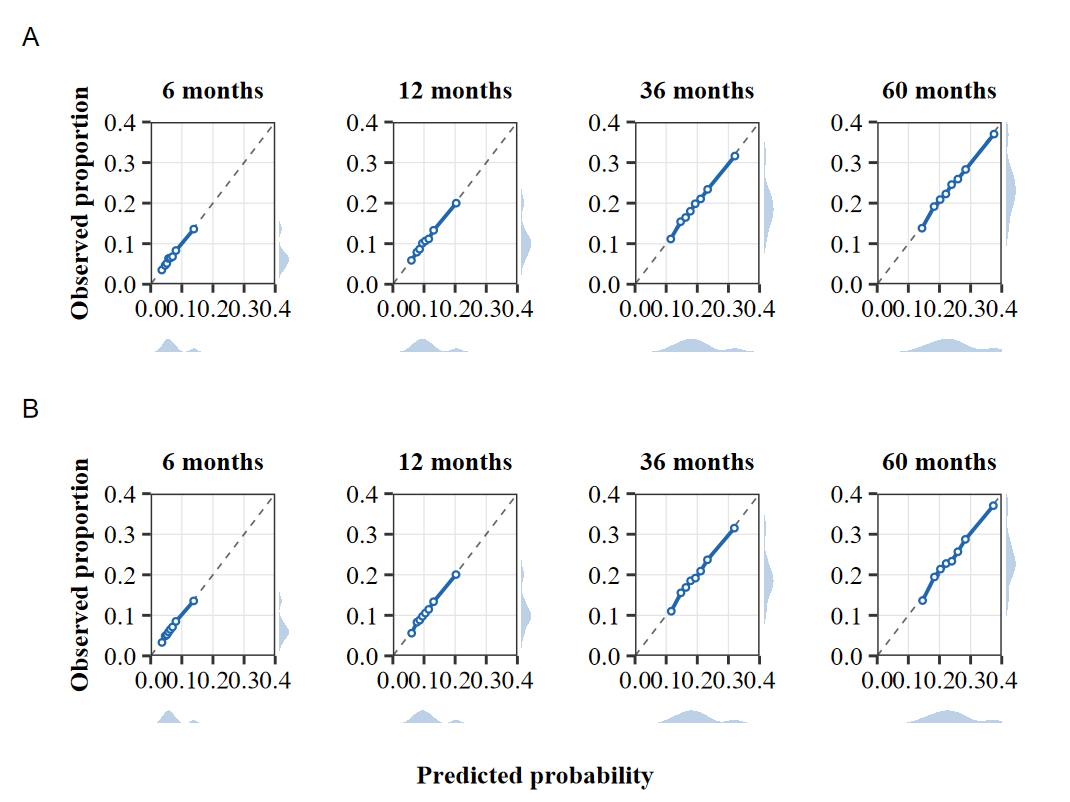

In [22]:
#| label: calibration-plots-readmission

library(ggplot2); library(patchwork)
tnr <- "Times New Roman"

create_cal_published <- function(data, time_title,
                                 color = "#2166AC",
                                 x_lim = c(0, 0.4), x_by = 0.1,
                                 y_lim = x_lim,     y_by = x_by,
                                 show_x_label = FALSE, show_y_label = FALSE) {
  fixed_margin <- ggplot2::margin(5, 2, 5, 5)

  .label_fmt <- function(lim)
    scales::number_format(accuracy = ifelse(diff(lim) <= 0.02, 0.001,
                                     ifelse(diff(lim) <= 0.2,  0.01, 0.1)))

  main <- ggplot2::ggplot(data, ggplot2::aes(x = mean_predicted, y = observed)) +
    ggplot2::geom_abline(intercept = 0, slope = 1, linetype = "dashed",
                         color = "black", linewidth = 0.4, alpha = 0.6) +
    ggplot2::geom_ribbon(ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
                         alpha = 0.3, fill = color) +
    ggplot2::geom_line(color = color, linewidth = 0.9) +
    ggplot2::geom_errorbar(ggplot2::aes(ymin = observed_lower, ymax = observed_upper),
                           width = 0.02 * diff(x_lim), color = color,
                           alpha = 0.6, linewidth = 0.5) +
    ggplot2::geom_point(size = 1, color = color, fill = "white",
                        shape = 21, stroke = 0.8) +
    ggplot2::scale_x_continuous(limits = x_lim, expand = c(0, 0),
                                 breaks = seq(x_lim[1], x_lim[2], by = x_by),
                                 labels = .label_fmt(x_lim)) +
    ggplot2::scale_y_continuous(limits = y_lim, expand = c(0, 0),
                                 breaks = seq(y_lim[1], y_lim[2], by = y_by),
                                 labels = .label_fmt(y_lim)) +
    ggplot2::labs(x = "Predicted probability", y = "Observed proportion",
                  subtitle = time_title) +
    ggplot2::theme_bw(base_size = 15, base_family = tnr) +
    ggplot2::theme(
      plot.subtitle    = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5),
      panel.grid.major = ggplot2::element_line(color = "grey90", linewidth = 0.3),
      panel.grid.minor = ggplot2::element_blank(),
      axis.ticks.length = ggplot2::unit(1.5, "mm"),
      axis.text        = ggplot2::element_text(size = 13, color = "black"),
      axis.title       = ggplot2::element_text(size = 13, face = "bold"),
      axis.title.x     = ggplot2::element_text(
        color = if (show_x_label) "black" else NA, size = 13, face = "bold"),
      axis.title.y     = ggplot2::element_text(
        color = if (show_y_label) "black" else NA, size = 13, face = "bold"),
      plot.margin      = fixed_margin
    )

  right_dens <- ggplot2::ggplot(data, ggplot2::aes(x = observed)) +
    ggplot2::geom_density(fill = color, alpha = 0.3, color = NA) +
    ggplot2::scale_x_continuous(limits = y_lim, expand = c(0, 0)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) +
    ggplot2::coord_flip() +
    ggplot2::theme_void() +
    ggplot2::theme(plot.margin = ggplot2::margin(5, 5, 5, 0))

  bottom_dens <- ggplot2::ggplot(data, ggplot2::aes(x = mean_predicted)) +
    ggplot2::geom_density(fill = color, alpha = 0.3, color = NA) +
    ggplot2::scale_x_continuous(limits = x_lim, expand = c(0, 0)) +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.25))) +
    ggplot2::theme_void() +
    ggplot2::theme(plot.margin = ggplot2::margin(0, 2, 0, 5))

  design <- c(
    patchwork::area(t = 1, l = 1, b = 10, r = 10),
    patchwork::area(t = 1, l = 11, b = 10, r = 11),
    patchwork::area(t = 11, l = 1, b = 11, r = 10)
  )
  main + right_dens + bottom_dens + patchwork::plot_layout(design = design)
}

.make_cal_panel <- function(cal_obj, color, x_lim, x_by,
                            y_lim = x_lim, y_by = x_by) {
  curves <- cal_obj$calibration_curves
  if ("observed_min" %in% names(curves) && !"observed_lower" %in% names(curves)) {
    curves$observed_lower <- curves$observed_min
    curves$observed_upper <- curves$observed_max
  }
  curves <- dplyr::mutate(curves, time_label = paste0(time_months, " months"))
  time_levels <- paste0(sort(unique(curves$time_months)), " months")
  n_plots <- length(time_levels); n_cols <- 4L; n_rows <- ceiling(n_plots / n_cols)

  plots <- lapply(seq_along(time_levels), function(i) {
    col_idx <- (i - 1L) %% n_cols
    row_idx <- (i - 1L) %/% n_cols
    show_y  <- col_idx == 0L
    is_last <- row_idx == (n_rows - 1L)
    n_last  <- n_plots - (n_rows - 1L) * n_cols
    show_x  <- is_last && col_idx == floor((n_last - 1L) / 2L)
    create_cal_published(
      dplyr::filter(curves, time_label == time_levels[i]),
      time_levels[i], color = color,
      x_lim = x_lim, x_by = x_by,
      y_lim = y_lim, y_by = y_by,
      show_x_label = show_x, show_y_label = show_y
    )
  })
  patchwork::wrap_plots(plots, ncol = n_cols) +
    patchwork::plot_annotation(theme = ggplot2::theme(plot.margin = ggplot2::margin(10, 10, 10, 10)))
}

# Ã¢â€â‚¬Ã¢â€â‚¬ Readmission panels (blue) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
combined_readmit_full <- .make_cal_panel(cal_results$full_ph,
  color = "#2166AC", x_lim = c(0, 0.4), x_by = 0.1)
combined_readmit_shap <- .make_cal_panel(cal_results$shap_clean,
  color = "#2166AC", x_lim = c(0, 0.4), x_by = 0.1)

final_readmit <- patchwork::wrap_plots(
  patchwork::wrap_elements(combined_readmit_full & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  patchwork::wrap_elements(combined_readmit_shap & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  ncol = 1
) +
  patchwork::plot_annotation(
    tag_levels = "A",
    caption = "Predicted probability",
    theme = ggplot2::theme(
      plot.caption = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5, vjust = 1, family = tnr),
      plot.tag     = ggplot2::element_text(face = "bold", size = 18, family = tnr),
      plot.tag.position = c(0.00, 0.97)
    )
  )
print(final_readmit)

ggplot2::ggsave(file.path(project_root, "cons/_figs/readmission_calibration_combined_AB.tiff"),
  final_readmit, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm",
  dpi = 600, compression = "lzw")
ggplot2::ggsave(file.path(project_root, "cons/_figs/readmission_calibration_combined_AB.png"),
  final_readmit, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm", dpi = 600)


There were 16 warnings (use warnings() to see them)


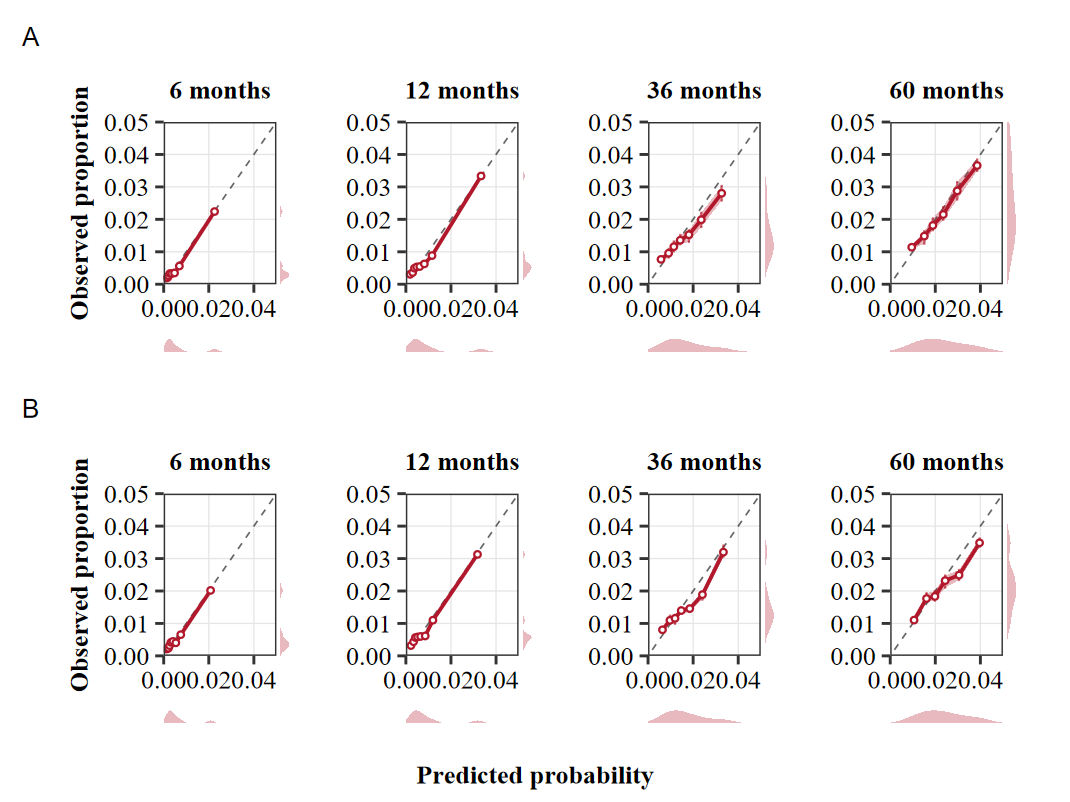

There were 16 warnings (use warnings() to see them)
There were 16 warnings (use warnings() to see them)


In [23]:
#| label: calibration-plots-death

# Ã¢â€â‚¬Ã¢â€â‚¬ Mortality panels (red) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
combined_death_full <- .make_cal_panel(death_cal_full$full_ph,
  color = "#B2182B", y_lim = c(0, 0.05), y_by = 0.01, x_lim = c(0, 0.05), x_by = 0.02)
combined_death_shap <- .make_cal_panel(death_cal_full$shap_clean,
  color = "#B2182B", y_lim = c(0, 0.05), y_by = 0.01, x_lim = c(0, 0.05), x_by = 0.02)

final_death <- patchwork::wrap_plots(
  patchwork::wrap_elements(combined_death_full & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  patchwork::wrap_elements(combined_death_shap & ggplot2::theme(axis.title.x = ggplot2::element_blank())),
  ncol = 1
) +
  patchwork::plot_annotation(
    tag_levels = "A",
    caption = "Predicted probability",
    theme = ggplot2::theme(
      plot.caption      = ggplot2::element_text(size = 13, face = "bold", hjust = 0.5, vjust = 1, family = tnr),
      plot.tag          = ggplot2::element_text(face = "bold", size = 18, family = tnr),
      plot.tag.position = c(0.00, 0.97)
    )
  )
print(final_death)

ggplot2::ggsave(file.path(project_root, "cons/_figs/mortality_calibration_combined_AB.tiff"),
  final_death, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm",
  dpi = 600, compression = "lzw")
ggplot2::ggsave(file.path(project_root, "cons/_figs/mortality_calibration_combined_AB.png"),
  final_death, width = 17.8 * 1.6, height = 12 * 1.6, units = "cm", dpi = 600)


## 3. Dual metrics for pending models

Models that do not yet have dual metrics in `amalisis.xlsx`:
- `formula_readmit` + `formula_death` (Full PH base)
- `formula_readmit_updated` + `formula_death_updated` (Full PH updated)
- `formula_shap_death_interact` (paired with SHAP readmit clean)
- `formula_shap_death` as implementation model (paired with SHAP readmit clean)

We use `k_folds = 5` with `eval_times = c(3, 6, 12, 36, 60)`.

In [24]:
#| label: dual-pending
#| message: false

gc()
# --- Dual metrics for pending models ---
EVAL_TIMES <- c(3, 6, 12, 36, 60)
K_FOLDS <- 5

pending_configs <- list(
  full_ph_base = list(
    label = "Full PH base",
    readmit = if (exists("formula_readmit")) formula_readmit else NULL,
    death = if (exists("formula_death")) formula_death else NULL
  ),
  full_ph_upd = list(
    label = "Full PH updated",
    readmit = if (exists("formula_readmit_updated")) formula_readmit_updated else NULL,
    death = if (exists("formula_death_updated")) formula_death_updated else NULL
  ),
  shap_readmit_clean_death = list(
    label = "SHAP clean readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_death_updated2")) formula_death_updated2 else NULL
  ),
  shap_readmit_clean_death_interact = list(
    label = "SHAP clean readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_shap_death_interact")) formula_shap_death_interact else NULL
  ),
  shap_readmit_interact_death_interact = list(
    label = "SHAP interact readmit + SHAP death interact",
    readmit = if (exists("formula_shap_readmit_interact")) formula_shap_readmit_interact else NULL,
    death = if (exists("formula_shap_death_interact")) formula_shap_death_interact else NULL
  ),
  shap_death_implem = list(
    label = "SHAP clean readmit + SHAP death (13 vars)",
    readmit = if (exists("formula_shap_readmit_clean_updated")) formula_shap_readmit_clean_updated else NULL,
    death = if (exists("formula_shap_death_rule2")) formula_shap_death_rule2 else NULL
  )
)

# Filter configurations with available formulas
pending_configs <- pending_configs[
  sapply(pending_configs, function(x) !is.null(x$readmit) && !is.null(x$death))
]

cat("Pending configurations to evaluate:\n")
for (nm in names(pending_configs)) {
  cat(sprintf("  - %s: %s\n", nm, pending_configs[[nm]]$label))
}

Pending configurations to evaluate:
  - full_ph_base: Full PH base
  - full_ph_upd: Full PH updated
  - shap_readmit_clean_death: SHAP clean readmit + SHAP death interact
  - shap_readmit_clean_death_interact: SHAP clean readmit + SHAP death interact
  - shap_readmit_interact_death_interact: SHAP interact readmit + SHAP death interact
  - shap_death_implem: SHAP clean readmit + SHAP death (13 vars)


In [25]:
#| label: run-dual-pending
#| message: false
#| cache: false

dual_pending_results <- list()

for (nm in names(pending_configs)) {
  cfg <- pending_configs[[nm]]
  cat(sprintf("\n=== Dual: %s ===\n", cfg$label))
  flush.console()
  
  dual_pending_results[[nm]] <- evaluate_dual_cox_python_style(
    formula_readmit = cfg$readmit,
    formula_death = cfg$death,
    imputed_list = py_corrected_datasets_boot,
    k_folds = K_FOLDS,
    eval_times = EVAL_TIMES
  )
  
  cat(sprintf("  OK - %s\n", cfg$label))
  print(dual_pending_results[[nm]]$summary[dual_pending_results[[nm]]$summary$Time %in% c("6","12","36","60","Global"), ])
  flush.console()
}


=== Dual: Full PH base ===
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  OK - Full PH base
          Risk        Metric   Time        mean           sd        q025
2        Death           IBS      6 0.005710190 0.0004782881 0.004776042
3        Death           IBS     12 0.007575272 0.0005302527 0.006567874
4        Death           IBS     36 0.015406741 0.0004699625 0.014492875
5        Death           IBS     60 0.022865883 0.0003976175 0.022044022
6        Death           IBS Global 0.022865883 0.0003976175 0.022044022
8        Death Uno's C-Index      6 0.764706532 0.0370509635 0.693049532
9        Death Uno's C-Index     12 0.758357580 0.0258356990 0.708148094
10       Death Uno's C-Index     36 0.763311578 0.0122605470 0.743249099
11       Death Uno's C-Index     60 0.762550652 0.0109169863 0.747193225
12       Death Uno's C-Index Global 0.742084571 0.0107357234 0.722822202
14 R

~ 18 minutes


## 5. Consolidated model table

Builds a table with all candidate models and their main dual metrics.

In [26]:
#| label: extract-metrics
#| message: false

# --- Helper to extract metrics from an evaluate_dual_cox_python_style object ---
extract_dual_metrics <- function(obj, model_id, family) {
  if (is.null(obj) || !is.list(obj) || is.null(obj$summary)) {
    return(NULL)
  }
  
  s <- obj$summary
  
  # Global
  row_global <- s[s$Time == "Global", ]
  
  # Dual UnoC = (UnoC_readmit + UnoC_death) / 2
  unoc_r <- row_global$mean[row_global$Metric == "Uno's C-Index" & row_global$Risk == "Readmission"]
  unoc_d <- row_global$mean[row_global$Metric == "Uno's C-Index" & row_global$Risk == "Death"]
  dual_unoC <- if (length(unoc_r) == 1 && length(unoc_d) == 1) (unoc_r + unoc_d) / 2 else NA
  
  # Dual IBS = (IBS_readmit + IBS_death) / 2
  ibs_r <- row_global$mean[row_global$Metric == "IBS" & row_global$Risk == "Readmission"]
  ibs_d <- row_global$mean[row_global$Metric == "IBS" & row_global$Risk == "Death"]
  dual_ibs <- if (length(ibs_r) == 1 && length(ibs_d) == 1) (ibs_r + ibs_d) / 2 else NA
  
  # By horizon (d_C_T, d_IBS_T)
  d_C_T <- list()
  d_IBS_T <- list()
  for (t in c("6", "12", "36", "60")) {
    s_t <- s[s$Time == t, ]
    if (nrow(s_t) > 0) {
      c_r <- s_t$mean[s_t$Metric == "Uno's C-Index" & s_t$Risk == "Readmission"]
      c_d <- s_t$mean[s_t$Metric == "Uno's C-Index" & s_t$Risk == "Death"]
      d_C_T[[t]] <- if (length(c_r) == 1 && length(c_d) == 1) (c_r + c_d) / 2 else NA
      
      ibs_r <- s_t$mean[s_t$Metric == "IBS" & s_t$Risk == "Readmission"]
      ibs_d <- s_t$mean[s_t$Metric == "IBS" & s_t$Risk == "Death"]
      d_IBS_T[[t]] <- if (length(ibs_r) == 1 && length(ibs_d) == 1) (ibs_r + ibs_d) / 2 else NA
    }
  }
  
  # Pooled individual
  unoc_readmit <- if (length(unoc_r) == 1) unoc_r else NA
  unoc_death <- if (length(unoc_d) == 1) unoc_d else NA
  ibs_readmit <- if (length(ibs_r) == 1) ibs_r else NA
  ibs_death <- if (length(ibs_d) == 1) ibs_d else NA
  
  data.frame(
    model_id = model_id,
    family = family,
    dual_UnoC = round(dual_unoC, 4),
    dual_IBS = round(dual_ibs, 4),
    d_C_6 = round(d_C_T[["6"]], 4),
    d_C_12 = round(d_C_T[["12"]], 4),
    d_C_36 = round(d_C_T[["36"]], 4),
    d_C_60 = round(d_C_T[["60"]], 4),
    d_IBS_6 = round(d_IBS_T[["6"]], 4),
    d_IBS_12 = round(d_IBS_T[["12"]], 4),
    d_IBS_36 = round(d_IBS_T[["36"]], 4),
    d_IBS_60 = round(d_IBS_T[["60"]], 4),
    UnoC_readmit = round(unoc_readmit, 4),
    UnoC_death = round(unoc_death, 4),
    IBS_readmit = round(ibs_readmit, 4),
    IBS_death = round(ibs_death, 4),
    stringsAsFactors = FALSE
  )
}

cat("Helper function extract_dual_metrics defined.\n")

Helper function extract_dual_metrics defined.


In [27]:
dual_pending_results$full_ph_upd$summary |>
  dplyr::filter(Time %in% c("6","12","36","60","Global")) |>
  dplyr::arrange(desc(Risk)) |> knitr::kable("markdown")



|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0534030| 0.0014176| 0.0514324| 0.0558811| 25|
|Readmission |IBS           |12     | 0.0728063| 0.0013786| 0.0703095| 0.0753326| 25|
|Readmission |IBS           |36     | 0.1133085| 0.0010568| 0.1111496| 0.1151360| 25|
|Readmission |IBS           |60     | 0.1376581| 0.0008099| 0.1360505| 0.1389645| 25|
|Readmission |IBS           |Global | 0.1376581| 0.0008099| 0.1360505| 0.1389645| 25|
|Readmission |Uno's C-Index |6      | 0.6425242| 0.0075735| 0.6319000| 0.6552510| 25|
|Readmission |Uno's C-Index |12     | 0.6308655| 0.0053001| 0.6209058| 0.6389010| 25|
|Readmission |Uno's C-Index |36     | 0.6146601| 0.0040062| 0.6080948| 0.6212485| 25|
|Readmission |Uno's C-Index |60     | 0.6094028| 0.0042338| 0.6032401| 0.6175626| 25|
|Readmission |Uno's C-Index |Global | 0.6039550| 0.0

In [28]:
#| label: build-table
#| message: false

# --- List of all available result objects ---
# Objects from prediction22 (should be in the environment)
result_objects <- list(
  # Full PH family
  full_ph_base = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$full_ph_base else NULL,
    id = "formula_readmit + formula_death",
    fam = "Full PH"
  ),
  full_ph_upd = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$full_ph_upd else NULL,
    id = "formula_readmit_updated + formula_death_updated",
    fam = "Full PH"
  ),
  full_ph_upd2 = list(
    obj = if (exists("results_upd2_py")) results_upd2_py else NULL,
    id = "formula_readmit_updated2 + formula_death_updated2",
    fam = "Full PH"
  ),
  
  # xgb2 family (SHAP)
  shap_clean = list(
    obj = if (exists("results_shap_xgb_py_upd_best_perf")) results_shap_xgb_py_upd_best_perf else NULL,
    id = "formula_shap_readmit_clean_updated + formula_death_updated2",
    fam = "xgb2"
  ),
  shap_death_implem = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_death_implem else NULL,
    id = "formula_shap_readmit_clean_updated + formula_shap_death_rule2",
    fam = "xgb2"
  ),
  shap_readmit_interact = list(
    obj = if (exists("results_shap_xgb_py_upd_best_perf3")) results_shap_xgb_py_upd_best_perf3 else NULL,
    id = "formula_shap_readmit_interact + formula_death_updated2",
    fam = "xgb2"
  ),
  shap_readmit_clean_death_interact = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_readmit_clean_death_interact else NULL,
    id = "formula_shap_readmit_clean_updated + formula_shap_death_interact",
    fam = "xgb2"
  ),
  shap_readmit_interact_death_interact = list(
    obj = if (exists("dual_pending_results")) dual_pending_results$shap_readmit_interact_death_interact else NULL,
    id = "formula_shap_readmit_interact + formula_shap_death_interact",
    fam = "xgb2"
  )#,
  
  # # DS family
  # ds_clean = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_clean_ds_death else NULL,
  #   id = "formula_shap_ds_readmit_clean_updated + formula_shap_ds_death_updated",
  #   fam = "ds"
  # ),
  # ds_interact = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_interact_ds_death else NULL,
  #   id = "formula_shap_ds_readmit_interact + formula_shap_ds_death_updated",
  #   fam = "ds"
  # ),
  # ds_readmit_clean_full_death = list(
  #   obj = if (exists("ds_dual_results")) ds_dual_results$ds_readmit_clean_full_death else NULL,
  #   id = "formula_shap_ds_readmit_clean_updated + formula_death_updated2",
  #   fam = "ds"
  # )
)

# --- Extract metrics ---
table_rows <- lapply(names(result_objects), function(nm) {
  entry <- result_objects[[nm]]
  if (is.null(entry$obj)) return(NULL)
  extract_dual_metrics(entry$obj, entry$id, entry$fam)
})
table_rows <- table_rows[!sapply(table_rows, is.null)]

if (length(table_rows) > 0) {
  consolidated_table <- do.call(rbind, table_rows)
  rownames(consolidated_table) <- NULL
  
  cat("=== CONSOLIDATED TABLE OF DUAL METRICS ===\n\n")
  knitr::kable(consolidated_table, row.names = FALSE, format = "markdown") |>  print()

  # Save
  write.csv(consolidated_table,
            file.path(project_root, "cons", "_out", "tabla_consolidada_dual.csv"),
            row.names = FALSE)
  cat("\nSaved to: cons/_out/tabla_consolidada_dual.csv\n")
} else {
  cat("No rows to consolidate. Run the previous sections first.\n")
}

=== CONSOLIDATED TABLE OF DUAL METRICS ===



|model_id                                                         |family  | dual_UnoC| dual_IBS|  d_C_6| d_C_12| d_C_36| d_C_60| d_IBS_6| d_IBS_12| d_IBS_36| d_IBS_60| UnoC_readmit| UnoC_death| IBS_readmit| IBS_death|
|:----------------------------------------------------------------|:-------|---------:|--------:|------:|------:|------:|------:|-------:|--------:|--------:|--------:|------------:|----------:|-----------:|---------:|
|formula_readmit + formula_death                                  |Full PH |    0.6730|   0.0803| 0.7036| 0.6946| 0.6889| 0.6860|  0.0296|   0.0402|   0.0644|   0.0803|       0.6039|     0.7421|      0.1377|    0.0229|
|formula_readmit_updated + formula_death_updated                  |Full PH |    0.6731|   0.0803| 0.7037| 0.6947| 0.6891| 0.6860|  0.0296|   0.0402|   0.0644|   0.0803|       0.6040|     0.7423|      0.1377|    0.0229|
|formula_readmit_updated2 + formula_death_updated2                |Full PH |  


## 6. ICI consolidated by horizon

Extract ICI at 6, 12, 36, 60 months and build a table + plot.

=== ICI / ECE / E-O for READMISSION models ===

                model     outcome time    ICI ICI_sd    ECE    E_O
 SHAP clean (primary) Readmission    6 0.0068  1e-04 0.0024 0.9911
 SHAP clean (primary) Readmission   12 0.0078  1e-04 0.0029 0.9913
 SHAP clean (primary) Readmission   36 0.0092  1e-04 0.0050 0.9893
 SHAP clean (primary) Readmission   60 0.0095  1e-04 0.0065 0.9859
              Full PH Readmission    6 0.0065  1e-04 0.0022 0.9898
              Full PH Readmission   12 0.0080  1e-04 0.0027 0.9900
              Full PH Readmission   36 0.0096  3e-04 0.0039 0.9881
              Full PH Readmission   60 0.0103  3e-04 0.0051 0.9848
  SHAP + interactions Readmission    6 0.0069  1e-04 0.0024 0.9911
  SHAP + interactions Readmission   12 0.0079  2e-04 0.0028 0.9913
  SHAP + interactions Readmission   36 0.0094  2e-04 0.0050 0.9893
  SHAP + interactions Readmission   60 0.0097  1e-04 0.0068 0.9858
                 Base Readmission    6 0.0060  1e-04 0.0022 0.9912
              

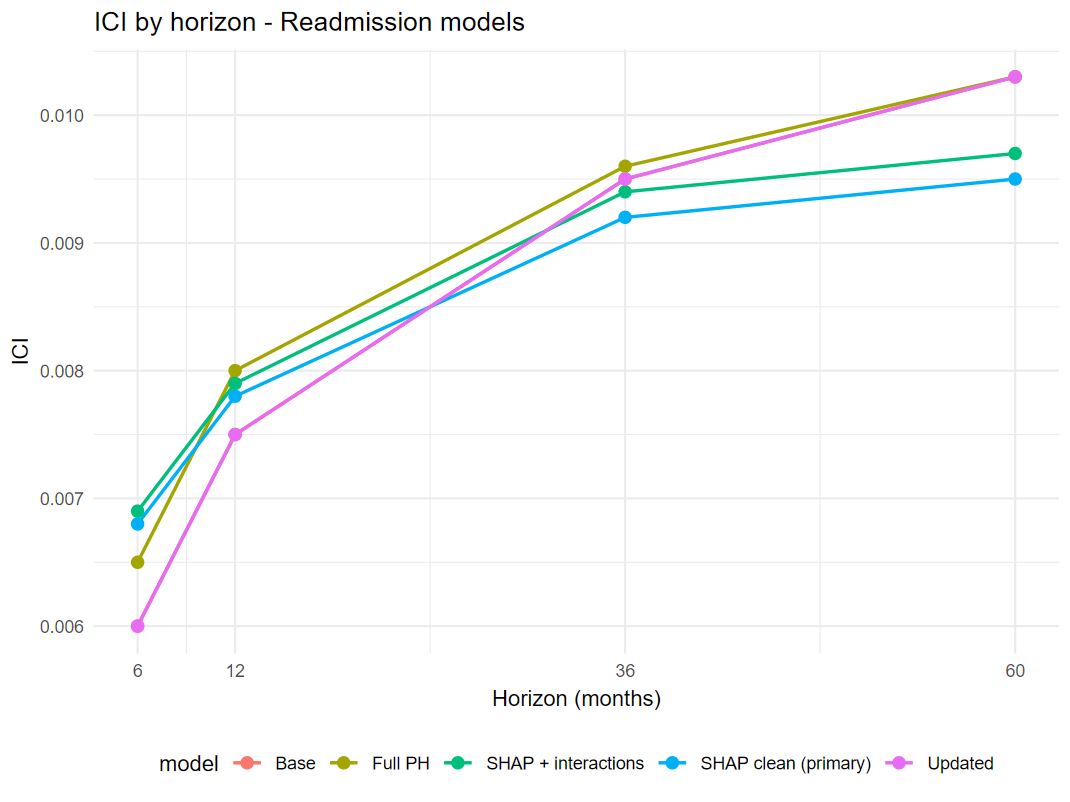

In [29]:
#| label: ici-table
#| message: false

# --- ICI for readmission ---
ici_readmit_rows <- list()

if (exists("cal_results")) {
  for (nm in names(cal_results)) {
    label <- readmit_models_for_cal[[nm]]$label
    ps <- cal_results[[nm]]$pooled_summary
    for (i in seq_len(nrow(ps))) {
      if (ps$time_months[i] %in% c(6, 12, 36, 60)) {
        ici_readmit_rows[[length(ici_readmit_rows) + 1]] <- data.frame(
          model = label,
          outcome = "Readmission",
          time = ps$time_months[i],
          ICI = round(ps$ici_mean[i], 4),
          ICI_sd = round(ps$ici_sd[i], 4),
          ECE = round(ps$ece_mean[i], 4),
          E_O = round(ps$eo_mean[i], 4),
          stringsAsFactors = FALSE
        )
      }
    }
  }
}

if (length(ici_readmit_rows) > 0) {
  ici_readmit_table <- do.call(rbind, ici_readmit_rows)
  cat("=== ICI / ECE / E-O for READMISSION models ===\n\n")
  print(ici_readmit_table, row.names = FALSE)
  
  write.csv(ici_readmit_table,
            file.path(project_root, "cons", "_out", "ici_readmit_multihorizonte.csv"),
            row.names = FALSE)
  
  # Plot
  if (requireNamespace("ggplot2", quietly = TRUE)) {
    p <- ggplot2::ggplot(ici_readmit_table,
                         ggplot2::aes(x = time, y = ICI, color = model, group = model)) +
      ggplot2::geom_line(linewidth = 0.8) +
      ggplot2::geom_point(size = 2.5) +
      ggplot2::scale_x_continuous(breaks = c(6, 12, 36, 60)) +
      ggplot2::labs(title = "ICI by horizon - Readmission models",
                    x = "Horizon (months)", y = "ICI") +
      ggplot2::theme_minimal() +
      ggplot2::theme(legend.position = "bottom")
    print(p)
  }
} else {
  cat("No ICI data available. Run section 2 first.\n")
}

=== ICI / ECE / E-O for MORTALITY models ===

               model   outcome time    ICI    ECE    E_O
   Full PH (primary) Mortality    6 0.0024 0.0007 1.0069
   Full PH (primary) Mortality   12 0.0031 0.0010 1.0096
   Full PH (primary) Mortality   36 0.0067 0.0023 1.0142
   Full PH (primary) Mortality   60 0.0091 0.0025 1.0246
         SHAP rule 2 Mortality    6 0.0017 0.0007 1.0073
         SHAP rule 2 Mortality   12 0.0027 0.0010 1.0092
         SHAP rule 2 Mortality   36 0.0067 0.0024 1.0151
         SHAP rule 2 Mortality   60 0.0094 0.0026 1.0277
 SHAP + interactions Mortality    6 0.0018 0.0009 1.0069
 SHAP + interactions Mortality   12 0.0027 0.0013 1.0086
 SHAP + interactions Mortality   36 0.0068 0.0028 1.0147
 SHAP + interactions Mortality   60 0.0091 0.0029 1.0284
          Base death Mortality    6 0.0017 0.0006 1.0078
          Base death Mortality   12 0.0027 0.0011 1.0098
          Base death Mortality   36 0.0067 0.0025 1.0117
          Base death Mortality   60 0.0089

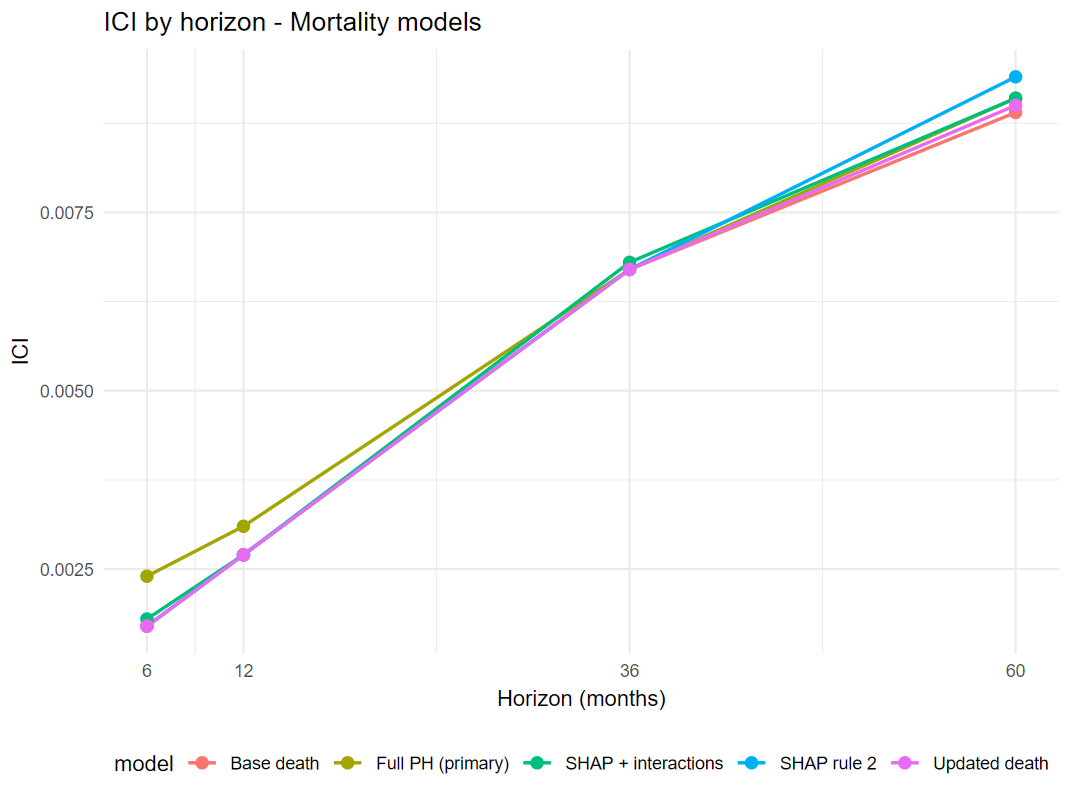

In [30]:
#| label: ici-death-table
#| message: false

if (exists("death_cal_results") && length(death_cal_results) > 0) {
  ici_death_rows <- list()
  for (nm in names(death_cal_results)) {
    label <- death_models_for_cal[[nm]]$label
    df <- death_cal_results[[nm]]
    for (i in seq_len(nrow(df))) {
      ici_death_rows[[length(ici_death_rows) + 1]] <- data.frame(
        model = label,
        outcome = "Mortality",
        time = df$time_months[i],
        ICI = round(df$ici[i], 4),
        ECE = round(df$ece[i], 4),
        E_O = round(df$eo_ratio[i], 4),
        stringsAsFactors = FALSE
      )
    }
  }
  
  ici_death_table <- do.call(rbind, ici_death_rows)
  cat("=== ICI / ECE / E-O for MORTALITY models ===\n\n")
  print(ici_death_table, row.names = FALSE)
  
  write.csv(ici_death_table,
            file.path(project_root, "cons", "_out", "ici_death_multihorizonte.csv"),
            row.names = FALSE)
  
  if (requireNamespace("ggplot2", quietly = TRUE)) {
    p <- ggplot2::ggplot(ici_death_table,
                         ggplot2::aes(x = time, y = ICI, color = model, group = model)) +
      ggplot2::geom_line(linewidth = 0.8) +
      ggplot2::geom_point(size = 2.5) +
      ggplot2::scale_x_continuous(breaks = c(6, 12, 36, 60)) +
      ggplot2::labs(title = "ICI by horizon - Mortality models",
                    x = "Horizon (months)", y = "ICI") +
      ggplot2::theme_minimal() +
      ggplot2::theme(legend.position = "bottom")
    print(p)
  }
} else {
  cat("No ICI data for death available. Run section 2b first.\n")
}


## 7. DCA (Decision Curve Analysis)

Evaluates the net benefit of using the model for clinical decisions
at different probability thresholds.

But we uniform the grid of integration from 6 to 60 months (2026-05-30).

In [31]:
#| label: dca-setup
#| message: false

source("cons/_alt_scripts/adca_from_results_boot.R")            # fuerza motor AJ
source("cons/_alt_scripts/dca_from_results_boot_for_metrics.R")
cat("Sourced: dca_from_results_boot_for_metrics\n")


Sourced: dca_from_results_boot_for_metrics


In [32]:
#| label: full-criteria-upd2-run-ev-mi-cv-python-style-from-step22
if (!exists("results_upd2_py")){
  results_upd2_py <- evaluate_dual_cox_python_style(
    formula_readmit = formula_readmit_updated2,
    formula_death = formula_death_updated2,
    imputed_list = py_corrected_datasets,
    k_folds = 5,
    eval_times = c(3, 6, 12, 36, 60)
  )
}

# Load the precomputed post-interaction death-side models instead of recomputing
# (each ~64 MB, saved strip=FALSE). Picks the newest matching RDS by mtime.
out_dir <- file.path(project_root, "data", "20241015_out")

.load_latest_rds <- function(suffix) {
  f <- list.files(out_dir, pattern = paste0("pred22_ndp_.*__", suffix, "\\.rds$"),
                  full.names = TRUE)
  if (!length(f)) stop(sprintf("No RDS found for '%s' in %s", suffix, out_dir))
  f <- f[order(file.info(f)$mtime, decreasing = TRUE)][1]   # newest
  message("Loading: ", basename(f))
  readRDS(f)
}

# results_shap_xgb_py_upd_post_int_alt1 <- evaluate_dual_cox_python_style(
#   formula_readmit = formula_shap_readmit_clean_updated,
#   formula_death = formula_death_updated2,
#   imputed_list = py_corrected_datasets_boot,
#   k_folds = 5,
#   eval_times = c(3,6,12,36,60)   # igual que todos los experimentos
# )

# results_shap_xgb_py_upd_post_int_alt2 <- evaluate_dual_cox_python_style(
#   formula_readmit = formula_shap_readmit_clean_updated,
#   formula_death = formula_shap_death_rule2,
#   imputed_list = py_corrected_datasets_boot,
#   k_folds = 5,
#   eval_times = c(3,6,12,36,60)   # igual que todos los experimentos
# )
if (!exists("results_shap_xgb_py_upd_best_perf")){
  results_shap_xgb_py_upd_best_perf <- .load_latest_rds("dual_shap_int_d_fullph")  # SHAP death rule2results_shap_xgb_py_upd_post_int_alt1 <- .load_latest_rds("dual_shap_int_d_fullph")    # Full PH death
}
if (!exists("results_shap_xgb_py_upd_best_perf2")){
  results_shap_xgb_py_upd_best_perf2 <- .load_latest_rds("dual_shap_int_d_shap_rule")  # SHAP death rule2
}
  

Loading: pred22_ndp_2026_07_24__dual_shap_int_d_fullph.rds
Loading: pred22_ndp_2026_07_24__dual_shap_int_d_shap_rule.rds


In [33]:
#| label: dca-run
#| message: false
#| cache: false

DCA_HORIZONS <- c(6, 12, 36, 60)

dca_model_list <- list(
  full_ph     = results_upd2_py,
  shap_clean  = results_shap_xgb_py_upd_best_perf,
  implemented = results_shap_xgb_py_upd_best_perf2
)

# Compute the full DCA ONCE per model (covers BOTH risks + full summary in a
# single pass). This is the ONLY expensive step; everything else is derived.
dca_models_full <- run_dca_full_summary(dca_model_list, horizons = DCA_HORIZONS)

# Derive the compact per-horizon format (what plot_dca_multi_horizon expects)
# from the already-computed summaries Ã¢â‚¬â€ NO recomputation. Identical to what
# compute_dca_from_boot() would return (same run_adca config, same thresholds).
.dca_compact_from_full <- function(models_full, risk, horizons,
                                   thresholds = seq(0.01, 0.60, by = 0.01)) {
  out <- stats::setNames(vector("list", length(horizons)), as.character(horizons))
  for (h in horizons) {
    per_model <- lapply(models_full, function(m) {
      if (is.null(m)) return(NULL)
      if (!(h %in% as.numeric(m$config$horizons))) return(NULL)
      .dca_extract_horizon(m, risk, h, thresholds)
    })
    out[[as.character(h)]] <- stats::setNames(per_model, names(models_full))
  }
  out
}

dca_readmit <- .dca_compact_from_full(dca_models_full, "readmission", DCA_HORIZONS)
dca_death   <- .dca_compact_from_full(dca_models_full, "death",       DCA_HORIZONS)
cat("DCA computed once per model; readmission + mortality derived (no recompute).\n")


  DCA full summary: full_ph | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
  DCA full summary: shap_clean | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
  DCA full summary: implemented | horizons=6, 12, 36, 60
Readmission observed risk: Aalen-Johansen on 25/25 replicate(s). Death: Kaplan-Meier.
DCA computed once per model; readmission + mortality derived (no recompute).


~28 minutes

In [34]:
#| label: dca-summary-and-panel
#| message: false

# dca_models_full already exists from the dca-run chunk Ã¢â‚¬â€ do NOT recompute.
stopifnot(exists("dca_models_full"))

# Net-benefit summaries per model
dca_nb_full_ph          <- summarize_dca_nb(dca_models_full$full_ph$summary)
dca_nb_shap_clean       <- summarize_dca_nb(dca_models_full$shap_clean$summary)
dca_nb_shap_implemented <- summarize_dca_nb(dca_models_full$implemented$summary)

cat("=== Full PH Ã¢â‚¬â€ useful threshold ranges ===\n")
print(dca_nb_full_ph$any_useful)
cat("\n=== SHAP clean Ã¢â‚¬â€ focus window summary ===\n")
print(dca_nb_shap_clean$focus_summary)
cat("\n=== Both SHAP Ã¢â‚¬â€ focus window summary ===\n")
print(dca_nb_shap_implemented$focus_summary)


=== Full PH Ã¢â‚¬â€ useful threshold ranges ===
# A tibble: 8 × 8
  risk     horizon any_useful_anywhere useful_threshold_min useful_threshold_max
  <chr>      <dbl> <lgl>                              <dbl>                <dbl>
1 death          6 TRUE                                0.01                 0.5 
2 death         12 TRUE                                0.01                 0.5 
3 death         36 TRUE                                0.01                 0.5 
4 death         60 TRUE                                0.02                 0.44
5 readmis…       6 TRUE                                0.02                 0.32
6 readmis…      12 TRUE                                0.03                 0.42
7 readmis…      36 TRUE                                0.06                 0.5 
8 readmis…      60 TRUE                                0.07                 0.5 
# ℹ 3 more variables: max_model_nb <dbl>, max_treat_all_nb <dbl>,
#   max_treat_none_nb <dbl>

=== SHAP clean Ã¢â‚¬â€ focu

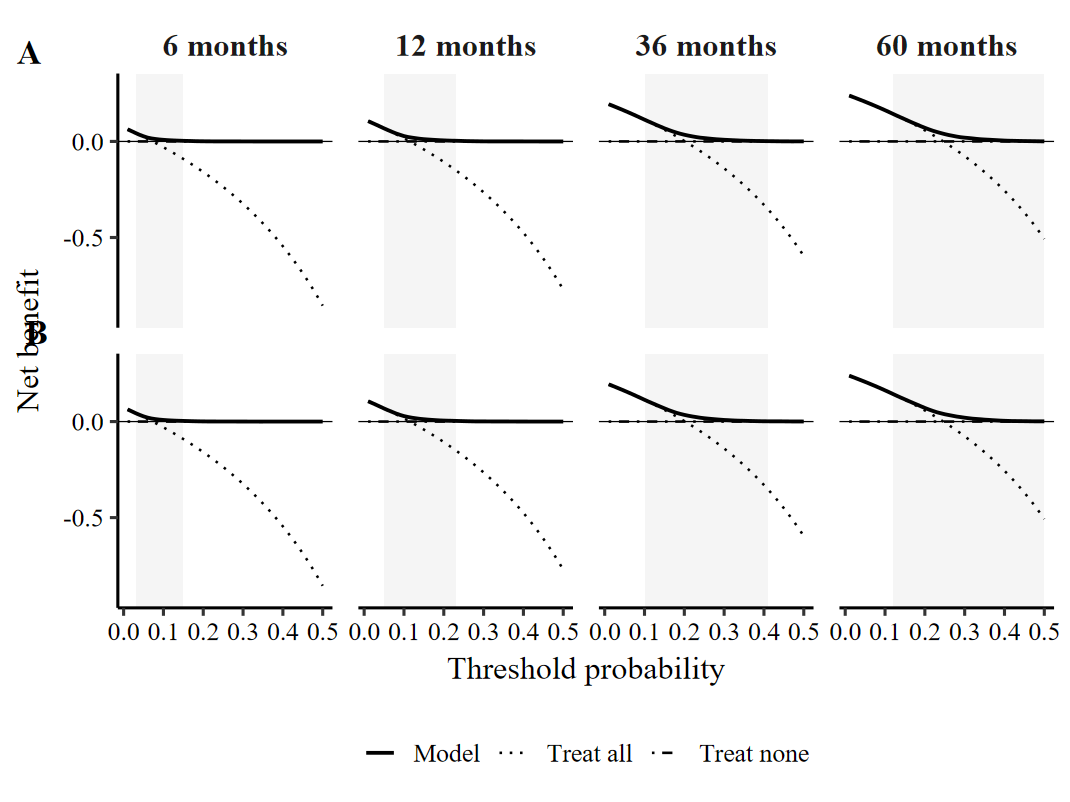

DCA results saved to cons/_out/dca_results.rds
(A = Full PH, B = SHAP clean / implemented)


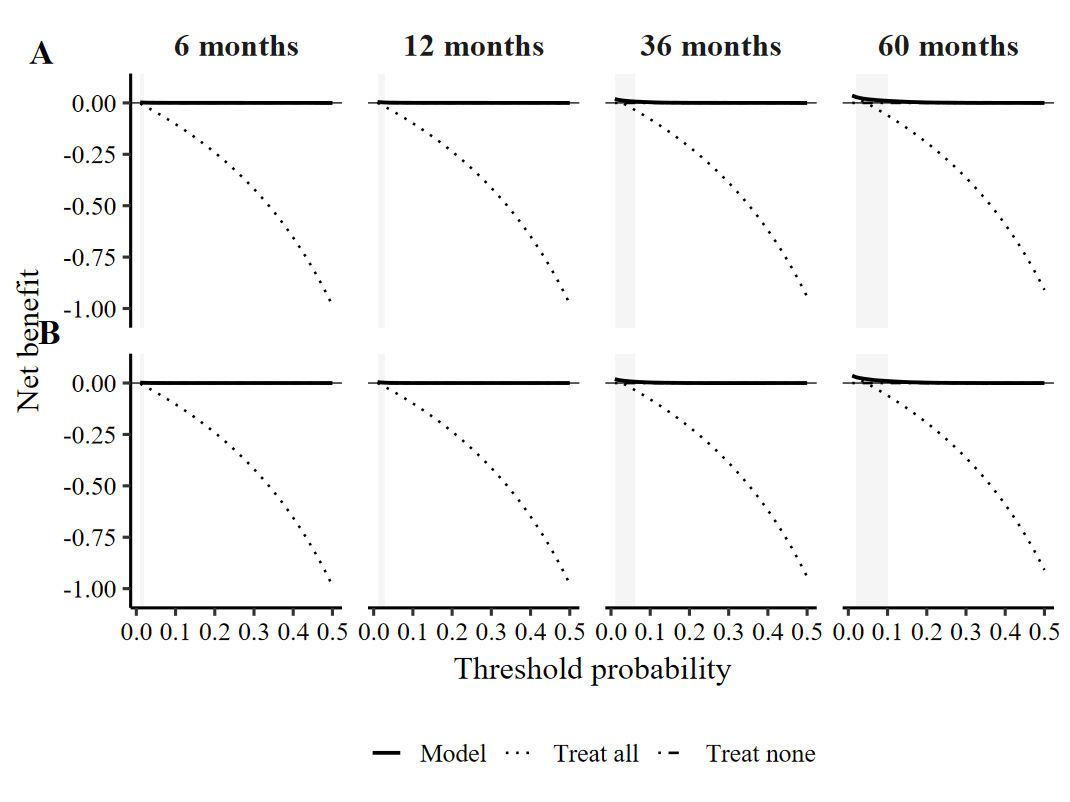

In [35]:
#| label: dca-panel-figures
#| message: false

p_readmit_panel <- make_dca_panel_figure(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$shap_clean$summary,
  outcome      = "readmission",
  horizons     = c(6, 12, 36, 60)
)
  # ggplot2::labs(
  #   caption = "A: Full PH readmission model; B: SHAP-clean readmission model"
  # )
print(p_readmit_panel)

p_death_panel <- make_dca_panel_figure(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$implemented$summary,
  outcome      = "death",
  horizons     = c(6, 12, 36, 60)
)
  # ggplot2::labs(
  #   caption = "A: Full PH mortality model; B: parsimonious SHAP mortality implementation model"
  # )
print(p_death_panel)

saveRDS(
  list(
    readmit = dca_readmit,
    death   = dca_death,
    models_full = dca_models_full,
    nb_full_ph = dca_nb_full_ph,
    nb_shap_clean = dca_nb_shap_clean,
    nb_implemented = dca_nb_shap_implemented
  ),
  file.path(project_root, "data", "20241015_out", "dca_results.rds")
)
cat("DCA results saved to cons/_out/dca_results.rds\n")
cat("(A = Full PH, B = SHAP clean / implemented)\n")

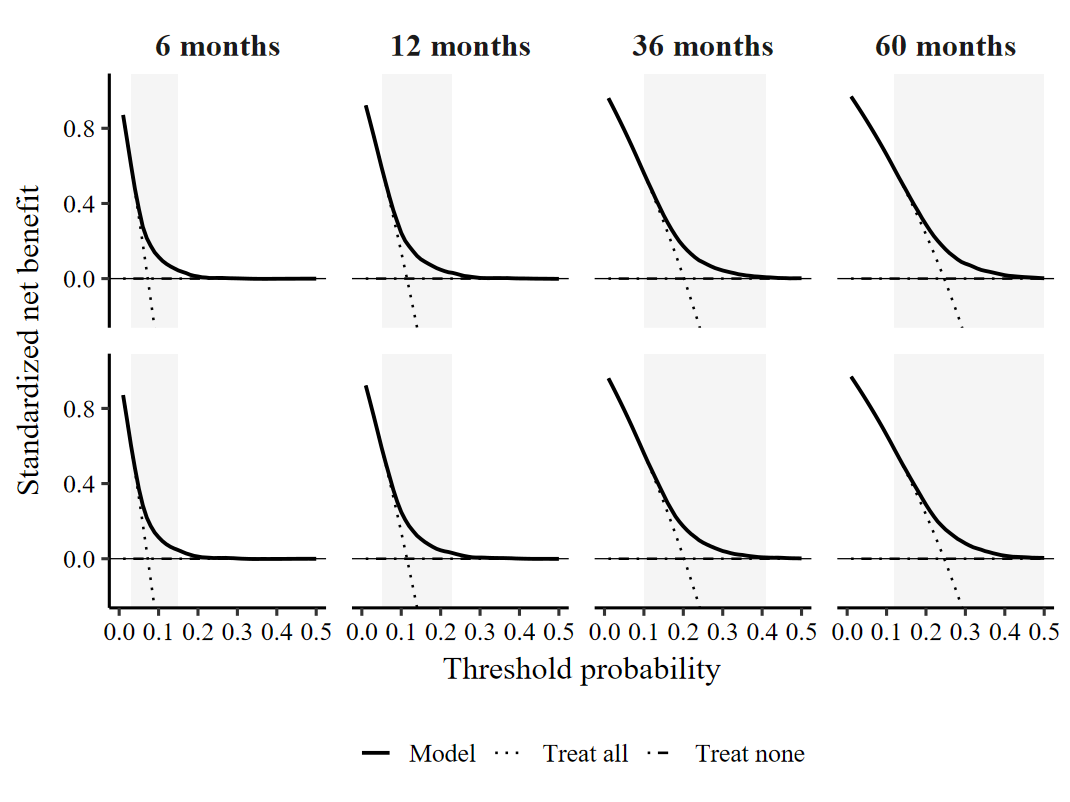

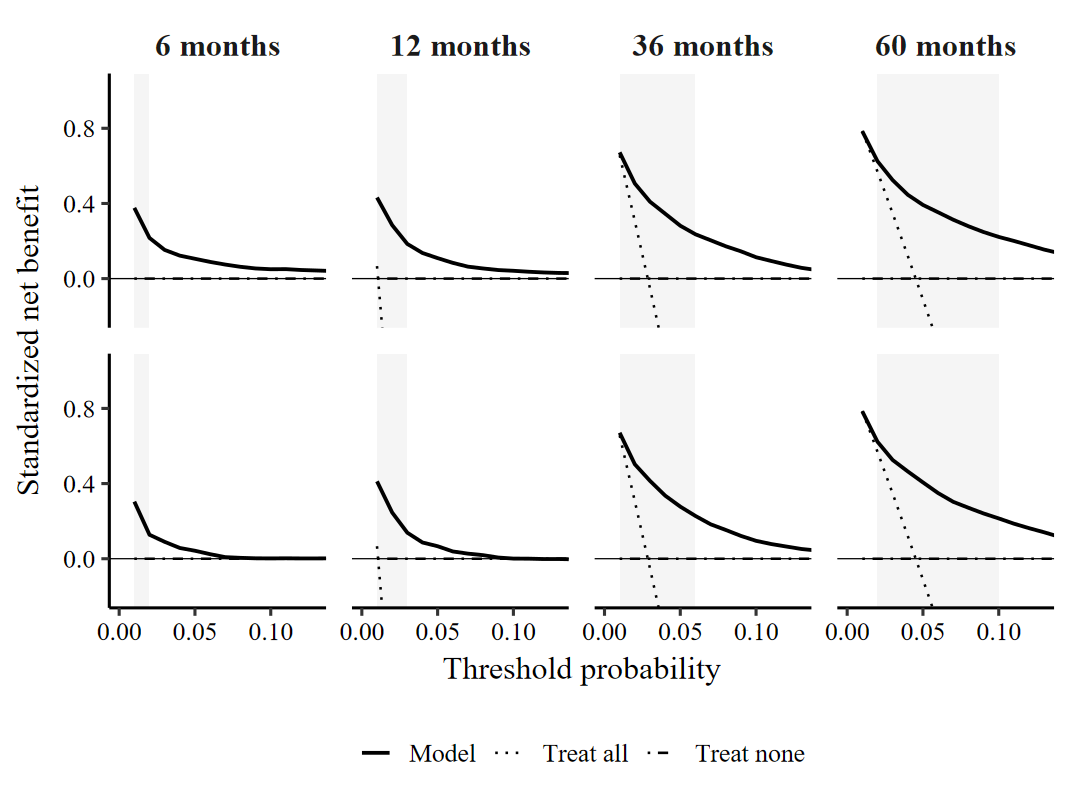

Standardized net benefit = net benefit / observed event rate at each horizon
(1.0 = treating everyone at threshold 0). The 'treat all' curve may fall below the
displayed range. Shaded band: plausible threshold window (0.5x to 2x the event rate).


In [36]:
#| label: dca-panel-figures-std
#| message: false

# Standardized-net-benefit variant of make_dca_panel_figure().
# Standalone: does NOT modify the shared make_dca_panel_figure() in
# dca_from_results_boot_for_metrics.R, so other callers stay intact.
# What changed vs the original:
#   - y axis = standardized net benefit = net_benefit_mean / observed event rate,
#     so the model curve is visible and comparable across horizons.
#   - x axis truncated per outcome (data-driven from the focus windows); high
#     thresholds are clinically irrelevant for rare outcomes (death stays tight).
#   - y axis cropped to the meaningful range; "treat all" may run off the bottom.
#   - a caption note below the plot states the standardization.

make_dca_panel_figure_std <- function(
    summary_full,
    summary_ml,
    outcome  = c("death", "readmission"),
    horizons = c(6, 12, 36, 60),
    x_limits = NULL,             # NULL = data-driven from the focus windows
    y_limits = c(-0.2, 1.03)     # standardized scale: 1.0 = treat-all at threshold 0
) {
  stopifnot(requireNamespace("ggplot2", quietly = TRUE))
  outcome <- match.arg(outcome)

  full_dat <- summary_full; full_dat$model_panel <- "A"
  ml_dat   <- summary_ml;   ml_dat$model_panel   <- "B"
  plot_dat <- rbind.data.frame(full_dat, ml_dat)
  plot_dat <- plot_dat[plot_dat$risk %in% outcome &
                         plot_dat$horizon %in% horizons, , drop = FALSE]
  if (!nrow(plot_dat)) stop("No rows for the requested outcome/horizons.", call. = FALSE)

  # Standardized net benefit = net benefit / event prevalence at the horizon.
  prev <- plot_dat$observed_event_risk_mean
  plot_dat$std_nb <- ifelse(is.finite(prev) & prev > 0,
                            plot_dat$net_benefit_mean / prev, NA_real_)

  plot_dat$strategy_plot <- factor(plot_dat$strategy,
                                   levels = c("Model", "Treat all", "Treat none"))
  plot_dat$model_panel   <- factor(plot_dat$model_panel, levels = c("A", "B"))
  plot_dat$horizon       <- factor(plot_dat$horizon, levels = horizons)

  focus_dat <- plot_dat[!duplicated(plot_dat[, c("model_panel", "horizon",
                                                 "focus_lower", "focus_upper")]), ,
                        drop = FALSE]

  # Data-driven x truncation: cover the focus windows + margin, capped at 0.5
  # (death collapses to a tight low-threshold range; readmission keeps its width).
  if (is.null(x_limits)) {
    x_hi <- min(0.5, max(focus_dat$focus_upper, na.rm = TRUE) * 1.3)
    x_limits <- c(0, x_hi)
  }

  ggplot2::ggplot() +
    ggplot2::geom_rect(
      data = focus_dat,
      ggplot2::aes(xmin = focus_lower, xmax = focus_upper, ymin = -Inf, ymax = Inf),
      inherit.aes = FALSE, fill = "grey80", alpha = 0.18, color = NA
    ) +
    ggplot2::geom_hline(yintercept = 0, linewidth = 0.3) +
    ggplot2::geom_line(
      data = plot_dat,
      ggplot2::aes(x = threshold, y = std_nb,
                   linetype = strategy_plot, linewidth = strategy_plot)
    ) +
    ggplot2::facet_grid(
      model_panel ~ horizon, switch = "y",
      labeller = ggplot2::labeller(horizon = function(x) paste0(x, " months"))
    ) +
    ggplot2::scale_linetype_manual(
      values = c("Model" = "solid", "Treat all" = "dotted", "Treat none" = "dotdash")
    ) +
    ggplot2::scale_linewidth_manual(
      values = c("Model" = 0.9, "Treat all" = 0.6, "Treat none" = 0.6)
    ) +
    ggplot2::coord_cartesian(xlim = x_limits, ylim = y_limits, clip = "on") +
    ggplot2::labs(
      x = "Threshold probability",
      y = "Standardized net benefit",
      linetype = NULL, linewidth = NULL)+
    #   caption = paste(
    #     "Standardized net benefit = net benefit / observed event rate at each horizon",
    #     "(1.0 = treating everyone at threshold 0). The 'treat all' curve may fall below the",
    #     "displayed range. Shaded band: plausible threshold window (0.5x to 2x the event rate).",
    #     sep = "\n")
    # ) +
    ggplot2::theme_classic(base_size = 16, base_family = "Times New Roman") +
    ggplot2::theme(
      legend.position   = "bottom",
      legend.box        = "horizontal",
      strip.background  = ggplot2::element_blank(),
      strip.placement   = "outside",
      strip.text.y.left = ggplot2::element_blank(),
      strip.text.x      = ggplot2::element_text(face = "bold", size = 16, hjust = 0.5),
      axis.text         = ggplot2::element_text(color = "black"),
      axis.title        = ggplot2::element_text(face = "plain"),
      panel.spacing     = ggplot2::unit(0.9, "lines"),
      plot.caption      = ggplot2::element_text(hjust = 0, size = 10, face = "italic")
    )
}

# Rebuild both panels with the standardized variant (same inputs as before)
p_readmit_panel <- make_dca_panel_figure_std(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$shap_clean$summary,
  outcome      = "readmission",
  horizons     = c(6, 12, 36, 60)
)
print(p_readmit_panel)

p_death_panel <- make_dca_panel_figure_std(
  summary_full = dca_models_full$full_ph$summary,
  summary_ml   = dca_models_full$implemented$summary,
  outcome      = "death",
  horizons     = c(6, 12, 36, 60)
)
print(p_death_panel)

# Save. Same filenames -> replaces the current manuscript figures.
# Add a "_std" suffix in `nm` below if you want to keep both versions.
fig_dir <- file.path(project_root, "cons", "_figs")
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE)

for (nm in c("p_dca_readmit_fullph_vs_shap_clean",
             "p_dca_death_fullph_vs_shap_implemented")) {
  obj <- if (grepl("readmit", nm)) p_readmit_panel else p_death_panel
  ggplot2::ggsave(file.path(fig_dir, paste0(nm, ".png")), obj,
                  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600)
  ggplot2::ggsave(file.path(fig_dir, paste0(nm, ".pdf")), obj,
                  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
                  device = grDevices::cairo_pdf)
}
message(paste(
        "Standardized net benefit = net benefit / observed event rate at each horizon",
        "(1.0 = treating everyone at threshold 0). The 'treat all' curve may fall below the",
        "displayed range. Shaded band: plausible threshold window (0.5x to 2x the event rate).",
        sep = "\n"))

In [37]:
#| label: dca-panel-export
#| message: false

fig_dir <- file.path(project_root, "cons", "_figs")
if (!dir.exists(fig_dir)) dir.create(fig_dir, recursive = TRUE)

ggplot2::ggsave(
  file.path(fig_dir, "p_dca_readmit_fullph_vs_shap_clean.png"),
  p_readmit_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600
)
ggplot2::ggsave(
  file.path(fig_dir, "p_dca_readmit_fullph_vs_shap_clean.pdf"),
  p_readmit_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
  device = grDevices::cairo_pdf
)

ggplot2::ggsave(
  file.path(fig_dir, "p_dca_death_fullph_vs_shap_implemented.png"),
  p_death_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm", dpi = 600
)
ggplot2::ggsave(
  file.path(fig_dir, "p_dca_death_fullph_vs_shap_implemented.pdf"),
  p_death_panel,
  width = 17.8 * 1.2, height = 12 * 1.2, units = "cm",
  device = grDevices::cairo_pdf
)

### NRI & IDI

In [38]:
#| label: nri-idi-epi-table-models-html
#| message: false
#| results: asis

source(file.path(project_root, "cons/_alt_scripts/nri_idi_from_results_boot.R"))   # AJ competing-aware
source(file.path(project_root, "cons/_hist_scripts/make_nri_idi_epidemiology_table.R"))

NRI_IDI_HORIZONS   <- c(6, 12, 36, 60)
NRI_IDI_CUT_POINTS <- c(0.05, 0.10, 0.20, 0.30)

# Los 2 mejores modelos: Full PH (referencia) vs SHAP primario (ambos primarios).
# ReadmisiÃƒÂ³n = IPCW de riesgo competidor (Aalen-Johansen); muerte = IPCW estÃƒÂ¡ndar.
nri_idi_best2 <- run_nri_idi_from_results_boot(
  results_boot_old = results_upd2_py,                    # Full PH updated2
  results_boot_new = results_shap_xgb_py_upd_best_perf,  # SHAP primario
  horizons       = NRI_IDI_HORIZONS,
  cut_points     = NRI_IDI_CUT_POINTS,
  old_label      = "Full PH updated2",
  new_label      = "SHAP primary",
  readmit_method = "aalen-johansen",                     # readmisiÃƒÂ³n competing-aware
  output_dir     = file.path(project_root, "cons", "_out", "nri_idi_best2"),
  prefix         = "nri_idi_best2",
  save_raw       = FALSE
)

# VerificaciÃƒÂ³n: AJ aplicado sin fallback (debe ser CR=#rÃƒÂ©plicas, fallback=0)
cat(sprintf("ReadmisiÃƒÂ³n CR=%d | fallback IPCW=%d\n",
            nri_idi_best2$config$n_readmit_competing_risk,
            nri_idi_best2$config$n_readmit_ipcw_fallback))

nri_idi_tab <- make_nri_idi_epidemiology_table(
  reclass_object = nri_idi_best2,
  output_dir = file.path(project_root, "cons", "_out", "nri_idi_epi_best2"),
  prefix     = "nri_idi_epi_best2",
  old_label  = "Full PH updated2",
  new_label  = "SHAP primary"
)

nri_idi_model_table <- cbind(
  Comparison = "Full PH updated2 vs SHAP primary",
  nri_idi_tab$table
)

utils::write.csv(
  nri_idi_model_table,
  file.path(project_root, "cons", "_out", "table_nri_idi_best2.csv"),
  row.names = FALSE
)

Readmission NRI/IDI: competing-risk (Aalen-Johansen) IPCW on 25 replicate(s). Death: standard IPCW.
ReadmisiÃƒÂ³n CR=25 | fallback IPCW=0


In [39]:
#| label: nri-idi-htmltools-table
#| message: false
#| results: asis

library(htmltools)

nri_idi_widget <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(nri_idi_model_table), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(nri_idi_model_table)), function(i) {
          htmltools::tags$tr(
            lapply(nri_idi_model_table[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

htmltools::save_html(
  nri_idi_widget,
  file = file.path(project_root, "cons", "_out", "table_nri_idi_models.html")
)

nri_idi_widget

Full PH updated2 vs SHAP primary,Readmission,6,-0.008 (-0.058 to 0.047),-0.019 (-0.081 to 0.041),0.011 (-0.016 to 0.039),-0.001 (-0.015 to 0.020),0.005 (-0.009 to 0.024),-0.005 (-0.012 to -0.001),-0.000 (-0.001 to 0.000),0.026 (0.024 to 0.029) vs 0.026 (0.024 to 0.028)
Full PH updated2 vs SHAP primary,Readmission,12,-0.012 (-0.050 to 0.024),-0.024 (-0.080 to 0.022),0.013 (-0.011 to 0.039),-0.001 (-0.014 to 0.012),0.003 (-0.007 to 0.014),-0.005 (-0.009 to 0.002),-0.000 (-0.001 to 0.000),0.031 (0.028 to 0.034) vs 0.031 (0.028 to 0.033)
Full PH updated2 vs SHAP primary,Readmission,36,-0.040 (-0.067 to -0.013),-0.049 (-0.087 to -0.012),0.009 (-0.016 to 0.034),-0.009 (-0.018 to 0.000),-0.005 (-0.011 to 0.004),-0.004 (-0.011 to 0.004),-0.001 (-0.001 to -0.000),0.034 (0.031 to 0.036) vs 0.033 (0.030 to 0.035)
Full PH updated2 vs SHAP primary,Readmission,60,-0.049 (-0.082 to -0.016),-0.052 (-0.081 to -0.023),0.002 (-0.021 to 0.046),-0.003 (-0.017 to 0.008),0.000 (-0.007 to 0.006),-0.004 (-0.014 to 0.005),-0.001 (-0.002 to -0.000),0.030 (0.028 to 0.033) vs 0.029 (0.026 to 0.032)
Full PH updated2 vs SHAP primary,Death,6,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.033 (0.026 to 0.042) vs 0.033 (0.026 to 0.042)
Full PH updated2 vs SHAP primary,Death,12,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.032 (0.027 to 0.039) vs 0.032 (0.027 to 0.039)
Full PH updated2 vs SHAP primary,Death,36,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.051 (0.046 to 0.056) vs 0.051 (0.046 to 0.056)
Full PH updated2 vs SHAP primary,Death,60,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.074 (0.068 to 0.080) vs 0.074 (0.068 to 0.080)


### Best model vs. second best model (implemented)

In [40]:
#| label: nri-idi-epi-table-models-html2
#| message: false
#| results: asis

NRI_IDI_HORIZONS   <- c(6, 12, 36, 60)
NRI_IDI_CUT_POINTS <- c(0.05, 0.10, 0.20, 0.30)

# Top 2 models: Full PH (reference) vs SHAP primary (both primary).
# Readmission = competing-risk IPCW (Aalen-Johansen); death = standard IPCW.
nri_idi_best2vs1 <- run_nri_idi_from_results_boot(
  results_boot_old = results_shap_xgb_py_upd_best_perf2, # SHAP implemented
  results_boot_new = results_shap_xgb_py_upd_best_perf,  # SHAP primary
  horizons       = NRI_IDI_HORIZONS,
  cut_points     = NRI_IDI_CUT_POINTS,
  old_label      = "SHAP implemented",
  new_label      = "SHAP primary",
  readmit_method = "aalen-johansen",                     # readmisiÃƒÂ³n competing-aware
  output_dir     = file.path(project_root, "cons", "_out", "nri_idi_best2vs1"),
  prefix         = "nri_idi_best2vs1",
  save_raw       = FALSE
)

# Verification: AJ applied without fallback (must be CR=#replicas, fallback=0)
cat(sprintf("Readmision CR=%d | fallback IPCW=%d\n",
            nri_idi_best2vs1$config$n_readmit_competing_risk,
            nri_idi_best2vs1$config$n_readmit_ipcw_fallback))

nri_idi_tab2 <- make_nri_idi_epidemiology_table(
  reclass_object = nri_idi_best2vs1,
  output_dir = file.path(project_root, "cons", "_out", "nri_idi_epi_best2vs1"),
  prefix     = "nri_idi_epi_best2",
  old_label  = "Full PH updated2",
  new_label  = "SHAP primary"
)

nri_idi_model_table2 <- cbind(
  Comparison = "Implemented vs SHAP primary",
  nri_idi_tab2$table
)

utils::write.csv(
  nri_idi_model_table2,
  file.path(project_root, "cons", "_out", "table_nri_idi_best2vs1.csv"),
  row.names = FALSE
)

Readmission NRI/IDI: competing-risk (Aalen-Johansen) IPCW on 25 replicate(s). Death: standard IPCW.
Readmision CR=25 | fallback IPCW=0


In [41]:
#| label: nri-idi-htmltools-table2
#| message: false
#| results: asis

library(htmltools)

nri_idi_widget2 <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(nri_idi_model_table2), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(nri_idi_model_table2)), function(i) {
          htmltools::tags$tr(
            lapply(nri_idi_model_table2[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

htmltools::save_html(
  nri_idi_widget2,
  file = file.path(project_root, "cons", "_out", "table_nri_idi_modelsbest2vs1.html")
)

nri_idi_widget2

Implemented vs SHAP primary,Readmission,6,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.026 (0.024 to 0.028) vs 0.026 (0.024 to 0.028)
Implemented vs SHAP primary,Readmission,12,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.031 (0.028 to 0.033) vs 0.031 (0.028 to 0.033)
Implemented vs SHAP primary,Readmission,36,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.033 (0.030 to 0.035) vs 0.033 (0.030 to 0.035)
Implemented vs SHAP primary,Readmission,60,0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.000 (0.000 to 0.000),0.029 (0.026 to 0.032) vs 0.029 (0.026 to 0.032)
Implemented vs SHAP primary,Death,6,0.380 (0.218 to 0.603),-0.122 (-0.316 to 0.120),0.503 (0.445 to 0.579),0.109 (0.062 to 0.165),0.112 (0.065 to 0.168),-0.003 (-0.005 to -0.001),0.019 (0.014 to 0.027),0.014 (0.010 to 0.017) vs 0.033 (0.026 to 0.042)
Implemented vs SHAP primary,Death,12,0.293 (0.180 to 0.413),-0.065 (-0.199 to 0.073),0.359 (0.316 to 0.420),0.094 (0.046 to 0.141),0.096 (0.046 to 0.142),-0.002 (-0.004 to 0.001),0.013 (0.009 to 0.019),0.019 (0.015 to 0.023) vs 0.032 (0.027 to 0.039)
Implemented vs SHAP primary,Death,36,0.167 (0.061 to 0.234),-0.001 (-0.110 to 0.080),0.167 (0.131 to 0.195),0.042 (-0.010 to 0.086),0.046 (-0.007 to 0.090),-0.005 (-0.010 to -0.001),0.007 (0.004 to 0.010),0.044 (0.039 to 0.048) vs 0.051 (0.046 to 0.056)
Implemented vs SHAP primary,Death,60,0.153 (0.074 to 0.236),0.015 (-0.070 to 0.095),0.138 (0.096 to 0.177),0.027 (-0.008 to 0.063),0.036 (0.005 to 0.075),-0.008 (-0.015 to 0.002),0.008 (0.005 to 0.011),0.066 (0.061 to 0.071) vs 0.074 (0.068 to 0.080)


### Threshold dependent metrics (NPV, PPV, Sens, Spec, F1)

In [42]:
#| label: threshold-metrics-compute
#| message: false

# Audited engine: NA for undefined metrics, and competing-risk-aware IPCW
# (deaths counted as controls for readmission) consistent with the AJ calibration/DCA.
source(file.path(project_root, "cons/_alt_scripts/threshold_metrics_from_results_boot.R"))

threshold_spec <- list(
  death = list(
    `6`  = c(0.01, 0.02),        # ÃƒÂºtil 0.01Ã¢â‚¬â€œ0.02; obs 0.7% Ã¢â‚¬â€ banda angosta, reconÃƒÂ³cela
    `12` = c(0.01, 0.02, 0.03),  # ÃƒÂºtil 0.01Ã¢â‚¬â€œ0.03; obs 1.1%
    `36` = c(0.02, 0.03, 0.05),  # ÃƒÂºtil 0.01Ã¢â‚¬â€œ0.05; obs 2.9%
    `60` = c(0.03, 0.05, 0.07)   # ÃƒÂºtil 0.02Ã¢â‚¬â€œ0.10; obs 4.5%
  ),
  readmission = list(
    `6`  = c(0.05, 0.10, 0.14),  # ÃƒÂºtil 0.03Ã¢â‚¬â€œ0.14; obs 7.3% Ã¢â‚¬â€ saca el 0.20
    `12` = c(0.10, 0.15, 0.20),  # ÃƒÂºtil 0.05Ã¢â‚¬â€œ0.23; obs 11.5%
    `36` = c(0.15, 0.20, 0.30, 0.40),  # ÃƒÂºtil 0.11Ã¢â‚¬â€œ0.40; obs 20.2%
    `60` = c(0.20, 0.25, 0.35, 0.45)   # ÃƒÂºtil 0.13Ã¢â‚¬â€œ0.50; obs 24.6%
  )
)

threshold_out_best2 <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_upd2_py,
  results_boot_updated   = results_shap_xgb_py_upd_best_perf,
  threshold_spec  = threshold_spec,
  reference_label = "Full PH updated2",
  updated_label   = "SHAP primary",
  estimator       = "ipcw",            # competing-risk-aware readmission; admin-IPCW death
  output_dir = file.path(project_root, "cons", "_out", "threshold_metrics_best2"),
  prefix     = "threshold_metrics_best2"
)
# Confirm AJ/IPCW applied with no fallback:
cat(sprintf("Readmission competing-risk reps=%d | fallback=%d\n",
            threshold_out_best2$config$n_readmit_competing_risk,
            threshold_out_best2$config$n_readmit_ipcw_fallback))

Threshold metrics: IPCW. Readmission competing-risk on 50 replicate(s). Death: admin-censoring IPCW.
Readmission competing-risk reps=50 | fallback=0


In [43]:
#| label: threshold-metrics-compute-print
#| message: false

threshold_summary_wide_widget <- htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 550px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: Arial, sans-serif;
      font-size: 12px;
    ",
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(threshold_out_best2$summary_wide), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(threshold_out_best2$summary_wide)), function(i) {
          htmltools::tags$tr(
            lapply(threshold_out_best2$summary_wide[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)
htmltools::save_html(
  threshold_summary_wide_widget,
  file = file.path(project_root, "cons", "_out", "table_threshold_summary_wide_best2.html")
)
threshold_summary_wide_widget

Full PH updated2,Death,6,0.01,25,12911.6,92.6,12819,2386.52,0.997 (0.996 to 0.998),0.025 (0.019 to 0.030),0.619 (0.543 to 0.696),0.834 (0.824 to 0.846),0.049 (0.037 to 0.058)
Full PH updated2,Death,6,0.02,25,12911.6,92.6,12819,932.52,0.996 (0.995 to 0.997),0.042 (0.030 to 0.052),0.406 (0.346 to 0.483),0.936 (0.930 to 0.943),0.076 (0.056 to 0.092)
Full PH updated2,Death,12,0.01,25,12464.6,141.2,12323.4,4055.76,0.995 (0.994 to 0.997),0.026 (0.021 to 0.030),0.693 (0.617 to 0.764),0.718 (0.707 to 0.728),0.050 (0.041 to 0.058)
Full PH updated2,Death,12,0.02,25,12464.6,141.2,12323.4,1837.72,0.994 (0.993 to 0.995),0.043 (0.036 to 0.053),0.520 (0.471 to 0.569),0.875 (0.867 to 0.884),0.080 (0.066 to 0.098)
Full PH updated2,Death,12,0.03,25,12464.6,141.2,12323.4,1000.64,0.993 (0.992 to 0.994),0.057 (0.045 to 0.068),0.376 (0.324 to 0.446),0.933 (0.926 to 0.941),0.099 (0.078 to 0.116)
Full PH updated2,Death,36,0.02,25,9745.8,340,9405.8,5771.68,0.989 (0.988 to 0.991),0.055 (0.050 to 0.059),0.778 (0.746 to 0.808),0.605 (0.594 to 0.618),0.102 (0.094 to 0.109)
Full PH updated2,Death,36,0.03,25,9745.8,340,9405.8,3833.64,0.987 (0.986 to 0.989),0.072 (0.065 to 0.079),0.675 (0.636 to 0.711),0.744 (0.736 to 0.755),0.130 (0.118 to 0.142)
Full PH updated2,Death,36,0.05,25,9745.8,340,9405.8,2069.68,0.984 (0.983 to 0.985),0.103 (0.089 to 0.113),0.515 (0.469 to 0.557),0.868 (0.861 to 0.876),0.172 (0.150 to 0.187)
Full PH updated2,Death,60,0.03,25,6811.2,475.8,6335.4,6271.2,0.984 (0.981 to 0.986),0.084 (0.081 to 0.088),0.794 (0.758 to 0.829),0.591 (0.579 to 0.603),0.152 (0.146 to 0.158)
Full PH updated2,Death,60,0.05,25,6811.2,475.8,6335.4,3732.28,0.979 (0.976 to 0.981),0.120 (0.113 to 0.131),0.648 (0.617 to 0.688),0.775 (0.765 to 0.787),0.202 (0.192 to 0.220)
Full PH updated2,Death,60,0.07,25,6811.2,475.8,6335.4,2506.8,0.976 (0.973 to 0.978),0.155 (0.143 to 0.169),0.547 (0.516 to 0.588),0.858 (0.847 to 0.868),0.241 (0.224 to 0.262)


Warning messages:
1: The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 10 values. Consider specifying shapes manually if you need
  that many of them. 
2: Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`). 
3: The shape palette can deal with a maximum of 6 discrete values because more
than 6 becomes difficult to discriminate
ℹ you have requested 10 values. Consider specifying shapes manually if you need
  that many of them. 
4: Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`). 


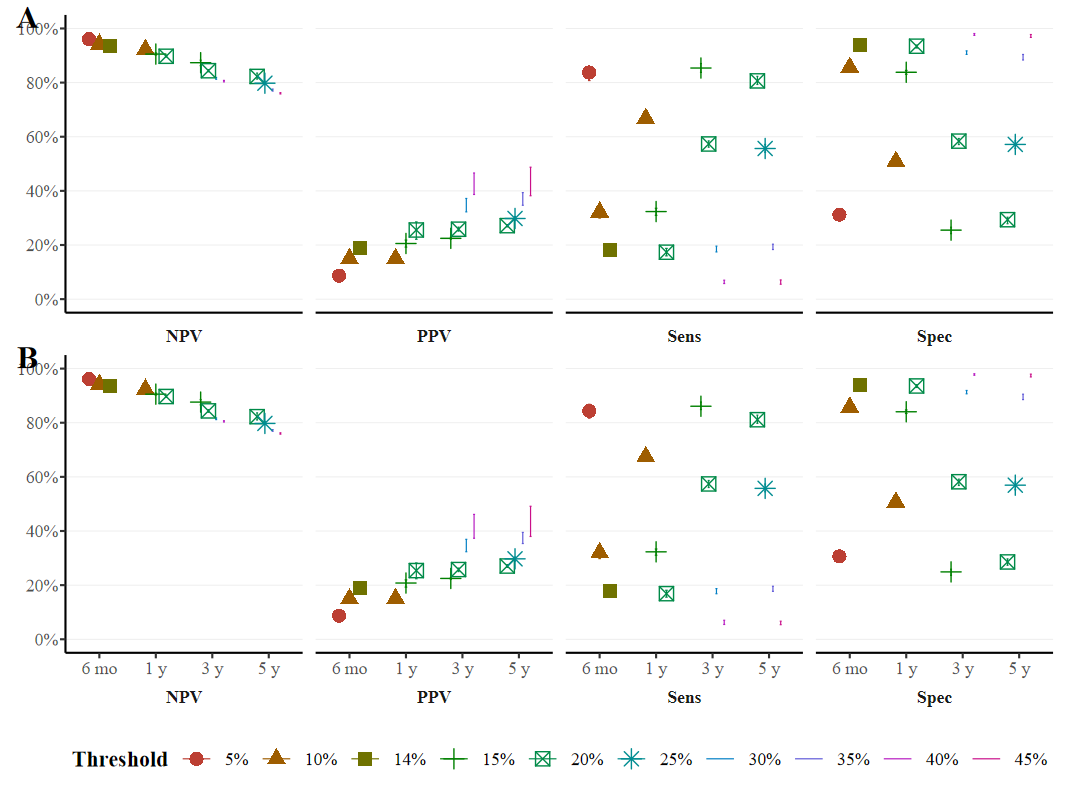

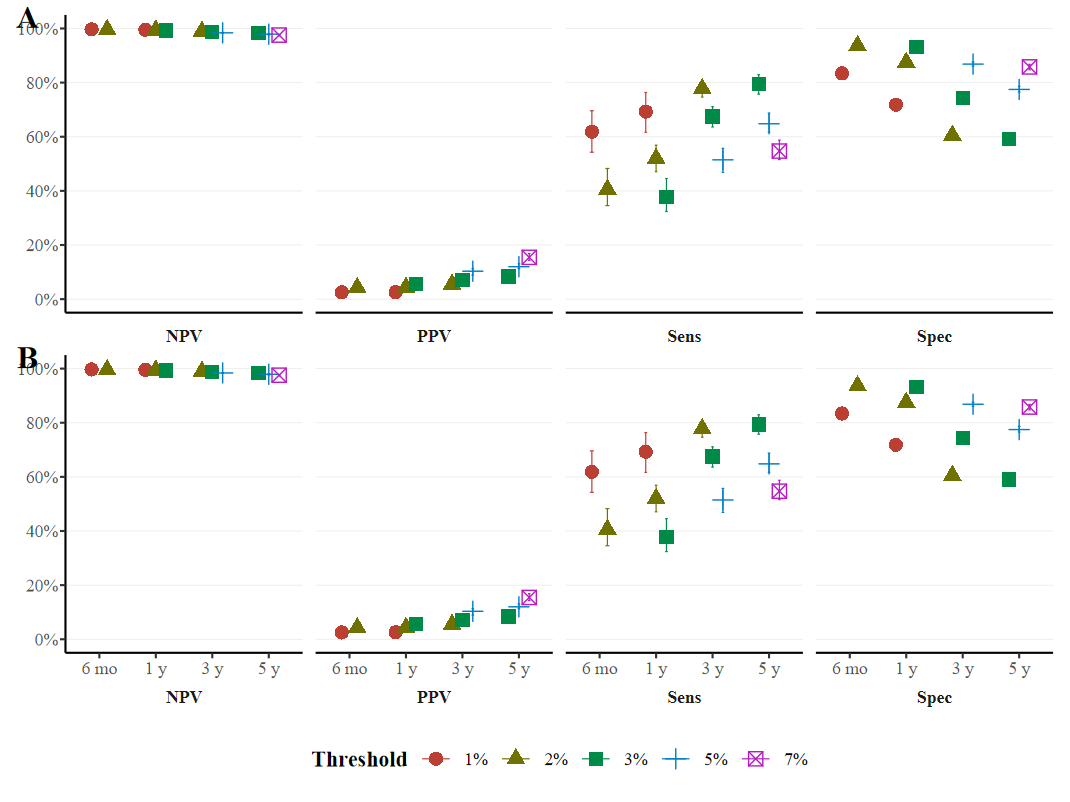

In [44]:
#| label: threshold-metrics-plot
#| message: false
#| fig-width: 10
#| fig-height: 5

source(file.path(project_root, "cons/_hist_scripts/plot_threshold_metrics_from_summary_long.R"))

# panel_models MUST match the labels passed to run_threshold_metrics_*.
# Points = mean across CV replicates; bars = empirical 2.5th-97.5th percentiles
# (split-to-split spread, NOT confidence intervals).
figs_thr_metrics <- plot_threshold_metrics_separate_outcomes(
  summary_long = threshold_out_best2$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  save_files   = FALSE
)

# Render both figures
print(figs_thr_metrics$outcomes$Readmission$plot)
print(figs_thr_metrics$outcomes$Death$plot)


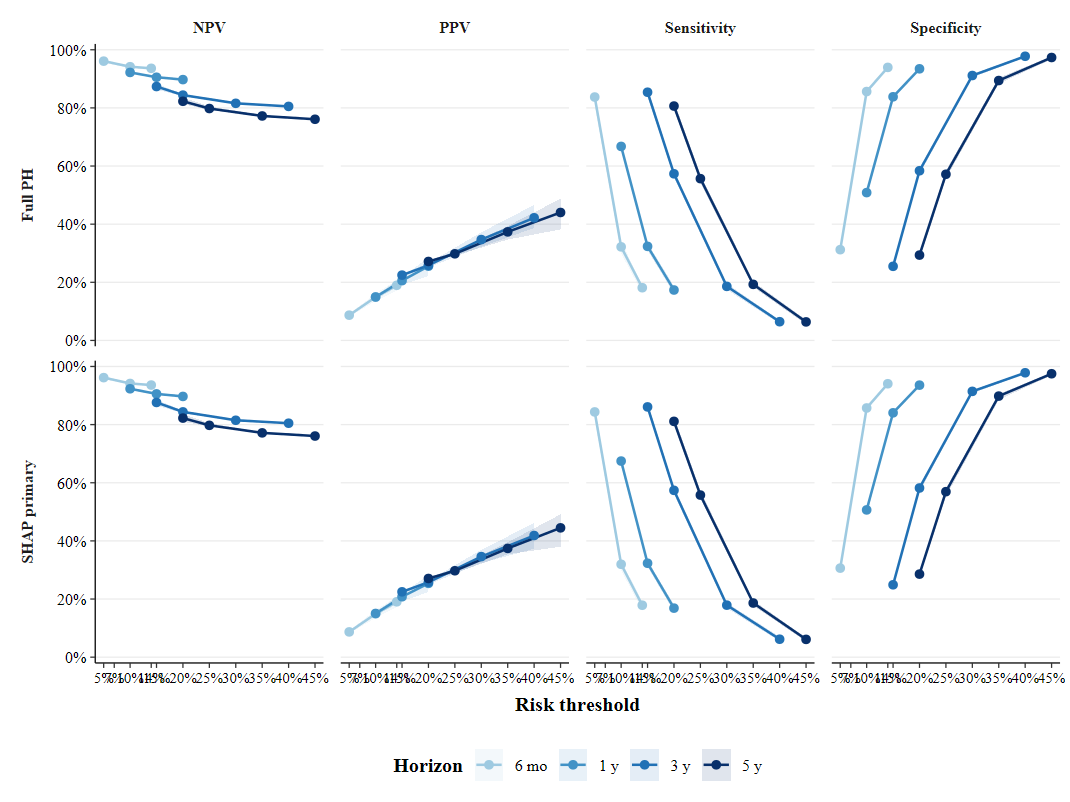

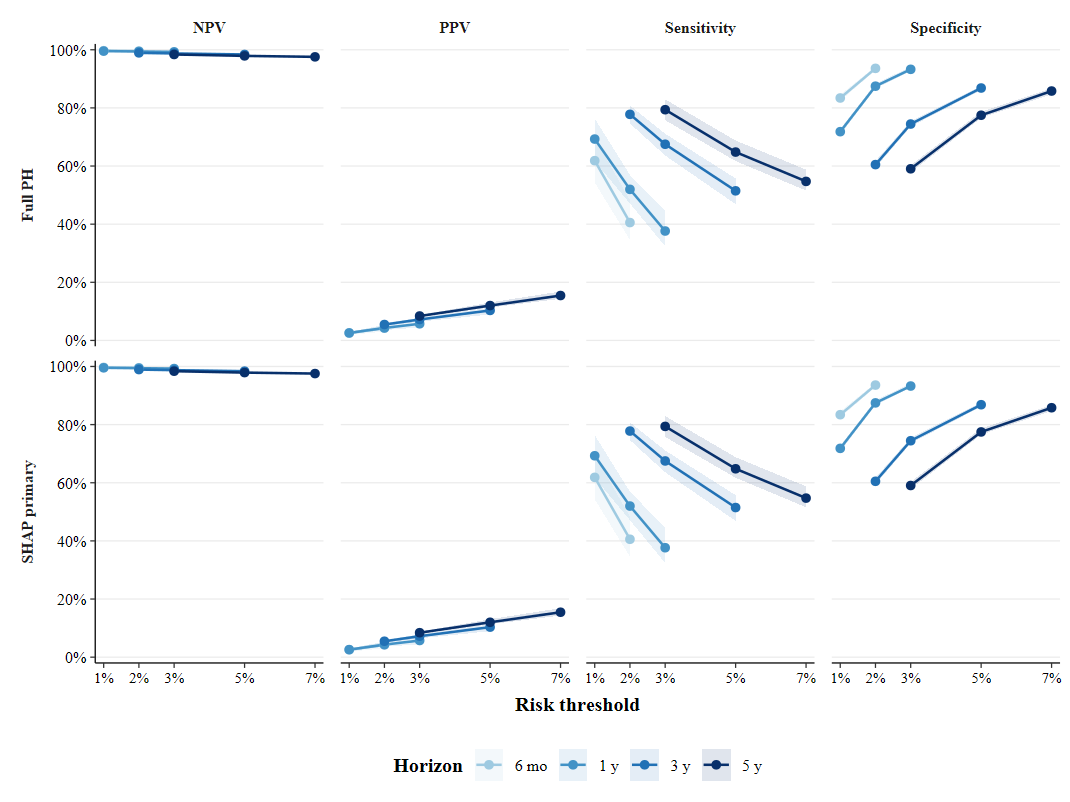

In [45]:
#| label: threshold-metrics-epidemiology-corrected
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean.R"))

figs_thr_metrics <- plot_threshold_metrics_clean(
  summary_long = threshold_out_best2$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon",   # "errorbar" o "none" si lo quieres aÃƒÂºn mÃƒÂ¡s limpio
  save_files   = FALSE
)

print(figs_thr_metrics$outcomes$Readmission$plot)
print(figs_thr_metrics$outcomes$Death$plot)


In [46]:
#| label: threshold-metrics-epidemiology2
#| results: hold

# Ã¢â€â‚¬Ã¢â€â‚¬ Threshold metrics: best_perf vs best_perf2 Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
threshold_out_bestperf12 <- run_threshold_metrics_from_results_boot(
  results_boot_reference = results_shap_xgb_py_upd_best_perf,   # best_perf
  results_boot_updated   = results_shap_xgb_py_upd_best_perf2,  # best_perf2
  threshold_spec  = threshold_spec,        # mismo spec de la celda anterior
  reference_label = "SHAP primary",        # best_perf
  updated_label   = "SHAP implemented",    # best_perf2
  estimator       = "ipcw",                # competing-risk readmission; admin-IPCW death
  output_dir = file.path(project_root, "cons", "_out", "threshold_metrics_bestperf12"),
  prefix     = "threshold_metrics_bestperf12"
)
cat(sprintf("Readmission competing-risk reps=%d | fallback=%d\n",
            threshold_out_bestperf12$config$n_readmit_competing_risk,
            threshold_out_bestperf12$config$n_readmit_ipcw_fallback))


Threshold metrics: IPCW. Readmission competing-risk on 50 replicate(s). Death: admin-censoring IPCW.
Readmission competing-risk reps=50 | fallback=0


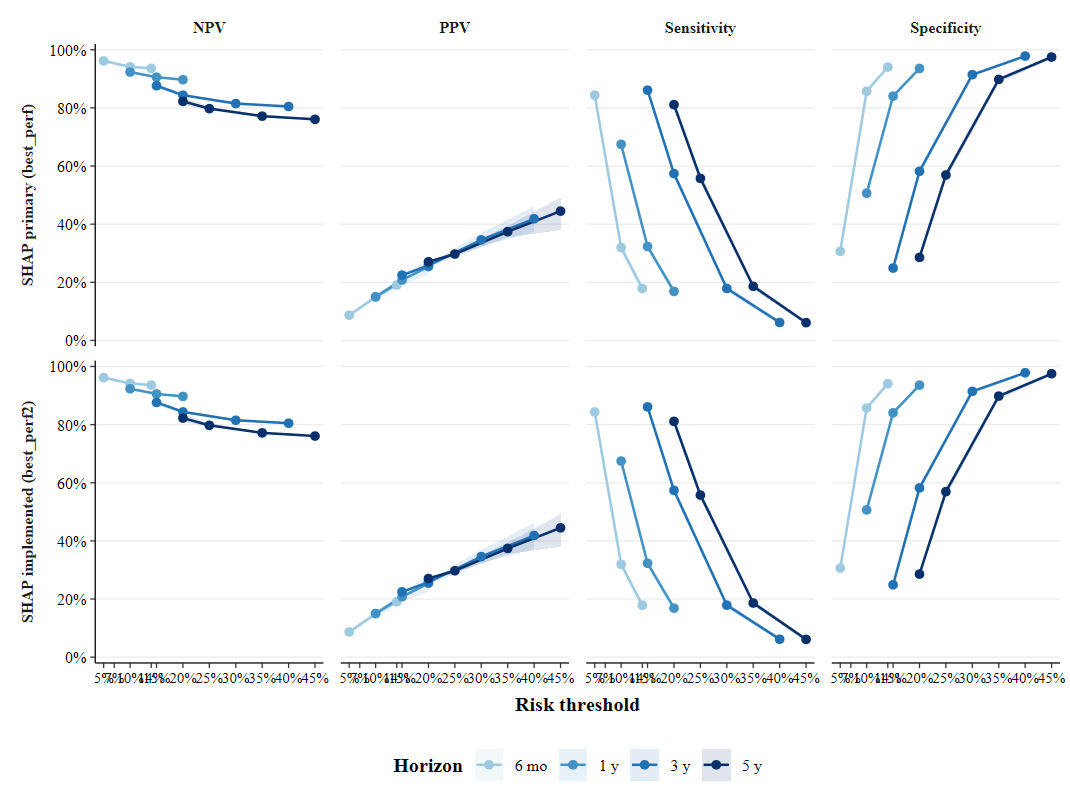

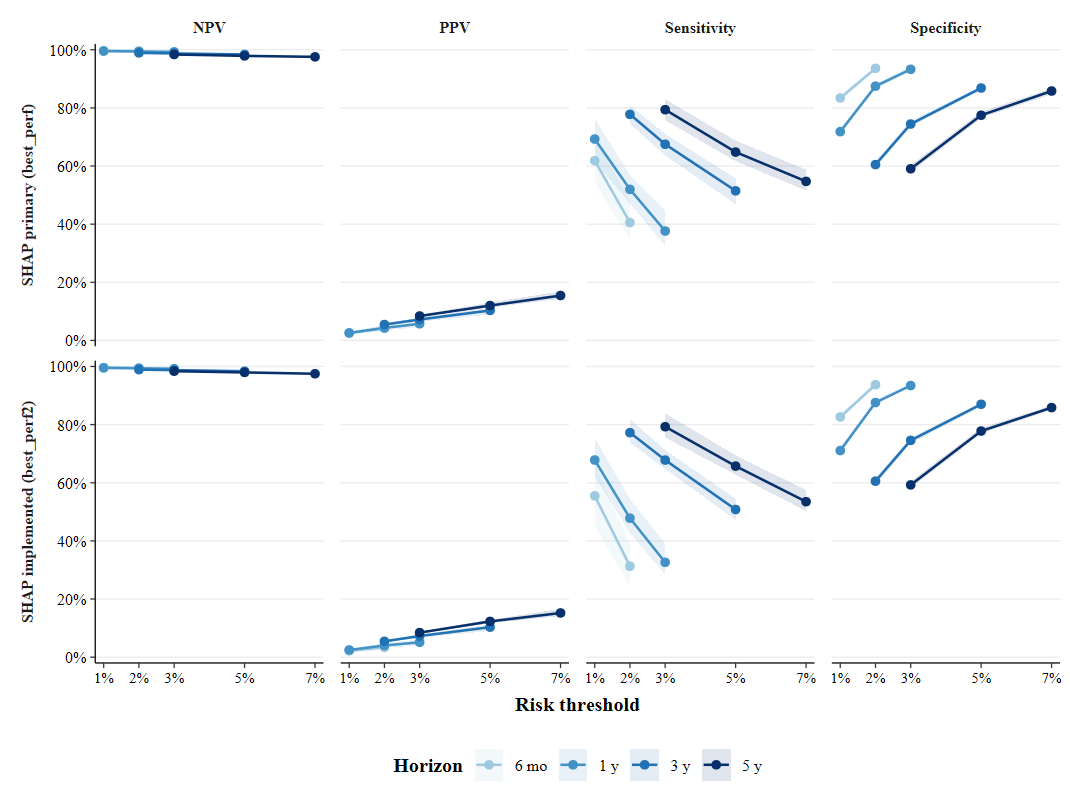

In [47]:
#| label: threshold-metrics-epidemiology3
#| results: hold

figs_bestperf12 <- plot_threshold_metrics_clean(
  summary_long = threshold_out_bestperf12$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("SHAP primary", "SHAP implemented"),
  panel_titles = c("SHAP primary (best_perf)", "SHAP implemented (best_perf2)"),
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon",
  save_files   = FALSE
)
print(figs_bestperf12$outcomes$Readmission$plot)
print(figs_bestperf12$outcomes$Death$plot)


In [48]:
#| label: threshold-metrics-epidemiology4-save
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/save_threshold_metric_figures.R"))

out_fig <- file.path(project_root, "cons", "_figs")

# Figura principal (Full PH vs SHAP primary)
save_threshold_metric_figures(
  figs_thr_metrics, output_dir = out_fig,
  prefix  = "threshold_clean_primary",
  formats = c("png", "pdf", "tiff"))

# Figura best_perf vs best_perf2
save_threshold_metric_figures(
  figs_bestperf12, output_dir = out_fig,
  prefix  = "threshold_clean_bestperf12",
  formats = c("png", "pdf", "tiff"))


Saved 6 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 25 warnings (use warnings() to see them)


Saved 6 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 24 warnings (use warnings() to see them)


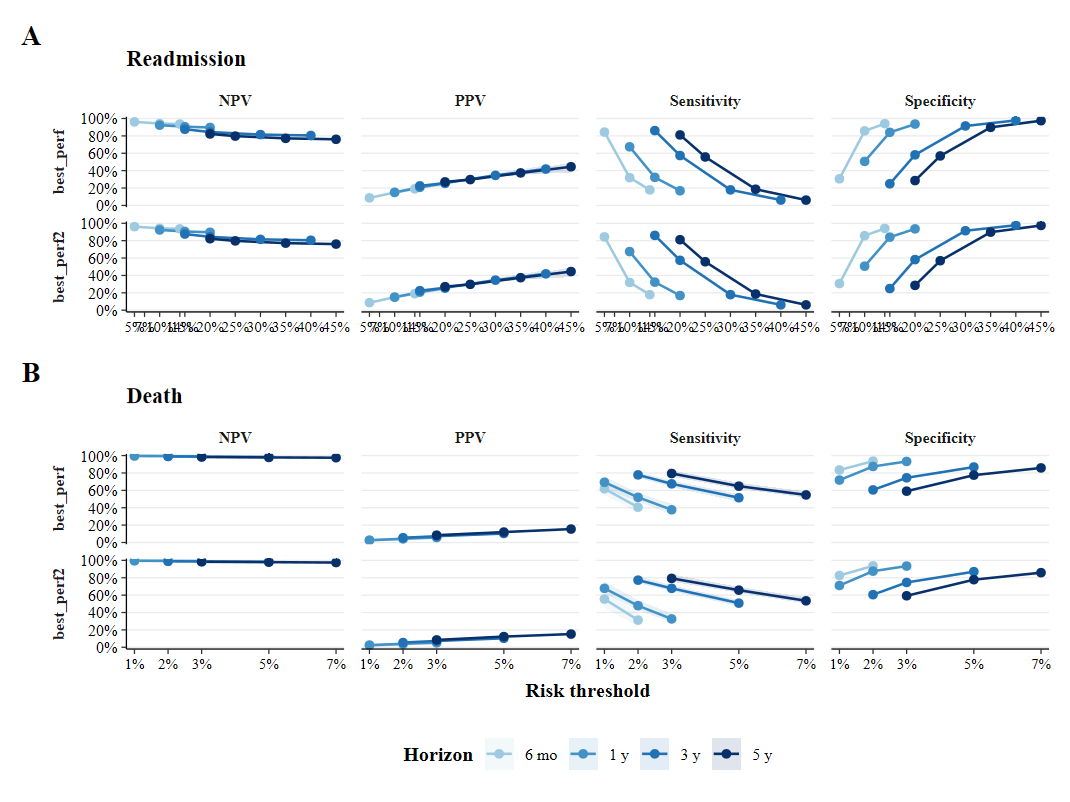

In [49]:
#| label: threshold-metrics-epidemiology5-combined
#| results: hold
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean.R"))
source(file.path(project_root, "cons/_alt_scripts/plot_threshold_metrics_clean_combined.R"))

fig_comb_bp12 <- plot_threshold_metrics_clean_combined(
  summary_long = threshold_out_bestperf12$summary_long,
  horizons     = c(6, 12, 36, 60),
  panel_models = c("SHAP primary", "SHAP implemented"),  # debe calzar con summary_long
  panel_titles = c("best_perf", "best_perf2"),           # rÃƒÂ³tulo de fila (libre)
  metrics      = c("NPV", "PPV", "Sens", "Spec"),
  uncertainty  = "ribbon"
)
print(fig_comb_bp12$plot)


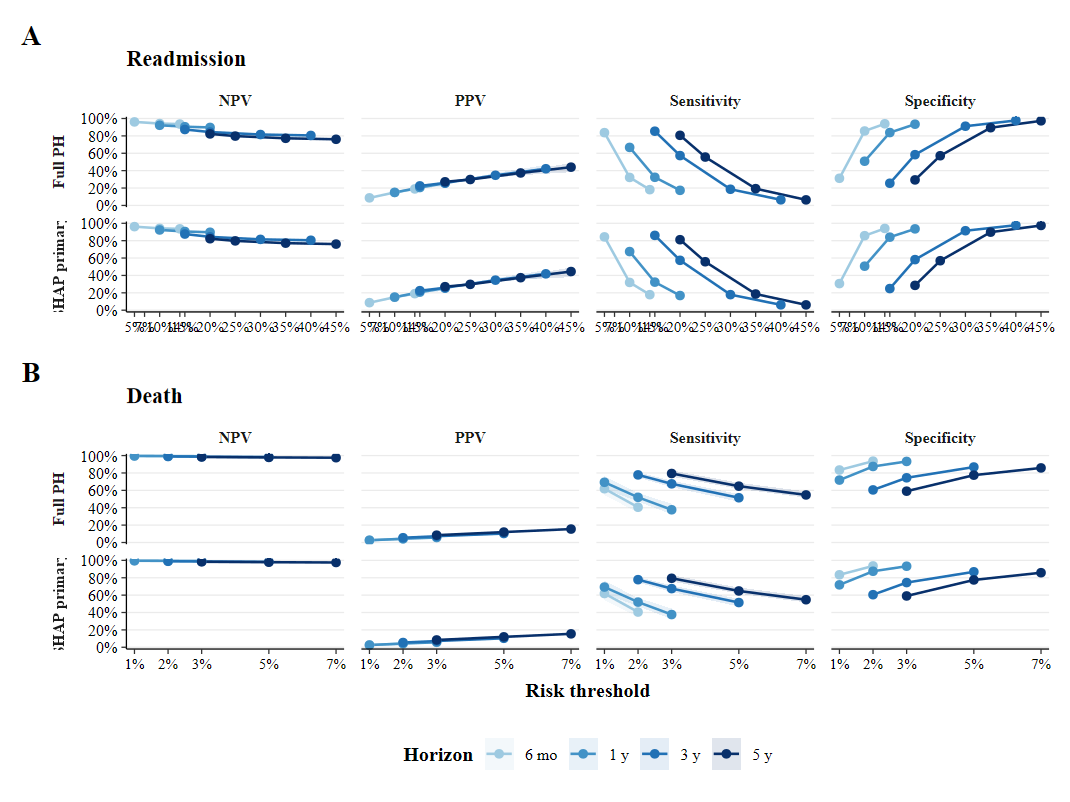

In [50]:
#| label: threshold-metrics-epidemiology5-plot2
#| results: hold
fig_comb_primary <- plot_threshold_metrics_clean_combined(
  summary_long = threshold_out_best2$summary_long,
  panel_models = c("Full PH updated2", "SHAP primary"),
  panel_titles = c("Full PH", "SHAP primary"),
  uncertainty  = "ribbon"
)
print(fig_comb_primary$plot)


In [51]:
#| label: threshold-metrics-epidemiology6-save-combined
#| results: hold
out_fig <- file.path(project_root, "cons", "_figs")

save_threshold_metric_figures(
  fig_comb_bp12, output_dir = out_fig,
  prefix    = "threshold_clean_bestperf12_combined",
  height_cm = 20, width_cm = 19,
  formats   = c("png", "pdf", "tiff"))

save_threshold_metric_figures(
  fig_comb_primary, output_dir = out_fig,
  prefix    = "threshold_clean_fullph_shap_combined",
  height_cm = 20, width_cm = 19,
  formats   = c("png", "pdf", "tiff"))

Saved 3 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 33 warnings (use warnings() to see them)


Saved 3 file(s) to G:/My Drive/Alvacast/SISTRAT 2023/cons/_figs


There were 29 warnings (use warnings() to see them)


In [52]:
#| label: threshold-metrics-table-html
#| message: false
#| results: asis

library(htmltools)

thr_tbl <- threshold_out_best2$summary_wide  # one row per Model x Risk x Time x Threshold

utils::write.csv(
  thr_tbl,
  file.path(project_root, "cons", "_out", "table_threshold_metrics_best2.csv"),
  row.names = FALSE
)

htmltools::browsable(htmltools::tags$div(
  style = "max-height:550px; overflow:auto; border:1px solid #ddd; font-family:Arial, sans-serif; font-size:12px;",
  htmltools::tags$table(
    style = "border-collapse:collapse; width:max-content; min-width:100%;",
    htmltools::tags$thead(htmltools::tags$tr(lapply(names(thr_tbl), function(nm)
      htmltools::tags$th(style = "position:sticky; top:0; background:#f3f3f3; border-bottom:1px solid #ccc; padding:4px 8px; text-align:left; white-space:nowrap;", nm)))),
    htmltools::tags$tbody(lapply(seq_len(nrow(thr_tbl)), function(i)
      htmltools::tags$tr(lapply(thr_tbl[i, ], function(x)
        htmltools::tags$td(style = "border-bottom:1px solid #eee; padding:3px 8px; white-space:nowrap;", as.character(x))))))
  )
))

Model,Risk,Time,Threshold,n_replicates,mean_valid_n,mean_cases_n,mean_controls_n,mean_pred_positive_n,NPV,PPV,Sens,Spec,F1
Full PH updated2,Death,6,0.01,25,12911.6,92.6,12819,2386.52,0.997 (0.996 to 0.998),0.025 (0.019 to 0.030),0.619 (0.543 to 0.696),0.834 (0.824 to 0.846),0.049 (0.037 to 0.058)
Full PH updated2,Death,6,0.02,25,12911.6,92.6,12819,932.52,0.996 (0.995 to 0.997),0.042 (0.030 to 0.052),0.406 (0.346 to 0.483),0.936 (0.930 to 0.943),0.076 (0.056 to 0.092)
Full PH updated2,Death,12,0.01,25,12464.6,141.2,12323.4,4055.76,0.995 (0.994 to 0.997),0.026 (0.021 to 0.030),0.693 (0.617 to 0.764),0.718 (0.707 to 0.728),0.050 (0.041 to 0.058)
Full PH updated2,Death,12,0.02,25,12464.6,141.2,12323.4,1837.72,0.994 (0.993 to 0.995),0.043 (0.036 to 0.053),0.520 (0.471 to 0.569),0.875 (0.867 to 0.884),0.080 (0.066 to 0.098)
Full PH updated2,Death,12,0.03,25,12464.6,141.2,12323.4,1000.64,0.993 (0.992 to 0.994),0.057 (0.045 to 0.068),0.376 (0.324 to 0.446),0.933 (0.926 to 0.941),0.099 (0.078 to 0.116)
Full PH updated2,Death,36,0.02,25,9745.8,340,9405.8,5771.68,0.989 (0.988 to 0.991),0.055 (0.050 to 0.059),0.778 (0.746 to 0.808),0.605 (0.594 to 0.618),0.102 (0.094 to 0.109)
Full PH updated2,Death,36,0.03,25,9745.8,340,9405.8,3833.64,0.987 (0.986 to 0.989),0.072 (0.065 to 0.079),0.675 (0.636 to 0.711),0.744 (0.736 to 0.755),0.130 (0.118 to 0.142)
Full PH updated2,Death,36,0.05,25,9745.8,340,9405.8,2069.68,0.984 (0.983 to 0.985),0.103 (0.089 to 0.113),0.515 (0.469 to 0.557),0.868 (0.861 to 0.876),0.172 (0.150 to 0.187)
Full PH updated2,Death,60,0.03,25,6811.2,475.8,6335.4,6271.2,0.984 (0.981 to 0.986),0.084 (0.081 to 0.088),0.794 (0.758 to 0.829),0.591 (0.579 to 0.603),0.152 (0.146 to 0.158)
Full PH updated2,Death,60,0.05,25,6811.2,475.8,6335.4,3732.28,0.979 (0.976 to 0.981),0.120 (0.113 to 0.131),0.648 (0.617 to 0.688),0.775 (0.765 to 0.787),0.202 (0.192 to 0.220)


---

## 8. Delta IBS /Uno's C

The four delta chunks are consumers: they read `dual_fits[[nm]]$raw_predictions` and extract per-subject predictions; they never re-fit Cox. That makes paired bootstrap cheap.

It is separate from the scattered evaluate_dual_cox_python_style() calls for three reasons:
1. Common grid. GRID <- c(3,6,12,36,60) is applied to all specs at once. ÃŽâ€IBS is only valid when both objects integrate over the same grid.
2. Intact predictions. Saved objects elsewhere are stripped via .strip_raw() to keep RDS small. Cell 72 leaves predictions intact, which is required for OOF reconstruction.
3. Valid pairing. All five models are fit in one loop over the same py_corrected_datasets_boot and k_folds = 5. This guarantees the paired delta chunks compare identical folds, imputations, and subjects.

Why run it first: Cell 72 now validates and loads the intact common-grid OOF predictions from `pred22_ndp_2026_07_13__dualfits.rds` by default. These predictions already contain the fixed-strata fits and are unaffected by the IBS lookup error. Cox models are refit only if `DELTAC_IBS_REFIT <- TRUE`; a formula or grid mismatch stops rather than silently reusing stale fits. For the IBS repair, run cells 8, 9, 72, 76, 77 and 89.

In [53]:
#| label: deltaCIBS-cv-fit-commongrid
.t0 <- proc.time()
DELTAC_IBS_REFIT <- FALSE
DELTAC_IBS_CACHE <- file.path(project_root,"data","20241015_out",
  "pred22_ndp_2026_07_13__dualfits.rds")

GRID <- c(3, 6, 12, 36, 60)
specs <- list(  
  base     = list(formula_readmit, formula_death),
  updated  = list(formula_readmit_updated, formula_death_updated),
  updated2 = list(formula_readmit_updated2, formula_death_updated2),
  shap     = list(formula_shap_readmit_clean_updated, formula_shap_death_rule2),
  interact = list(formula_shap_readmit_interact, formula_shap_death_interact)
)
clean_strata <- function(f) stats::as.formula(gsub("strat\\(","strata(",paste(deparse(f),collapse=" ")))
.formula_key <- function(f) {
  txt <- if (is.character(f)) paste(f,collapse=" ") else paste(deparse(f),collapse=" ")
  gsub("[[:space:]]+","",txt)
}

if (!DELTAC_IBS_REFIT && file.exists(DELTAC_IBS_CACHE)) {
  .cached <- readRDS(DELTAC_IBS_CACHE)
  dual_fits <- .cached$dual_fits
  stopifnot(identical(names(dual_fits),names(specs)))
  for (nm in names(specs)) {
    fit <- dual_fits[[nm]]
    stopifnot(length(fit$raw_predictions)>0L,identical(as.numeric(fit$config$eval_times),GRID))
    expected_r <- .formula_key(clean_strata(specs[[nm]][[1]]))
    expected_d <- .formula_key(clean_strata(specs[[nm]][[2]]))
    if (!identical(.formula_key(fit$config$formula_readmit),expected_r) ||
        !identical(.formula_key(fit$config$formula_death),expected_d))
      stop("Cached common-grid formulas differ from the current specs; set DELTAC_IBS_REFIT <- TRUE.")
  }
  cat("Loaded validated common-grid raw predictions; Cox refitting was skipped.\n")
  rm(.cached)
} else {
  dual_fits <- list()
  for (nm in names(specs)) {
    fr <- specs[[nm]][[1]]; fd <- specs[[nm]][[2]]
    if (is.null(fr) || is.null(fd)) { message("skip ", nm); next }
    cat("dual:", nm, "\n"); flush.console()
    dual_fits[[nm]] <- evaluate_dual_cox_python_style(
      formula_readmit = clean_strata(fr), formula_death = clean_strata(fd),
      imputed_list = py_corrected_datasets_boot, k_folds = 5, eval_times = GRID)
  }
}
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60
cat(sprintf("[chunk: deltaCIBS-cv-fit-commongrid] %.3f min\n",.elapsed))


Loaded validated common-grid raw predictions; Cox refitting was skipped.
[chunk: deltaCIBS-cv-fit-commongrid] 0.040 min


~ 15 minutes

In [56]:
#| label: deltaCIBS-ds-common-grid
#| message: true
#| warning: true
.t0 <- proc.time()
# Build or reuse a DS-only common-grid cache without changing the validated primary p225 object.
if (!exists("evaluate_dual_cox_python_style", mode = "function", inherits = TRUE)) stop("Run source-functions before this chunk.", call.
= FALSE)
if (!exists("py_corrected_datasets_boot", envir = .GlobalEnv, inherits = FALSE)) stop("Run load-data before this chunk.", call. = FALSE)
if (!exists(".p225_input_manifest", envir = .GlobalEnv, inherits = FALSE)) stop("The canonical input manifest is unavailable. Rerun
load-data.", call. = FALSE)
if (!is.list(py_corrected_datasets_boot) || length(py_corrected_datasets_boot) != 5L) stop("Expected exactly five canonical
imputations.", call. = FALSE)
DS_GRID <- c(3, 6, 12, 36, 60)
DS_FOLDS <- 5L
DS_SEED <- 2125L
DS_OUT_DIR <- file.path(project_root, "data", "20241015_out")
if (!dir.exists(DS_OUT_DIR)) stop("The data output directory is unavailable: ", DS_OUT_DIR, call. = FALSE)
# Select the newest complete p24 DS sidecar set and reject incomplete or mixed stems.
ds_suffixes <- c("dual_shap_ds_py", "dual_shap_ds_upd_py", "dual_shap_ds_int_py")
ds_pattern <- paste0("^pred24.*__(", paste(ds_suffixes, collapse = "|"), ")\\.rds$")
ds_sidecar_files <- list.files(DS_OUT_DIR, pattern = ds_pattern, full.names = TRUE)
if (length(ds_sidecar_files) == 0L) stop("No p24 DS sidecars were found in: ", DS_OUT_DIR, call. = FALSE)
ds_sidecar_names <- basename(ds_sidecar_files)
ds_sidecar_stems <- sub(paste0("__(?:", paste(ds_suffixes, collapse = "|"), ")\\.rds$"), "", ds_sidecar_names, perl = TRUE)
ds_complete_stems <- unique(ds_sidecar_stems[vapply(unique(ds_sidecar_stems), function(stem) {
  expected <- file.path(DS_OUT_DIR, paste0(stem, "__", ds_suffixes, ".rds"))
  all(file.exists(expected))
}, logical(1))])
if (length(ds_complete_stems) == 0L) stop("No complete p24 DS sidecar triplet was found.", call. = FALSE)
ds_stem_mtime <- vapply(ds_complete_stems, function(stem) {
  expected <- file.path(DS_OUT_DIR, paste0(stem, "__", ds_suffixes, ".rds"))
  max(file.info(expected)$mtime)
}, as.POSIXct("1970-01-01", tz = "UTC"))
DS_SIDECAR_STEM <- ds_complete_stems[which.max(ds_stem_mtime)]
DS_SIDECAR_PATHS <- stats::setNames(file.path(DS_OUT_DIR, paste0(DS_SIDECAR_STEM, "__", ds_suffixes, ".rds")), c("base", "nph",
"interact"))
DS_CACHE <- file.path(DS_OUT_DIR, paste0("pred225_ds_common_grid__", DS_SIDECAR_STEM, "__v1.rds"))
DS_REFIT <- !file.exists(DS_CACHE)
# Parse character formulas stored by p24 sidecars and validate their required variables before fitting.
.ds_formula_key <- function(formula_object) {
  formula_object <- .ds_parse_formula(formula_object, "DS formula comparison")
  gsub("[[:space:]]+", "", paste(deparse(formula_object), collapse = " "))
}
.ds_parse_formula <- function(formula_value, label) {
  formula_object <- if (inherits(formula_value, "formula")) {
    formula_value
  } else if (is.character(formula_value) && length(formula_value) == 1L && nzchar(formula_value)) {
    stats::as.formula(formula_value, env = .GlobalEnv)
  } else {
    stop("Invalid DS formula in ", label, ".", call. = FALSE)
  }
  if (!inherits(formula_object, "formula")) stop("Could not parse DS formula in ", label, ".", call. = FALSE)
  formula_object
}
.ds_extract_sidecar_formulas <- function(path, label) {
  if (!file.exists(path)) stop("Missing DS sidecar: ", path, call. = FALSE)
  sidecar <- readRDS(path)
  if (!is.list(sidecar) || !is.list(sidecar$results) || !is.list(sidecar$results$risk) || !is.list(sidecar$results$risk$config)) {
    stop("DS sidecar has no risk configuration: ", basename(path), call. = FALSE)
  }
  config <- sidecar$results$risk$config
  if (!identical(as.numeric(config$eval_times), DS_GRID)) {
    stop("DS sidecar grid differs from the required common grid in ", basename(path), ".", call. = FALSE)
  }
  out <- list(
    formula_readmit = .ds_parse_formula(config$formula_readmit, paste(label, "readmission")),
    formula_death = .ds_parse_formula(config$formula_death, paste(label, "death"))
  )
  rm(sidecar, config)
  gc(verbose = FALSE)
  out
}
ds_formula_sets <- lapply(names(DS_SIDECAR_PATHS), function(label) {
  .ds_extract_sidecar_formulas(DS_SIDECAR_PATHS[[label]], label)
})
names(ds_formula_sets) <- names(DS_SIDECAR_PATHS)
ds_common_columns <- Reduce(intersect, lapply(py_corrected_datasets_boot, names))
ds_outcome_columns <- c("readmit_time_from_disch_m", "readmit_event", "death_time_from_disch_m", "death_event")
for (model_name in names(ds_formula_sets)) {
  for (outcome_name in c("readmission", "death")) {
    formula_name <- if (outcome_name == "readmission") "formula_readmit" else "formula_death"
    required_predictors <- setdiff(all.vars(ds_formula_sets[[model_name]][[formula_name]]), ds_outcome_columns)
    missing_predictors <- setdiff(required_predictors, ds_common_columns)
    if (length(missing_predictors) > 0L) {
      stop("DS ", model_name, " ", outcome_name, " formula requires missing predictor(s): ", paste(missing_predictors, collapse = ", "),
      call. = FALSE)
    }
  }
}
# Define outcome-specific candidates so only the target outcome changes in each comparison.
ds_specs <- list(
  ds_base = list(formula_readmit = ds_formula_sets$base$formula_readmit, formula_death = ds_formula_sets$base$formula_death),
  ds_nph_readmit = list(formula_readmit = ds_formula_sets$nph$formula_readmit, formula_death = ds_formula_sets$base$formula_death),
  ds_interact_readmit = list(formula_readmit = ds_formula_sets$interact$formula_readmit, formula_death =
  ds_formula_sets$base$formula_death),
  ds_nph_death = list(formula_readmit = ds_formula_sets$base$formula_readmit, formula_death = ds_formula_sets$nph$formula_death),
  ds_interact_death = list(formula_readmit = ds_formula_sets$base$formula_readmit, formula_death =
  ds_formula_sets$interact$formula_death)
)
.ds_specs_signature <- lapply(ds_specs, function(specification) {
  c(readmission = .ds_formula_key(specification$formula_readmit), death = .ds_formula_key(specification$formula_death))
})
# Verify that the current canonical input has the same observed outcomes and row order as the primary OOF cache.
.ds_extract_raw_outcomes <- function(fit, outcome, imputation_index) {
  raw_predictions <- fit$raw_predictions
  blocks <- Filter(function(block) identical(as.integer(block$imp_idx), as.integer(imputation_index)), raw_predictions)
  if (length(blocks) != DS_FOLDS) stop("Primary cache has an unexpected number of OOF blocks for imputation ", imputation_index, ".",
  call. = FALSE)
  n_rows <- max(vapply(blocks, function(block) max(block$original_val_idx), integer(1)))
  time <- rep(NA_real_, n_rows)
  event <- rep(NA_real_, n_rows)
  for (block in blocks) {
    outcome_block <- block[[outcome]]
    if (is.null(outcome_block) || !is.null(outcome_block$error) || is.null(outcome_block$y_val)) stop("Primary cache has incomplete ",
    outcome, " OOF predictions.", call. = FALSE)
    index <- as.integer(block$original_val_idx)
    y_val <- as.matrix(outcome_block$y_val)
    time[index] <- as.numeric(y_val[, 1L])
    event[index] <- as.numeric(y_val[, 2L])
  }
  list(time = time, event = event)
}
if (exists("dual_fits", envir = .GlobalEnv, inherits = FALSE) && is.list(dual_fits) && !is.null(dual_fits$base$raw_predictions)) {
  ds_primary_reference <- dual_fits$base
} else {
  ds_primary_cache <- file.path(DS_OUT_DIR, "pred22_ndp_2026_07_13__dualfits.rds")
  if (!file.exists(ds_primary_cache)) stop("The validated primary OOF cache is missing: ", ds_primary_cache, call. = FALSE)
  ds_primary_bundle <- readRDS(ds_primary_cache)
  if (is.null(ds_primary_bundle$dual_fits$base$raw_predictions)) stop("The validated primary OOF cache has no baseline raw
  predictions.", call. = FALSE)
  ds_primary_reference <- ds_primary_bundle$dual_fits$base
  rm(ds_primary_bundle)
  gc(verbose = FALSE)
}
for (imputation_index in seq_along(py_corrected_datasets_boot)) {
  cached_readmission <- .ds_extract_raw_outcomes(ds_primary_reference, "readmission", imputation_index)
  cached_death <- .ds_extract_raw_outcomes(ds_primary_reference, "death", imputation_index)
  current_data <- py_corrected_datasets_boot[[imputation_index]]
  if (!isTRUE(all.equal(cached_readmission$time, as.numeric(current_data$readmit_time_from_disch_m), tolerance = 0, check.attributes =
  FALSE)) ||
      !identical(cached_readmission$event, as.numeric(current_data$readmit_event)) ||
      !isTRUE(all.equal(cached_death$time, as.numeric(current_data$death_time_from_disch_m), tolerance = 0, check.attributes = FALSE))
      ||
      !identical(cached_death$event, as.numeric(current_data$death_event))) {
    stop("Canonical input outcomes do not match the validated primary OOF cache for imputation ", imputation_index, ".", call. = FALSE)
  }
}
.ds_validate_cached_fit <- function(fit, specification, model_name) {
  if (is.null(fit$raw_predictions) || length(fit$raw_predictions) != length(py_corrected_datasets_boot) * DS_FOLDS) {
    stop("Cached DS fit has incomplete raw predictions: ", model_name, call. = FALSE)
  }
  if (!identical(as.numeric(fit$config$eval_times), DS_GRID)) stop("Cached DS grid differs for ", model_name, ".", call. = FALSE)
  if (!identical(.ds_formula_key(fit$config$formula_readmit), .ds_formula_key(specification$formula_readmit)) ||
      !identical(.ds_formula_key(fit$config$formula_death), .ds_formula_key(specification$formula_death))) {
    stop("Cached DS formulas differ for ", model_name, ". Delete only the DS cache after confirming the intended new specification.",
    call. = FALSE)
  }
  if (!identical(fit$fold_assignments, ds_primary_reference$fold_assignments)) {
    stop("Cached DS folds differ from the validated primary OOF folds for ", model_name, ".", call. = FALSE)
  }
  invisible(TRUE)
}
.ds_evaluate_sequentially <- function(specification, model_name) {
  old_options <- options(dualcox.concordance_score = "lp", dualcox.concordance_within_strata = FALSE)
  on.exit(options(old_options), add = TRUE)
  cat("Fitting DS common-grid candidate:", model_name, "| 5 imputations x 5 folds | sequential to avoid nested parallelism.\n")
  flush.console()
  evaluate_dual_cox_python_style(
    formula_readmit = specification$formula_readmit,
    formula_death = specification$formula_death,
    imputed_list = py_corrected_datasets_boot,
    k_folds = DS_FOLDS,
    eval_times = DS_GRID,
    seed = DS_SEED,
    verbose = TRUE
  )
}
if (!DS_REFIT) {
  ds_cache_bundle <- readRDS(DS_CACHE)
  if (!identical(ds_cache_bundle$sidecar_stem, DS_SIDECAR_STEM) || !identical(ds_cache_bundle$input_rdata, .p225_input_manifest$path)
  || !identical(ds_cache_bundle$grid, DS_GRID) || !identical(ds_cache_bundle$specs_signature, .ds_specs_signature)) {
    stop("The existing DS cache does not match the canonical input, sidecars, grid, or formulas.", call. = FALSE)
  }
  ds_dual_fits <- ds_cache_bundle$ds_dual_fits
  if (!identical(names(ds_dual_fits), names(ds_specs))) stop("The existing DS cache has an unexpected model manifest.", call. = FALSE)
  for (model_name in names(ds_specs)) .ds_validate_cached_fit(ds_dual_fits[[model_name]], ds_specs[[model_name]], model_name)
  rm(ds_cache_bundle)
  cat("Loaded validated DS common-grid cache; DS Cox refitting was skipped.\n")
} else {
  ds_dual_fits <- vector("list", length(ds_specs))
  names(ds_dual_fits) <- names(ds_specs)
  for (model_name in names(ds_specs)) {
    ds_dual_fits[[model_name]] <- .ds_evaluate_sequentially(ds_specs[[model_name]], model_name)
    .ds_validate_cached_fit(ds_dual_fits[[model_name]], ds_specs[[model_name]], model_name)
    gc(verbose = FALSE)
  }
  ds_cache_bundle <- list(
    sidecar_stem = DS_SIDECAR_STEM,
    sidecar_paths = DS_SIDECAR_PATHS,
    input_rdata = .p225_input_manifest$path,
    input_manifest = .p225_input_manifest,
    grid = DS_GRID,
    folds = DS_FOLDS,
    seed = DS_SEED,
    specs_signature = .ds_specs_signature,
    ds_dual_fits = ds_dual_fits,
    saved_at = Sys.time()
  )
  ds_cache_tmp <- tempfile(pattern = "pred225_ds_common_grid_", tmpdir = DS_OUT_DIR, fileext = ".rds")
  saveRDS(ds_cache_bundle, ds_cache_tmp)
  if (!file.rename(ds_cache_tmp, DS_CACHE)) {
    unlink(ds_cache_tmp)
    stop("Could not atomically create the DS cache: ", DS_CACHE, call. = FALSE)
  }
  rm(ds_cache_bundle)
  cat("Saved validated DS common-grid cache:", DS_CACHE, "\n")
}
for (model_name in names(ds_specs)) .ds_validate_cached_fit(ds_dual_fits[[model_name]], ds_specs[[model_name]], model_name)
cat("DS candidates ready:", paste(names(ds_dual_fits), collapse = ", "), "\n")
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60
cat(sprintf("[chunk: deltaCIBS-ds-common-grid] %.3f min\n", .elapsed))

Fitting DS common-grid candidate: ds_base | 5 imputations x 5 folds | sequential to avoid nested parallelism.
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Fitting DS common-grid candidate: ds_nph_readmit | 5 imputations x 5 folds | sequential to avoid nested parallelism.
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Fitting DS common-grid candidate: ds_interact_readmit | 5 imputations x 5 folds | sequential to avoid nested parallelism.
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Fitting DS common-grid candidate: ds_nph_death | 5 imputations x 5 folds | sequential to avoid nested parallelism.
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
I

In [57]:
#| label: deltaCIBS-ds-risk-selection
#| message: true                                                                                                                        
#| warning: true                                                                                                                        
.t0 <- proc.time()                                                                                                                      
# Evaluate only the four pre-specified DS complexity contrasts using absolute-risk Uno C at each horizon.                               
if (!exists("ds_dual_fits", envir = .GlobalEnv, inherits = FALSE) || !exists("ds_specs", envir = .GlobalEnv, inherits = FALSE))         
stop("Run deltaCIBS-ds-common-grid before this chunk.", call. = FALSE)                                                                  
if (!exists(".cv_extract", mode = "function", inherits = TRUE) || !exists("deltaIBS_boot_x", mode = "function", inherits = TRUE))       
stop("Run deltaCIBS-cv-engine before this chunk.", call. = FALSE)                                                                       
if (!requireNamespace("survival", quietly = TRUE)) stop("Package survival is required for absolute-risk Uno C.", call. = FALSE)         
DS_SELECTION_HORIZONS <- c(6, 12, 36, 60)                                                                                               
DS_DELTA_C_MIN <- 0.01                                                                                                                  
DS_DELTA_IBS_MAX <- 0.001                                                                                                               
DS_IBS_BOOTSTRAPS <- 500L                                                                                                               
ds_required_models <- c("ds_base", "ds_nph_readmit", "ds_interact_readmit", "ds_nph_death", "ds_interact_death")                        
if (!identical(names(ds_dual_fits), ds_required_models) || !identical(names(ds_specs), ds_required_models)) stop("The DS model manifest 
is incomplete or has an unexpected order.", call. = FALSE)                                                                              
if (any(!vapply(ds_dual_fits, function(fit) !is.null(fit$raw_predictions) && length(fit$raw_predictions) == 25L, logical(1)))) stop("At 
least one DS candidate has incomplete OOF predictions.", call. = FALSE)                                                                 
ds_pair_manifest <- data.frame(                                                                                                         
  outcome = c("readmission", "readmission", "death", "death"),                                                                          
  anchor = c("ds_base", "ds_base", "ds_base", "ds_base"),                                                                               
  candidate = c("ds_nph_readmit", "ds_interact_readmit", "ds_nph_death", "ds_interact_death"),
  candidate_type = c("nph_strata", "interactions", "nph_strata", "interactions"),                                                       
  complexity_rank = c(1L, 2L, 1L, 2L),                                                                                                  
  stringsAsFactors = FALSE                                                                                                              
)                                                                                                                                       
.ds_match_horizon <- function(horizon, eval_times) {                                                                                    
  index <- which(abs(as.numeric(eval_times) - as.numeric(horizon)) < 1e-8)                                                              
  if (length(index) != 1L) stop("Horizon ", horizon, " was not found exactly once in the DS evaluation grid.", call. = FALSE)
  index                                                                                                                                 
}                                                                                                                                       
.ds_absolute_risk_delta <- function(anchor_extract, candidate_extract, horizon) {                                                       
  anchor_risk <- pmin(pmax(1 - as.numeric(anchor_extract$S[, .ds_match_horizon(horizon, anchor_extract$eval_times)]), 0), 1)            
  candidate_risk <- pmin(pmax(1 - as.numeric(candidate_extract$S[, .ds_match_horizon(horizon, candidate_extract$eval_times)]), 0), 1)   
  common <- is.finite(anchor_extract$time) & is.finite(anchor_extract$event) & is.finite(candidate_extract$time) &                      
  is.finite(candidate_extract$event) & is.finite(anchor_risk) & is.finite(candidate_risk)                                               
  if (sum(common) < 2L) stop("Too few paired OOF observations at ", horizon, " months.", call. = FALSE)                                 
  if (any(abs(anchor_extract$time[common] - candidate_extract$time[common]) > 1e-8) || any(anchor_extract$event[common] !=              
  candidate_extract$event[common])) {                                                                                                   
    stop("Outcome or follow-up differs between paired DS candidates.", call. = FALSE)                                                   
  }                                                                                                                                     
  comparison_data <- data.frame(
    time = as.numeric(anchor_extract$time[common]),                                                                                     
    event = as.numeric(anchor_extract$event[common]),                                                                                   
    anchor_risk = anchor_risk[common],                                                                                                  
    candidate_risk = candidate_risk[common]                                                                                             
  )                                                                                                                                     
  events_by_horizon <- sum(comparison_data$event == 1L & comparison_data$time <= horizon)                                               
  if (events_by_horizon < 2L) {                                                                                                         
    return(data.frame(                                                                                                                  
      horizon = horizon,                                                                                                                
      n = nrow(comparison_data),                                                                                                        
      events_by_horizon = events_by_horizon,                                                                                            
      C_anchor = NA_real_,                                                                                                              
      C_candidate = NA_real_,                                                                                                           
      delta_C_candidate = NA_real_,                                                                                                     
      delta_C_lower = NA_real_,
      delta_C_upper = NA_real_,                                                                                                         
      stringsAsFactors = FALSE                                                                                                          
    ))                                                                                                                                  
  }                                                                                                                                     
  fit <- tryCatch(                                                                                                                      
    survival::concordance(                                                                                                              
      survival::Surv(time, event) ~ anchor_risk + candidate_risk,                                                                       
      data = comparison_data,                                                                                                           
      timewt = "n/G2",                                                                                                                  
      reverse = TRUE,                                                                                                                   
      ymax = horizon                                                                                                                    
    ),                                                                                                                                  
    error = function(error) NULL                                                                                                        
  )                                                                                                                                     
  if (is.null(fit)) stop("Absolute-risk Uno C failed at ", horizon, " months.", call. = FALSE)                                          
  C_anchor <- unname(fit$concordance[1L])                                                                                               
  C_candidate <- unname(fit$concordance[2L])                                                                                            
  delta_C_candidate <- C_candidate - C_anchor                                                                                           
  covariance <- fit$var                                                                                                                 
  standard_error <- sqrt(max(covariance[1L, 1L] + covariance[2L, 2L] - 2 * covariance[1L, 2L], 0))                                      
  data.frame(                                                                                                                           
    horizon = horizon,                                                                                                                  
    n = nrow(comparison_data),                                                                                                          
    events_by_horizon = events_by_horizon,                                                                                              
    C_anchor = C_anchor,                                                                                                                
    C_candidate = C_candidate,                                                                                                          
    delta_C_candidate = delta_C_candidate,                                                                                              
    delta_C_lower = delta_C_candidate - stats::qnorm(0.975) * standard_error,                                                           
    delta_C_upper = delta_C_candidate + stats::qnorm(0.975) * standard_error,                                                           
    stringsAsFactors = FALSE                                                                                                            
  )                                                                                                                                     
}                                                                                                                                       
.ds_run_one_pair <- function(pair_row) {                                                                                                
  outcome_name <- pair_row$outcome                                                                                                      
  anchor_extract <- .cv_extract(ds_dual_fits[[pair_row$anchor]], outcome_name)                                                          
  candidate_extract <- .cv_extract(ds_dual_fits[[pair_row$candidate]], outcome_name)                                                    
  risk_rows <- do.call(rbind, lapply(DS_SELECTION_HORIZONS, function(horizon) {                                                         
    .ds_absolute_risk_delta(anchor_extract, candidate_extract, horizon)                                                                 
  }))
  ibs_result <- deltaIBS_boot_x(anchor_extract, candidate_extract, B = DS_IBS_BOOTSTRAPS, seed = DS_SEED)                               
  risk_rows$outcome <- outcome_name                                                                                                     
  risk_rows$anchor <- pair_row$anchor                                                                                                   
  risk_rows$candidate <- pair_row$candidate                                                                                             
  risk_rows$candidate_type <- pair_row$candidate_type                                                                                   
  risk_rows$complexity_rank <- pair_row$complexity_rank                                                                                 
  risk_rows$delta_IBS_candidate <- -as.numeric(ibs_result$dIBS)                                                                         
  risk_rows$delta_IBS_lower <- -as.numeric(ibs_result$dIBS_hi)                                                                          
  risk_rows$delta_IBS_upper <- -as.numeric(ibs_result$dIBS_lo)                                                                          
  risk_rows$IBS_anchor <- as.numeric(ibs_result$IBS_A)                                                                                  
  risk_rows$IBS_candidate <- as.numeric(ibs_result$IBS_B)                                                                               
  risk_rows                                                                                                                             
}                                                                                                                                       
ds_risk_rows <- vector("list", nrow(ds_pair_manifest))                                                                                  
for (pair_index in seq_len(nrow(ds_pair_manifest))) {                                                                                   
  pair_row <- ds_pair_manifest[pair_index, , drop = FALSE]                                                                              
  cat(sprintf("[%d/%d] %s: %s -> %s\n", pair_index, nrow(ds_pair_manifest), pair_row$outcome, pair_row$anchor, pair_row$candidate))     
  flush.console()                                                                                                                       
  ds_risk_rows[[pair_index]] <- .ds_run_one_pair(pair_row)                                                                              
  gc(verbose = FALSE)                                                                                                                   
}                                                                                                                                       
ds_risk_c_table <- do.call(rbind, ds_risk_rows)                                                                                         
ds_risk_c_table <- ds_risk_c_table[order(ds_risk_c_table$outcome, ds_risk_c_table$complexity_rank, ds_risk_c_table$horizon), ]          
rownames(ds_risk_c_table) <- NULL                                                                                                       
ds_selection_rows <- lapply(seq_len(nrow(ds_pair_manifest)), function(pair_index) {                                                     
  pair_row <- ds_pair_manifest[pair_index, , drop = FALSE]                                                                              
  pair_results <- ds_risk_c_table[                                                                                                      
    ds_risk_c_table$outcome == pair_row$outcome &                                                                                       
      ds_risk_c_table$anchor == pair_row$anchor &                                                                                       
      ds_risk_c_table$candidate == pair_row$candidate,
    ,                                                                                                                                   
    drop = FALSE                                                                                                                        
  ]                                                                                                                                     
  qualifying_horizons <- pair_results$horizon[is.finite(pair_results$delta_C_candidate) & pair_results$delta_C_candidate >=             
  DS_DELTA_C_MIN]                                                                                                                       
  delta_ibs_candidate <- unique(pair_results$delta_IBS_candidate)                                                                       
  if (length(delta_ibs_candidate) != 1L || !is.finite(delta_ibs_candidate)) stop("Could not recover one finite paired IBS delta for ",  
  pair_row$candidate, ".", call. = FALSE)                                                                                               
  data.frame(                                                                                                                           
    outcome = pair_row$outcome,                                                                                                         
    anchor = pair_row$anchor,                                                                                                           
    candidate = pair_row$candidate,                                                                                                     
    candidate_type = pair_row$candidate_type,                                                                                           
    complexity_rank = pair_row$complexity_rank,                                                                                         
    best_delta_C_candidate = max(pair_results$delta_C_candidate, na.rm = TRUE),                                                         
    qualifying_horizons = if (length(qualifying_horizons) > 0L) paste(qualifying_horizons, collapse = ", ") else "none",                
    delta_IBS_candidate = delta_ibs_candidate,                                                                                          
    meets_C_rule = length(qualifying_horizons) > 0L,                                                                                    
    meets_IBS_rule = delta_ibs_candidate <= DS_DELTA_IBS_MAX,                                                                           
    retain_complexity = length(qualifying_horizons) > 0L && delta_ibs_candidate <= DS_DELTA_IBS_MAX,                                    
    stringsAsFactors = FALSE                                                                                                            
  )                                                                                                                                     
})                                                                                                                                      
ds_selection_candidates <- do.call(rbind, ds_selection_rows)                                                                            
ds_selection_table <- do.call(rbind, lapply(c("readmission", "death"), function(outcome_name) {                                         
  candidates <- ds_selection_candidates[ds_selection_candidates$outcome == outcome_name, , drop = FALSE]                                
  retained <- candidates[candidates$retain_complexity, , drop = FALSE]                                                                  
  selected <- if (nrow(retained) == 0L) {                                                                                               
    data.frame(                                                                                                                         
      outcome = outcome_name,                                                                                                           
      selected_model = "ds_base",                                                                                                       
      selected_type = "baseline",                                                                                                       
      selection_reason = "No complex candidate met both the absolute-risk Uno C and IBS rules.",                                        
      stringsAsFactors = FALSE                                                                                                          
    )                                                                                                                                   
  } else {                                                                                                                              
    retained <- retained[order(retained$complexity_rank, -retained$best_delta_C_candidate), , drop = FALSE]                             
    data.frame(                                                                                                                         
      outcome = outcome_name,                                                                                                           
      selected_model = retained$candidate[1L],                                                                                          
      selected_type = retained$candidate_type[1L],                                                                                      
      selection_reason = "Complexity retained because at least one horizon reached Delta Uno C >= 0.01 and Delta IBS was <= 0.001.",    
      stringsAsFactors = FALSE                                                                                                          
    )                                                                                                                                   
  }                                                                                                                                     
  selected                                                                                                                              
}))                                                                                                                                     
rownames(ds_selection_candidates) <- NULL                                                                                               
rownames(ds_selection_table) <- NULL                                                                                                    
cat("\nDS complexity candidates:\n")                                                                                                    
print(ds_selection_candidates, row.names = FALSE)                                                                                       
cat("\nDS outcome-specific selections:\n")                                                                                              
print(ds_selection_table, row.names = FALSE)                                                                                            
cat("\nRule: complexity is retained only when absolute-risk Delta Uno C is at least 0.01 at one pre-specified horizon and Delta IBS is  
no greater than 0.001. An IBS improvement alone never retains complexity.\n")                                                           
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60                                                                                       
cat(sprintf("[chunk: deltaCIBS-ds-risk-selection] %.3f min\n", .elapsed))

[1/4] readmission: ds_base -> ds_nph_readmit
[2/4] readmission: ds_base -> ds_interact_readmit
[3/4] death: ds_base -> ds_nph_death
[4/4] death: ds_base -> ds_interact_death

DS complexity candidates:
     outcome  anchor           candidate candidate_type complexity_rank
 readmission ds_base      ds_nph_readmit     nph_strata               1
 readmission ds_base ds_interact_readmit   interactions               2
       death ds_base        ds_nph_death     nph_strata               1
       death ds_base   ds_interact_death   interactions               2
 best_delta_C_candidate qualifying_horizons delta_IBS_candidate meets_C_rule
           0.0011323167                none               0e+00        FALSE
           0.0008252765                none              -1e-04        FALSE
           0.0172427096                   6               0e+00         TRUE
           0.0154587786                   6               0e+00         TRUE
 meets_IBS_rule retain_complexity
           TRUE     

In [58]:
#| label: save-ds-risk-selection-save
#| message: true
#| warning: true

.t0 <- proc.time()
# Save the compact DS comparison and selection results without duplicating individual-level OOF predictions.                            
required_ds_objects <- c("ds_risk_c_table", "ds_selection_candidates", "ds_selection_table", "ds_specs", "DS_GRID", "DS_FOLDS",         
"DS_SEED", "DS_CACHE", "DS_SIDECAR_STEM", "DS_SIDECAR_PATHS")                                                                           
missing_ds_objects <- required_ds_objects[!vapply(required_ds_objects, exists, logical(1), envir = .GlobalEnv, inherits = FALSE)]       
if (length(missing_ds_objects) > 0L) {                                                                                                  
  stop("Run deltaCIBS-ds-common-grid and deltaCIBS-ds-risk-selection before saving. Missing object(s): ", paste(missing_ds_objects,     
  collapse = ", "), call. = FALSE)                                                                                                      
}                                                                                                                                       
if (!is.data.frame(ds_risk_c_table) || nrow(ds_risk_c_table) != 16L) {                                                                  
  stop("ds_risk_c_table must contain exactly 16 rows: four contrasts across four horizons.", call. = FALSE)                             
}                                                                                                                                       
if (!is.data.frame(ds_selection_candidates) || nrow(ds_selection_candidates) != 4L) {                                                   
  stop("ds_selection_candidates must contain exactly four pre-specified candidates.", call. = FALSE)                                    
}                                                                                                                                       
if (!is.data.frame(ds_selection_table) || nrow(ds_selection_table) != 2L) {                                                             
  stop("ds_selection_table must contain exactly one final selection for each outcome.", call. = FALSE)                                  
}                                                                                                                                       
if (!identical(sort(unique(ds_risk_c_table$horizon)), sort(c(6, 12, 36, 60)))) {                                                        
  stop("The DS risk table does not contain the four required horizons.", call. = FALSE)                                                 
}                                                                                                                                       
if (!identical(sort(unique(ds_selection_table$outcome)), sort(c("readmission", "death")))) {                                            
  stop("The DS selection table does not contain both required outcomes.", call. = FALSE)                                                
}                                                                                                                                       
if (!file.exists(DS_CACHE)) {                                                                                                           
  stop("The full DS OOF cache is missing: ", DS_CACHE, call. = FALSE)                                                                   
}                                                                                                                                       
ds_output_dir <- file.path(project_root, "data", "20241015_out")                                                                        
if (!dir.exists(ds_output_dir)) {                                                                                                       
  stop("The DS output directory is unavailable: ", ds_output_dir, call. = FALSE)                                                        
}                                                                                                                                       
.ds_formula_text <- function(formula_object) {                                                                                          
  paste(deparse(formula_object), collapse = " ")                                                                                        
}                                                                                                                                       
ds_formula_manifest <- lapply(ds_specs, function(specification) {                                                                       
  list(                                                                                                                                 
    formula_readmit = .ds_formula_text(specification$formula_readmit),                                                                  
    formula_death = .ds_formula_text(specification$formula_death)                                                                       
  )                                                                                                                                     
})                                                                                                                                      
ds_compact_bundle <- list(                                                                                                              
  artifact_type = "pred225_ds_risk_selection",                                                                                          
  artifact_version = "absolute_risk_uno_c_joint_rule_v1",                                                                               
  saved_at = Sys.time(),                                                                                                                
  input_manifest = if (exists(".p225_input_manifest", envir = .GlobalEnv, inherits = FALSE)) .p225_input_manifest else NULL,            
  environment_profile = if (exists("sistrat_env_profile", envir = .GlobalEnv, inherits = FALSE)) sistrat_env_profile else NA_character_,    R_version = R.version.string,                                                                                                         
  sidecar_stem = DS_SIDECAR_STEM,                                                                                                       
  sidecar_paths = DS_SIDECAR_PATHS,                                                                                                     
  full_oof_cache = normalizePath(DS_CACHE, winslash = "/", mustWork = TRUE),                                                            
  grid = DS_GRID,                                                                                                                       
  folds = DS_FOLDS,                                                                                                                     
  seed = DS_SEED,                                                                                                                       
  selection_horizons = DS_SELECTION_HORIZONS,                                                                                           
  delta_C_minimum = DS_DELTA_C_MIN,                                                                                                     
  delta_IBS_maximum = DS_DELTA_IBS_MAX,                                                                                                 
  IBS_bootstrap_repetitions = DS_IBS_BOOTSTRAPS,                                                                                        
  formula_manifest = ds_formula_manifest,                                                                                               
  risk_C_table = ds_risk_c_table,                                                                                                       
  selection_candidates = ds_selection_candidates,                                                                                       
  outcome_selection = ds_selection_table                                                                                                
)                                                                                                                                       
ds_run_stamp <- format(Sys.time(), "%Y_%m_%dT%H%M%S")                                                                                   
ds_selection_rds_path <- file.path(ds_output_dir, paste0("pred225_ds_selection_", ds_run_stamp, ".rds"))                                
if (file.exists(ds_selection_rds_path)) {                                                                                               
  stop("Refusing to overwrite an existing DS selection artifact: ", ds_selection_rds_path, call. = FALSE)                               
}                                                                                                                                       
ds_selection_tmp_path <- tempfile(pattern = "pred225_ds_selection_", tmpdir = ds_output_dir, fileext = ".rds")                          
saveRDS(ds_compact_bundle, ds_selection_tmp_path)                                                                                       
ds_saved_check <- readRDS(ds_selection_tmp_path)                                                                                        
if (!identical(ds_saved_check$artifact_version, ds_compact_bundle$artifact_version) || !identical(ds_saved_check$risk_C_table,          
ds_risk_c_table) || !identical(ds_saved_check$outcome_selection, ds_selection_table)) {                                                 
  unlink(ds_selection_tmp_path)                                                                                                         
  stop("The temporary DS selection artifact failed its read-back verification.", call. = FALSE)                                         
}                                                                                                                                       
rm(ds_saved_check)                                                                                                                      
if (!file.rename(ds_selection_tmp_path, ds_selection_rds_path)) {                                                                       
  unlink(ds_selection_tmp_path)                                                                                                         
  stop("Could not atomically finalize the DS selection artifact: ", ds_selection_rds_path, call. = FALSE)                               
}                                                                                                                                       
ds_selection_rds_path <- normalizePath(ds_selection_rds_path, winslash = "/", mustWork = TRUE)                                          
ds_selection_md5 <- unname(tools::md5sum(ds_selection_rds_path))                                                                        
cat("Saved compact DS selection artifact:", ds_selection_rds_path, "\n")                                                                
cat("MD5:", ds_selection_md5, "\n")                                                                                                     
cat("Full individual-level OOF predictions remain only in:", normalizePath(DS_CACHE, winslash = "/", mustWork = TRUE), "\n")            
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60                                                                                       
cat(sprintf("[chunk: save-ds-risk-selection] %.3f min\n", .elapsed))      

Saved compact DS selection artifact: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_ds_selection_2026_07_26T222128.rds 
MD5: 416a5f1234019ab7f803d3059119a083 
Full individual-level OOF predictions remain only in: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_ds_common_grid__pred24_ndp_2026_07_26__v1.rds 
[chunk: save-ds-risk-selection] 0.003 min


In [59]:
#| label: prepare-ds-results-for-save
#| message: true
#| warning: true

.t0 <- proc.time()                                                                                                                      
# Prepare a compact object that the existing save-results chunk will include under results_agg$ds_dual.                                 
required_ds_save_objects <- c("ds_risk_c_table", "ds_selection_candidates", "ds_selection_table", "ds_formula_manifest",                
"ds_selection_rds_path", "ds_selection_md5", "DS_CACHE", "DS_SIDECAR_STEM", "DS_GRID", "DS_FOLDS", "DS_SEED")                           
missing_ds_save_objects <- required_ds_save_objects[!vapply(required_ds_save_objects, exists, logical(1), envir = .GlobalEnv, inherits =
FALSE)]                                                                                                                                 
if (length(missing_ds_save_objects) > 0L) {                                                                                             
  stop("Run save-ds-risk-selection before this chunk. Missing object(s): ", paste(missing_ds_save_objects, collapse = ", "), call. =    
  FALSE)                                                                                                                                
}                                                                                                                                       
if (!file.exists(ds_selection_rds_path)) {                                                                                              
  stop("The compact DS selection artifact is missing: ", ds_selection_rds_path, call. = FALSE)                                          
}                                                                                                                                       
if (!file.exists(DS_CACHE)) {                                                                                                           
  stop("The full DS OOF cache is missing: ", DS_CACHE, call. = FALSE)                                                                   
}                                                                                                                                       
ds_dual_results <- list(                                                                                                                
  artifact_type = "pred225_ds_compact_results",                                                                                         
  artifact_version = "absolute_risk_uno_c_joint_rule_v1",                                                                               
  prepared_at = Sys.time(),                                                                                                             
  compact_selection_rds = normalizePath(ds_selection_rds_path, winslash = "/", mustWork = TRUE),                                        
  compact_selection_md5 = ds_selection_md5,                                                                                             
  full_oof_cache = normalizePath(DS_CACHE, winslash = "/", mustWork = TRUE),                                                            
  sidecar_stem = DS_SIDECAR_STEM,                                                                                                       
  input_manifest = if (exists(".p225_input_manifest", envir = .GlobalEnv, inherits = FALSE)) {                                          
    .p225_input_manifest                                                                                                                
  } else {                                                                                                                              
    NULL                                                                                                                                
  },                                                                                                                                    
  environment_profile = if (exists("sistrat_env_profile", envir = .GlobalEnv, inherits = FALSE)) {                                      
    sistrat_env_profile                                                                                                                 
  } else {                                                                                                                              
    NA_character_                                                                                                                       
  },                                                                                                                                    
  grid = DS_GRID,                                                                                                                       
  folds = DS_FOLDS,                                                                                                                     
  seed = DS_SEED,                                                                                                                       
  selection_rule = list(                                                                                                                
    concordance_marker = "absolute risk 1 - S(t)",                                                                                      
    concordance_estimator = "Uno C with timewt = n/G2",                                                                                 
    horizons = DS_SELECTION_HORIZONS,                                                                                                   
    delta_C_minimum = DS_DELTA_C_MIN,                                                                                                   
    delta_IBS_maximum = DS_DELTA_IBS_MAX,                                                                                               
    conjunctive = TRUE,                                                                                                                 
    IBS_gain_alone_retains_complexity = FALSE                                                                                           
  ),                                                                                                                                    
  formula_manifest = ds_formula_manifest,                                                                                               
  risk_C_table = ds_risk_c_table,                                                                                                       
  selection_candidates = ds_selection_candidates,                                                                                       
  outcome_selection = ds_selection_table                                                                                                
)                                                                                                                                       
.contains_raw_predictions <- function(object) {                                                                                         
  if (!is.list(object)) {                                                                                                               
    return(FALSE)                                                                                                                       
  }                                                                                                                                     
  if ("raw_predictions" %in% names(object)) {                                                                                           
    return(TRUE)                                                                                                                        
  }                                                                                                                                     
  any(vapply(object, .contains_raw_predictions, logical(1)))                                                                            
}                                                                                                                                       
if (.contains_raw_predictions(ds_dual_results)) {                                                                                       
  stop("ds_dual_results unexpectedly contains individual-level raw predictions.", call. = FALSE)                                        
}                                                                                                                                       
if (!identical(ds_dual_results$risk_C_table, ds_risk_c_table) || !identical(ds_dual_results$outcome_selection, ds_selection_table)) {   
  stop("The compact DS object failed its in-memory verification.", call. = FALSE)                                                       
}                                                                                                                                       
cat("Prepared ds_dual_results for the existing save-results chunk.\n")                                                                  
cat("The main results RDS will store compact DS tables and paths, not duplicated OOF predictions.\n")                                   
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60                                                                                       
cat(sprintf("[chunk: prepare-ds-results-for-save] %.3f min\n", .elapsed))   

Prepared ds_dual_results for the existing save-results chunk.
The main results RDS will store compact DS tables and paths, not duplicated OOF predictions.
[chunk: prepare-ds-results-for-save] 0.000 min


In [60]:
#| label: delta-c-lp-analytic
#| message: true
#| warning: true

# -------------------------------------------------------------------------
# Paired delta C on the lp marker (GLOBAL), analytic CI.
#
# survival::concordance() accepts both markers in one formula and returns the
# 2x2 covariance between the two Uno C estimates, so
#   se(delta C) = sqrt(var_A + var_Z - 2 * cov_AZ)
# G is estimated once on the full sample inside that single call (frozen by
# construction). One call per comparison: seconds, not hours. No refit.
#
# Validated against the paired bootstrap at n = 70521 (both outcomes, common and
# rare events): identical point estimates, CI bounds agreeing to ~1e-3 in the
# worst case, analytic slightly wider (conservative).
# -------------------------------------------------------------------------
stopifnot(exists("dual_fits"), exists("specs"), exists(".cv_extract", mode = "function"))

LP_CRIT <- stats::qnorm(0.975)
# NULL = global (recommended: lp is time invariant). Set to c(6, 12, 36, 60)
# only if a horizon-truncated version is explicitly wanted.
LP_HORIZONS <- NULL

.delta_c_lp_analytic <- function(A, Z, horizon = NULL) {
  ok <- is.finite(A$lp) & is.finite(Z$lp) & is.finite(A$time) & is.finite(A$event) &
        is.finite(Z$time) & is.finite(Z$event)
  if (sum(ok) < 2L) stop("Too few common observations.", call. = FALSE)
  if (any(abs(A$time[ok] - Z$time[ok]) > 1e-8, na.rm = TRUE) ||
      any(A$event[ok] != Z$event[ok], na.rm = TRUE))
    stop("Outcome or follow-up differs between the paired model objects.", call. = FALSE)

  cal_dat <- data.frame(
    time = as.numeric(A$time[ok]), event = as.numeric(A$event[ok]),
    lp_A = as.numeric(A$lp[ok]), lp_Z = as.numeric(Z$lp[ok])
  )
  n <- nrow(cal_dat)
  n_events <- if (is.null(horizon)) sum(cal_dat$event == 1) else
    sum(cal_dat$event == 1 & cal_dat$time <= horizon)

  empty_row <- data.frame(
    horizon = if (is.null(horizon)) NA_real_ else horizon, n = n, events = n_events,
    C_A = NA_real_, C_B = NA_real_, dC = NA_real_, se_dC = NA_real_,
    dC_lo = NA_real_, dC_hi = NA_real_, excludes_0 = NA, stringsAsFactors = FALSE
  )
  if (n < 2L || n_events < 2L) return(empty_row)

  args <- list(
    object = survival::Surv(time, event) ~ lp_A + lp_Z,
    data = cal_dat, timewt = "n/G2", reverse = TRUE
  )
  if (!is.null(horizon)) args$ymax <- horizon

  fit <- tryCatch(do.call(survival::concordance, args), error = function(e) NULL)
  if (is.null(fit)) return(empty_row)

  C_A <- unname(fit$concordance[1]); C_Z <- unname(fit$concordance[2])
  d <- C_A - C_Z
  v <- fit$var
  se <- sqrt(max(v[1, 1] + v[2, 2] - 2 * v[1, 2], 0))
  lo <- d - LP_CRIT * se; hi <- d + LP_CRIT * se

  data.frame(
    horizon = if (is.null(horizon)) NA_real_ else horizon, n = n, events = n_events,
    C_A = C_A, C_B = C_Z, dC = d, se_dC = se, dC_lo = lo, dC_hi = hi,
    excludes_0 = is.finite(lo) && is.finite(hi) && (lo > 0 || hi < 0),
    stringsAsFactors = FALSE
  )
}

dual_fits_lp <- dual_fits[!vapply(dual_fits, is.null, logical(1))]
dual_fits_lp <- dual_fits_lp[vapply(dual_fits_lp, function(f) !is.null(f$raw_predictions), logical(1))]
stopifnot(length(dual_fits_lp) >= 2L)

lp_cache <- new.env(parent = emptyenv())
.get_lp_extract <- function(nm, oc) {
  k <- paste(nm, oc, sep = "__")
  if (!exists(k, envir = lp_cache, inherits = FALSE))
    assign(k, .cv_extract(dual_fits_lp[[nm]], oc), envir = lp_cache)
  get(k, envir = lp_cache, inherits = FALSE)
}
.fml_txt_lp <- function(nm, oc) {
  i <- if (oc == "readmission") 1L else 2L
  paste(deparse(specs[[nm]][[i]]), collapse = " ")
}

lp_models <- intersect(names(specs), names(dual_fits_lp))
lp_jobs <- list()
for (oc in c("readmission", "death")) {
  for (p in utils::combn(lp_models, 2, simplify = FALSE)) {
    if (identical(.fml_txt_lp(p[1], oc), .fml_txt_lp(p[2], oc))) {
      cat(sprintf("[SKIP] %s: %s and %s use the same formula.\n", oc, p[1], p[2])); next
    }
    horizons <- if (is.null(LP_HORIZONS)) list(NULL) else as.list(LP_HORIZONS)
    for (h in horizons)
      lp_jobs[[length(lp_jobs) + 1L]] <- list(outcome = oc, model_A = p[1], model_B = p[2], horizon = h)
  }
}

cat(sprintf("Running %d paired analytic lp delta C comparisons...\n", length(lp_jobs))); flush.console()

t0 <- Sys.time()
delta_C_lp_analytic_table <- do.call(rbind, lapply(seq_along(lp_jobs), function(k) {
  job <- lp_jobs[[k]]
  r <- .delta_c_lp_analytic(
    A = .get_lp_extract(job$model_A, job$outcome),
    Z = .get_lp_extract(job$model_B, job$outcome),
    horizon = job$horizon
  )
  r$outcome <- job$outcome; r$model_A <- job$model_A; r$model_B <- job$model_B
  r$favours <- if (is.finite(r$dC_lo) && r$dC_lo > 0) job$model_A
               else if (is.finite(r$dC_hi) && r$dC_hi < 0) job$model_B
               else "No clear difference"
  cat(sprintf("[%d/%d] %s, %s vs %s, dC = %.4f [%.4f, %.4f]\n",
              k, length(lp_jobs), job$outcome, job$model_A, job$model_B,
              r$dC, r$dC_lo, r$dC_hi)); flush.console()
  r
}))

delta_C_lp_analytic_table <- delta_C_lp_analytic_table[
  order(delta_C_lp_analytic_table$outcome, -abs(delta_C_lp_analytic_table$dC)), ]
rownames(delta_C_lp_analytic_table) <- NULL
delta_C_lp_analytic_table <- delta_C_lp_analytic_table[c(
  "outcome", "model_A", "model_B", "horizon", "n", "events",
  "C_A", "C_B", "dC", "se_dC", "dC_lo", "dC_hi", "excludes_0", "favours")]


cat(sprintf("\nCompleted in %.1f seconds.\n",
            as.numeric(difftime(Sys.time(), t0, units = "secs"))))

Running 20 paired analytic lp delta C comparisons...
[1/20] readmission, base vs updated, dC = -0.0000 [-0.0001, 0.0000]
[2/20] readmission, base vs updated2, dC = 0.0027 [0.0003, 0.0051]
[3/20] readmission, base vs shap, dC = 0.0030 [0.0000, 0.0060]
[4/20] readmission, base vs interact, dC = 0.0024 [-0.0006, 0.0055]
[5/20] readmission, updated vs updated2, dC = 0.0028 [0.0004, 0.0052]
[6/20] readmission, updated vs shap, dC = 0.0030 [0.0001, 0.0060]
[7/20] readmission, updated vs interact, dC = 0.0025 [-0.0005, 0.0055]
[8/20] readmission, updated2 vs shap, dC = 0.0003 [-0.0018, 0.0023]
[9/20] readmission, updated2 vs interact, dC = -0.0003 [-0.0024, 0.0018]
[10/20] readmission, shap vs interact, dC = -0.0006 [-0.0012, 0.0001]
[11/20] death, base vs updated, dC = -0.0002 [-0.0003, -0.0001]
[12/20] death, base vs updated2, dC = -0.0009 [-0.0028, 0.0010]
[13/20] death, base vs shap, dC = 0.0136 [0.0073, 0.0199]
[14/20] death, base vs interact, dC = 0.0120 [0.0060, 0.0180]
[15/20] death, 

In [61]:
htmltools::browsable(
  htmltools::HTML(
    knitr::kable(
      delta_C_lp_analytic_table,
      digits = 5,
      format = "html",
      caption = paste0(
    "Paired delta C of Uno's C on the linear predictor (global, baseline free). ",
    "dC = C_A - C_B. Positive values favour model A. Interval from the ",
    "infinitesimal-jackknife covariance returned by survival::concordance, with ",
    "the censoring weight estimated once on the full sample."
      )
    )
  )
)

outcome,model_A,model_B,horizon,n,events,C_A,C_B,dC,se_dC,dC_lo,dC_hi,excludes_0,favours
death,updated2,shap,NA,70521,3039,0.74260,0.72810,0.01450,0.00300,0.00862,0.02039,TRUE,updated2
death,updated,shap,NA,70521,3039,0.74189,0.72810,0.01378,0.00320,0.00751,0.02006,TRUE,updated
death,base,shap,NA,70521,3039,0.74170,0.72810,0.01359,0.00321,0.00731,0.01988,TRUE,base
death,updated2,interact,NA,70521,3039,0.74260,0.72969,0.01291,0.00287,0.00729,0.01853,TRUE,updated2
death,updated,interact,NA,70521,3039,0.74189,0.72969,0.01219,0.00306,0.00619,0.01819,TRUE,updated
death,base,interact,NA,70521,3039,0.74170,0.72969,0.01200,0.00307,0.00599,0.01801,TRUE,base
death,shap,interact,NA,70521,3039,0.72810,0.72969,-0.00159,0.00124,-0.00402,0.00084,FALSE,No clear difference
death,base,updated2,NA,70521,3039,0.74170,0.74260,-0.00091,0.00098,-0.00282,0.00101,FALSE,No clear difference
death,updated,updated2,NA,70521,3039,0.74189,0.74260,-0.00072,0.00098,-0.00263,0.00119,FALSE,No clear difference
death,base,updated,NA,70521,3039,0.74170,0.74189,-0.00019,0.00004,-0.00027,-0.00011,TRUE,updated


In [62]:
#| label: deltaCIBS-cv-run

# C-index variant is fixed BY CONSTRUCTION: .dual_cox_safe_concordance (lp marker, ymax=NULL=global,
# no strata arg => within_strata=FALSE). dualcox.* options do NOT affect this bootstrap; they only
# change the engine's $summary. raw_predictions$lp_val is the model linear predictor (option-invariant).
options(dualcox.concordance_score = "lp", dualcox.concordance_within_strata = FALSE)  # doc/guard only
stopifnot(identical(names(formals(.dual_cox_safe_concordance)), c("time","event","lp","ymax")))

B_DELTA <- 500L   # bootstrap reps per paired delta (lower for a quick sweep, raise for the final report)

# Consume the CONSISTENT dual_fits built by 'deltaCIBS-cv-fit-commongrid'
# (all on py_corrected_datasets_boot, k_folds=5, eval_times=GRID) -> ÃŽâ€C and ÃŽâ€IBS both comparable.
stopifnot(exists("dual_fits"), exists("specs"),
          requireNamespace("future.apply", quietly = TRUE))
dual_fits <- dual_fits[!vapply(dual_fits, is.null, logical(1))]
# Keep only objects that still carry raw_predictions (NOT stripped/calibration objects)
ok_raw <- vapply(dual_fits, function(f) !is.null(f$raw_predictions), logical(1))
if (any(!ok_raw)) cat("Dropped (no raw_predictions):", paste(names(dual_fits)[!ok_raw], collapse = ", "), "\n")
dual_fits <- dual_fits[ok_raw]
stopifnot(length(dual_fits) >= 2)
cat("Models:", paste(names(dual_fits), collapse = ", "), "\n")

# Guard: ÃŽâ€IBS is only comparable if every object shares the same eval_times grid
ets <- vapply(dual_fits, function(f) paste(f$config$eval_times, collapse = ","), "")
if (length(unique(ets)) > 1) warning("Different eval_times across objects -> dIBS NOT comparable")

# Per-outcome formula text (from specs) -> skip pairs that share the SAME formula (dC == 0 by definition)
fml_txt <- function(nm, oc) { i <- if (oc == "readmission") 1L else 2L; paste(deparse(specs[[nm]][[i]]), collapse = " ") }

# Fixed rank so A = simpler/earlier model, B = more complex
rank_lvl <- c(base = 1, updated = 2, updated2 = 3, shap = 4, interact = 5, int_corr = 6)
rk <- function(nm) { r <- rank_lvl[nm]; if (is.na(r)) 99L else as.integer(r) }

# Build ALL within-outcome pairwise comparisons (skip identical-formula pairs)
mods <- names(dual_fits)
build_pairs <- function(oc_label) {
  oc <- tolower(oc_label); out <- list(); skipped <- character(0)
  for (p in utils::combn(mods, 2, simplify = FALSE)) {
    p <- p[order(vapply(p, rk, 1L))]                                   # A = simpler, B = more complex
    if (identical(fml_txt(p[1], oc), fml_txt(p[2], oc))) { skipped <- c(skipped, sprintf("%s~%s", p[1], p[2])); next }
    out[[length(out) + 1L]] <- c(p[1], p[2], oc_label)
  }
  if (length(skipped)) cat(sprintf("[%s] skipped identical formula: %s\n", oc_label, paste(skipped, collapse = ", ")))
  out
}
cmp <- c(build_pairs("Readmission"), build_pairs("Death"))
cat(sprintf("Running %d comparisons x 2 metrics x B=%d ...\n", length(cmp), B_DELTA)); flush.console()

# --- pre-extract .cv_extract() ONCE per (model, outcome) actually needed ---
# The original getx()/EX cache only pays off within a single process: under
# multisession, each worker gets its OWN copy of EX, so calling getx() lazily
# from inside a parallel task would recompute .cv_extract() redundantly across
# workers (mutations to EX inside a future never propagate back). Extracting
# up front, once, in the driver process, and handing each task a read-only
# lookup avoids that duplicated work entirely -- this is the main inefficiency
# fix, independent of parallelism.
needed <- unique(do.call(rbind, lapply(cmp, function(z) data.frame(nm = c(z[1], z[2]), oc = tolower(z[3]), stringsAsFactors = FALSE))))
EX <- new.env()
for (r in seq_len(nrow(needed))) {
  k <- paste(needed$nm[r], needed$oc[r])
  EX[[k]] <- .cv_extract(dual_fits[[needed$nm[r]]], needed$oc[r])
}
getx <- function(nm, oc) EX[[paste(nm, oc)]]
cat(sprintf("Pre-extracted %d (model, outcome) pairs.\n", nrow(needed))); flush.console()

# --- safe worker count: bounded by free CPU cores AND free RAM ------------
# This cell typically has ~20 independent comparisons (vs ~8 in
# paired-delta-c-absolute-risk), so a slightly higher ceiling is reasonable
# here; each task's data (lp/S vectors for two models) is a few MB, so RAM is
# not the binding constraint on a typical machine, but the check is kept for
# portability. See the identical helper in paired-delta-c-absolute-risk for
# the full rationale.
DELTAC_IBS_MAX_WORKERS      <- 10L
DELTAC_IBS_RESERVE_CORES    <- 4L
DELTAC_IBS_RESERVE_RAM_FRAC <- 0.30
DELTAC_IBS_MB_PER_WORKER    <- 500

if (!exists(".safe_n_workers", mode = "function")) {
  .safe_n_workers <- function(max_workers, reserve_cores, reserve_ram_frac, mb_per_worker) {
    n_cores <- tryCatch(parallel::detectCores(logical = TRUE), error = function(e) NA_integer_)
    if (is.na(n_cores) || n_cores < 1L) n_cores <- 4L
    cpu_cap <- max(1L, n_cores - reserve_cores)

    free_mb <- tryCatch({
      if (.Platform$OS.type == "windows") {
        kb <- suppressWarnings(as.numeric(system(
          'powershell -NoProfile -Command "(Get-CimInstance Win32_OperatingSystem).FreePhysicalMemory"',
          intern = TRUE, ignore.stderr = TRUE)))
        kb / 1024
      } else {
        out <- system("free -m", intern = TRUE, ignore.stderr = TRUE)
        as.numeric(strsplit(trimws(out[2]), "\\s+")[[1]][7])
      }
    }, error = function(e) NA_real_)

    ram_cap <- if (length(free_mb) == 1L && is.finite(free_mb)) {
      max(1L, floor((free_mb * (1 - reserve_ram_frac)) / mb_per_worker))
    } else {
      max_workers
    }

    n <- max(1L, min(cpu_cap, ram_cap, max_workers))
    cat(sprintf("[.safe_n_workers] logical cores = %d, free RAM = %s MB -> using %d worker(s)\n",
                n_cores, if (length(free_mb) == 1L && is.finite(free_mb)) round(free_mb) else "unknown", n))
    n
  }
}

DELTAC_IBS_WORKERS <- .safe_n_workers(DELTAC_IBS_MAX_WORKERS, DELTAC_IBS_RESERVE_CORES,
                                       DELTAC_IBS_RESERVE_RAM_FRAC, DELTAC_IBS_MB_PER_WORKER)
if (future::nbrOfWorkers() != DELTAC_IBS_WORKERS) {
  future::plan(future::sequential)   # release any previously spawned workers first
  future::plan(future::multisession, workers = DELTAC_IBS_WORKERS)
}
options(future.globals.maxSize = 2 * 1024^3)   # generous; real globals here are tens of MB (EX)

# Reproducibility: deltaC_boot_x() and deltaIBS_boot_x() each call set.seed(seed)
# THEMSELVES, with the SAME fixed seed (2125L, the function default) for every
# comparison, before consuming any randomness. That makes each task fully
# self-contained and deterministic regardless of which worker runs it or in
# what order -- so, UNLIKE paired-delta-c-absolute-risk, no per-job seed offset
# or L'Ecuyer-CMRG stream is needed here.
#
# future.seed MUST be NA, not TRUE. With future.seed = TRUE, future.apply sets
# each worker's RNG kind to L'Ecuyer-CMRG before the task runs; set.seed(2125)
# inside deltaC_boot_x/deltaIBS_boot_x does NOT reset the kind back to
# Mersenne-Twister (set.seed() only changes kind when told to), so the
# bootstrap draws would silently come from a different generator than the
# serial version and the CI bounds would NOT match, even though the point
# estimates (C_A, C_B, dC, IBS_A, IBS_B, dIBS, which do not depend on the
# bootstrap) still would. future.seed = NA leaves each fresh worker's RNG at
# its normal Mersenne-Twister default, so set.seed(2125) reproduces EXACTLY
# the same draws as calling the function serially.
# Verified: bit-identical output (identical() == TRUE) between the serial
# lapply() and this future_lapply() on a synthetic multi-pair test.
t0 <- Sys.time()
delta_rows <- future.apply::future_lapply(seq_along(cmp), function(i) {
  z <- cmp[[i]]; oc <- tolower(z[3]); A <- getx(z[1], oc); Z <- getx(z[2], oc)
  dc <- deltaC_boot_x(A, Z, B = B_DELTA); di <- deltaIBS_boot_x(A, Z, B = B_DELTA)
  cat(sprintf("  [%d/%d] %s: %s vs %s  (%.1fs elapsed)\n", i, length(cmp), z[3], z[1], z[2],
              as.numeric(difftime(Sys.time(), t0, units = "secs")))); flush.console()
  data.frame(
    outcome = z[3], A = z[1], B = z[2],
    C_A = dc$C_A, C_B = dc$C_B, dC = dc$dC,
    dC_CI = sprintf("[%.4f, %.4f]", dc$dC_lo, dc$dC_hi),
    dC_favors = ifelse(dc$excludes_0, ifelse(dc$dC > 0, z[1], z[2]), "ns"),
    IBS_A = di$IBS_A, IBS_B = di$IBS_B, dIBS = di$dIBS,
    dIBS_CI = sprintf("[%.4f, %.4f]", di$dIBS_lo, di$dIBS_hi),
    dIBS_favors = ifelse(di$excludes_0, ifelse(di$dIBS < 0, z[1], z[2]), "ns"),  # lower IBS is better
    n = dc$n, stringsAsFactors = FALSE)
}, future.seed = NA, future.packages = "survival")
cat(sprintf("Completed %d comparisons in %.1fs\n", length(cmp),
            as.numeric(difftime(Sys.time(), t0, units = "secs"))))

delta_tbl <- do.call(rbind, delta_rows)
delta_tbl <- delta_tbl[order(delta_tbl$outcome, -abs(delta_tbl$dC)), ]; rownames(delta_tbl) <- NULL

Models: base, updated, updated2, shap, interact 
Running 20 comparisons x 2 metrics x B=500 ...
Pre-extracted 10 (model, outcome) pairs.
[.safe_n_workers] logical cores = 32, free RAM = 56075 MB -> using 10 worker(s)
  [1/20] Readmission: base vs updated  (339.2s elapsed)
  [2/20] Readmission: base vs updated2  (661.6s elapsed)
  [3/20] Readmission: base vs shap  (333.5s elapsed)
  [4/20] Readmission: base vs interact  (658.3s elapsed)
  [5/20] Readmission: updated vs updated2  (333.7s elapsed)
  [6/20] Readmission: updated vs shap  (657.6s elapsed)
  [7/20] Readmission: updated vs interact  (338.2s elapsed)
  [8/20] Readmission: updated2 vs shap  (661.2s elapsed)
  [9/20] Readmission: updated2 vs interact  (340.4s elapsed)
  [10/20] Readmission: shap vs interact  (661.6s elapsed)
  [11/20] Death: base vs updated  (327.3s elapsed)
  [12/20] Death: base vs updated2  (650.2s elapsed)
  [13/20] Death: base vs shap  (338.1s elapsed)
  [14/20] Death: base vs interact  (657.2s elapsed)
  [15

In [63]:
htmltools::browsable(
  htmltools::HTML(
    knitr::kable(
      delta_tbl,
      format = "html",
      caption = sprintf("CV-OOF development: paired dC (Uno, lp/global) & dIBS (IPCW, grid-restricted 3-60 months), B=%d. dC=C_A-C_B (>0 favors A); dIBS=IBS_A-IBS_B (<0 favors A); '*_favors'=ns when 95%% CI includes 0.", B_DELTA)
    )
  )
)

outcome,A,B,C_A,C_B,dC,dC_CI,dC_favors,IBS_A,IBS_B,dIBS,dIBS_CI,dIBS_favors,n
Death,updated2,shap,0.7426,0.7281,0.0145,"[0.0083, 0.0205]",updated2,0.0228,0.0230,-2e-04,"[-0.0002, -0.0001]",updated2,70521
Death,updated,shap,0.7419,0.7281,0.0138,"[0.0072, 0.0203]",updated,0.0229,0.0230,-1e-04,"[-0.0002, -0.0001]",updated,70521
Death,base,shap,0.7417,0.7281,0.0136,"[0.0071, 0.0200]",base,0.0229,0.0230,-1e-04,"[-0.0002, -0.0001]",base,70521
Death,updated2,interact,0.7426,0.7297,0.0129,"[0.0076, 0.0187]",updated2,0.0228,0.0229,-1e-04,"[-0.0002, -0.0000]",updated2,70521
Death,updated,interact,0.7419,0.7297,0.0122,"[0.0065, 0.0185]",updated,0.0229,0.0229,-1e-04,"[-0.0001, -0.0000]",updated,70521
Death,base,interact,0.7417,0.7297,0.0120,"[0.0063, 0.0184]",base,0.0229,0.0229,-1e-04,"[-0.0001, -0.0000]",base,70521
Death,shap,interact,0.7281,0.7297,-0.0016,"[-0.0042, 0.0009]",ns,0.0230,0.0229,1e-04,"[0.0000, 0.0001]",interact,70521
Death,base,updated2,0.7417,0.7426,-0.0009,"[-0.0026, 0.0011]",ns,0.0229,0.0228,0e+00,"[-0.0000, 0.0001]",ns,70521
Death,updated,updated2,0.7419,0.7426,-0.0007,"[-0.0024, 0.0013]",ns,0.0229,0.0228,0e+00,"[-0.0000, 0.0001]",ns,70521
Death,base,updated,0.7417,0.7419,-0.0002,"[-0.0003, -0.0001]",updated,0.0229,0.0229,0e+00,"[0.0000, 0.0000]",updated,70521


~ 8 minutes

### Risk-based C-index deltas

In [64]:
#| label: paired-delta-c-analytic
#| message: true
#| warning: true

# -------------------------------------------------------------------------
# Paired delta C on horizon-specific predicted risk 1 - S(t)   [ANALYTIC]
#
# se(delta C) = sqrt(var_A + var_Z - 2 * cov_AZ) from the 2x2 covariance that
# survival::concordance returns for two aligned markers. G is estimated once on
# the full sample inside that single call: frozen by construction, no bootstrap.
# Cheap enough to sweep every pair, so no decisional filter is applied here.
# -------------------------------------------------------------------------
options(dualcox.concordance_score = "risk", dualcox.concordance_within_strata = FALSE)
stopifnot(exists("dual_fits"), exists("specs"), exists(".cv_extract", mode = "function"))

DELTA_C_HORIZONS <- c(6, 12, 36, 60)
DELTA_C_CRIT     <- stats::qnorm(0.975)

if (!exists(".match_horizon", mode = "function")) {
  .match_horizon <- function(horizon, eval_times, tolerance = 1e-8) {
    idx <- which(abs(as.numeric(eval_times) - horizon) < tolerance)
    if (length(idx) != 1L)
      stop(sprintf("Horizon %s not found exactly once in eval_times: %s",
                   horizon, paste(eval_times, collapse = ", ")), call. = FALSE)
    idx
  }
}

.delta_c_risk_analytic <- function(A, Z, horizon) {
  risk_A <- pmin(pmax(1 - as.numeric(A$S[, .match_horizon(horizon, A$eval_times)]), 0), 1)
  risk_Z <- pmin(pmax(1 - as.numeric(Z$S[, .match_horizon(horizon, Z$eval_times)]), 0), 1)

  common <- is.finite(A$time) & is.finite(A$event) & is.finite(Z$time) &
            is.finite(Z$event) & is.finite(risk_A) & is.finite(risk_Z)
  if (sum(common) < 2L)
    stop(sprintf("Too few common observations at %s months.", horizon), call. = FALSE)
  if (any(abs(A$time[common] - Z$time[common]) > 1e-8, na.rm = TRUE) ||
      any(A$event[common] != Z$event[common], na.rm = TRUE))
    stop("Outcome or follow-up differs between the paired model objects.", call. = FALSE)

  cal_dat <- data.frame(
    time  = as.numeric(A$time[common]),
    event = as.numeric(A$event[common]),
    risk_A = risk_A[common],
    risk_Z = risk_Z[common]
  )
  n <- nrow(cal_dat)
  n_events <- sum(cal_dat$event == 1 & cal_dat$time <= horizon)

  empty_row <- data.frame(
    horizon = horizon, n = n, events_by_horizon = n_events,
    C_A = NA_real_, C_B = NA_real_, delta_C = NA_real_, se_delta = NA_real_,
    delta_C_lower = NA_real_, delta_C_upper = NA_real_, excludes_zero = NA,
    stringsAsFactors = FALSE
  )
  if (n < 2L || n_events < 2L) return(empty_row)

  fit <- tryCatch(
    survival::concordance(
      survival::Surv(time, event) ~ risk_A + risk_Z,
      data = cal_dat, timewt = "n/G2", reverse = TRUE, ymax = horizon
    ),
    error = function(e) NULL
  )
  if (is.null(fit)) return(empty_row)

  C_A <- unname(fit$concordance[1])
  C_Z <- unname(fit$concordance[2])
  delta_observed <- C_A - C_Z

  covariance <- fit$var
  se_delta <- sqrt(max(covariance[1, 1] + covariance[2, 2] - 2 * covariance[1, 2], 0))
  lower <- delta_observed - DELTA_C_CRIT * se_delta
  upper <- delta_observed + DELTA_C_CRIT * se_delta

  data.frame(
    horizon = horizon, n = n, events_by_horizon = n_events,
    C_A = C_A, C_B = C_Z, delta_C = delta_observed, se_delta = se_delta,
    delta_C_lower = lower, delta_C_upper = upper,
    excludes_zero = is.finite(lower) && is.finite(upper) && (lower > 0 || upper < 0),
    stringsAsFactors = FALSE
  )
}

dual_fits_risk <- dual_fits[!vapply(dual_fits, is.null, logical(1))]
dual_fits_risk <- dual_fits_risk[vapply(
  dual_fits_risk,
  function(x) !is.null(x$raw_predictions) && length(x$raw_predictions) > 0L,
  logical(1)
)]
stopifnot(length(dual_fits_risk) >= 2L)

analytic_extract_cache <- new.env(parent = emptyenv())
.get_analytic_extract <- function(model_name, outcome) {
  cache_key <- paste(model_name, outcome, sep = "__")
  if (!exists(cache_key, envir = analytic_extract_cache, inherits = FALSE))
    assign(cache_key, .cv_extract(res = dual_fits_risk[[model_name]], outcome = outcome),
           envir = analytic_extract_cache)
  get(cache_key, envir = analytic_extract_cache, inherits = FALSE)
}

.formula_text <- function(model_name, outcome) {
  formula_position <- if (outcome == "readmission") 1L else 2L
  paste(deparse(specs[[model_name]][[formula_position]]), collapse = " ")
}

model_names <- intersect(names(specs), names(dual_fits_risk))
model_pairs <- utils::combn(model_names, 2, simplify = FALSE)
comparison_jobs <- list()
for (outcome in c("readmission", "death")) {
  for (pair in model_pairs) {
    if (identical(.formula_text(pair[1], outcome), .formula_text(pair[2], outcome))) {
      cat(sprintf("[SKIP] %s: %s and %s use the same formula.\n", outcome, pair[1], pair[2]))
      next
    }
    for (horizon in DELTA_C_HORIZONS)
      comparison_jobs[[length(comparison_jobs) + 1L]] <-
        list(outcome = outcome, model_A = pair[1], model_B = pair[2], horizon = horizon)
  }
}

cat(sprintf("Running %d paired analytic delta C comparisons...\n", length(comparison_jobs)))
flush.console()

start_time <- Sys.time()
delta_C_analytic_table <- do.call(rbind, lapply(seq_along(comparison_jobs), function(job_index) {
  job <- comparison_jobs[[job_index]]
  result <- .delta_c_risk_analytic(
    A = .get_analytic_extract(job$model_A, job$outcome),
    Z = .get_analytic_extract(job$model_B, job$outcome),
    horizon = job$horizon
  )
  result$outcome <- job$outcome
  result$model_A <- job$model_A
  result$model_B <- job$model_B
  result$favours <- if (is.finite(result$delta_C_lower) && result$delta_C_lower > 0) {
    job$model_A
  } else if (is.finite(result$delta_C_upper) && result$delta_C_upper < 0) {
    job$model_B
  } else {
    "No clear difference"
  }
  cat(sprintf("[%d/%d] %s, %s vs %s, %d months, dC = %.4f [%.4f, %.4f]\n",
              job_index, length(comparison_jobs), job$outcome, job$model_A, job$model_B,
              job$horizon, result$delta_C, result$delta_C_lower, result$delta_C_upper))
  flush.console()
  result
}))

delta_C_analytic_table <- delta_C_analytic_table[
  order(delta_C_analytic_table$outcome, delta_C_analytic_table$horizon,
        -abs(delta_C_analytic_table$delta_C)), ]
rownames(delta_C_analytic_table) <- NULL
delta_C_analytic_table <- delta_C_analytic_table[c(
  "outcome", "model_A", "model_B", "horizon", "n", "events_by_horizon",
  "C_A", "C_B", "delta_C", "se_delta", "delta_C_lower", "delta_C_upper",
  "excludes_zero", "favours"
)]
cat(sprintf("\nCompleted in %.1f seconds.\n",
            as.numeric(difftime(Sys.time(), start_time, units = "secs"))))

Running 80 paired analytic delta C comparisons...
[1/80] readmission, base vs updated, 6 months, dC = -0.0000 [-0.0001, 0.0000]
[2/80] readmission, base vs updated, 12 months, dC = -0.0001 [-0.0001, -0.0000]
[3/80] readmission, base vs updated, 36 months, dC = -0.0001 [-0.0001, -0.0000]
[4/80] readmission, base vs updated, 60 months, dC = -0.0000 [-0.0001, -0.0000]
[5/80] readmission, base vs updated2, 6 months, dC = -0.0012 [-0.0023, -0.0000]
[6/80] readmission, base vs updated2, 12 months, dC = -0.0003 [-0.0008, 0.0003]
[7/80] readmission, base vs updated2, 36 months, dC = 0.0001 [-0.0000, 0.0002]
[8/80] readmission, base vs updated2, 60 months, dC = 0.0001 [-0.0000, 0.0003]
[9/80] readmission, base vs shap, 6 months, dC = -0.0032 [-0.0051, -0.0012]
[10/80] readmission, base vs shap, 12 months, dC = -0.0018 [-0.0032, -0.0004]
[11/80] readmission, base vs shap, 36 months, dC = 0.0004 [-0.0007, 0.0015]
[12/80] readmission, base vs shap, 60 months, dC = 0.0002 [-0.0009, 0.0012]
[13/80] 

In [65]:
htmltools::browsable(
  htmltools::HTML(
    knitr::kable(
      delta_C_analytic_table,
      digits = 5,
      format = "html",
      caption = paste0(
        "Paired comparison of horizon-specific Uno's C based on predicted risk 1 - S(t). ",
        "delta C = C_A - C_B. Positive values favour model A. Interval from the ",
        "infinitesimal-jackknife covariance returned by survival::concordance, with the ",
        "censoring weight estimated once on the full sample."
      )
    )
  )
)

outcome,model_A,model_B,horizon,n,events_by_horizon,C_A,C_B,delta_C,se_delta,delta_C_lower,delta_C_upper,excludes_zero,favours
death,updated2,shap,6,70521,463,0.78377,0.74676,0.03701,0.00779,0.02173,0.05228,TRUE,updated2
death,updated2,interact,6,70521,463,0.78377,0.74829,0.03548,0.00768,0.02042,0.05054,TRUE,updated2
death,updated,shap,6,70521,463,0.76623,0.74676,0.01947,0.00443,0.01079,0.02816,TRUE,updated
death,base,shap,6,70521,463,0.76604,0.74676,0.01928,0.00444,0.01058,0.02798,TRUE,base
death,updated,interact,6,70521,463,0.76623,0.74829,0.01794,0.00436,0.00940,0.02649,TRUE,updated
death,base,interact,6,70521,463,0.76604,0.74829,0.01775,0.00437,0.00919,0.02632,TRUE,base
death,base,updated2,6,70521,463,0.76604,0.78377,-0.01772,0.00453,-0.02660,-0.00884,TRUE,updated2
death,updated,updated2,6,70521,463,0.76623,0.78377,-0.01753,0.00454,-0.02643,-0.00864,TRUE,updated2
death,shap,interact,6,70521,463,0.74676,0.74829,-0.00153,0.00222,-0.00588,0.00282,FALSE,No clear difference
death,base,updated,6,70521,463,0.76604,0.76623,-0.00019,0.00008,-0.00035,-0.00002,TRUE,updated


In [66]:
#| label: paired-delta-c-absolute-risk
#| message: true
#| warning: true

# -------------------------------------------------------------------------
# Paired delta C on horizon-specific predicted risk 1 - S(t)   [BOOTSTRAP]
# FIX 2026-07-14: the CI call passed `probabilities =`, which quantile() does not
# recognise. The argument fell through `...` and quantile() returned its five
# DEFAULT quantiles (min, Q1, median, Q3, max); positions 1 and 2 were then stored
# as the 2.5 and 97.5 bounds, i.e. the sample MINIMUM and the 25th percentile.
# That alone explains the point estimate sitting outside its own interval.
# Corrected to `probs =`, plus centring diagnostics.
#
# Unlike lp, the risk score DOES change with the horizon once the baseline
# hazards are stratified, so horizon-specific comparisons are required here.
#
# The comparison is PAIRED: the same resampled subjects feed both models, so G
# cancels in the difference. freeze_g is NOT needed (verified: bias < 2e-4).
#
# PARALLEL 2026-07-14: the B_DELTA_C = 500 bootstrap replicates inside
# .delta_c_risk_boot() are independent draws (each resamples the same n and
# recomputes two survival::concordance() calls), so THAT inner loop is what
# gets parallelised, not the outer loop over comparison_jobs. Only ~8 jobs
# run by default (RESTRICT_TO_DECISIONAL = TRUE), so parallelising the outer
# loop instead would leave most workers idle most of the time, and
# parallelising BOTH loops at once would oversubscribe cores (the same
# nested-parallelism problem already flagged in the ici-death-models-apply
# chunk). Worker count is sized from live CPU/RAM headroom (see
# .safe_n_workers() below) and capped well below the machine's core count
# so the interactive session, Drive sync, etc. stay responsive.
#
# Reproducibility note: future_vapply(..., future.seed = seed) uses
# L'Ecuyer-CMRG parallel RNG streams, seeded once and independent of worker
# count, so results are stable across reruns and machines. They will NOT
# match the old single-stream set.seed() + serial vapply() bit-for-bit, but
# the point estimates (delta_C, C_A, C_B) are unaffected -- those come from
# the observed data, not the bootstrap -- so only the CI bounds move, by the
# ordinary Monte Carlo noise expected from re-seeding B = 500 draws.
# -------------------------------------------------------------------------
options(dualcox.concordance_score = "risk", dualcox.concordance_within_strata = FALSE)
stopifnot(exists("dual_fits"), exists("specs"), exists(".cv_extract", mode = "function"),
          requireNamespace("future.apply", quietly = TRUE))
DELTA_C_HORIZONS <- c(6, 12, 36, 60)
B_DELTA_C        <- 500L
DELTA_C_SEED     <- 2125L
RESTRICT_TO_DECISIONAL <- FALSE          # FALSE = full pairwise sweep
DECISIONAL_PAIR  <- c("updated2", "shap")
DELTA_C_MAX_WORKERS      <- 10     # hard ceiling regardless of free CPU/RAM; raise for more speed
DELTA_C_RESERVE_CORES    <- 4L     # logical cores left for the OS / your interactive session
DELTA_C_RESERVE_RAM_FRAC <- 0.25   # fraction of *currently free* RAM left untouched
DELTA_C_MB_PER_WORKER    <- 500    # generous per-worker footprint (real data here is a few MB)
# --- safe worker count: bounded by free CPU cores AND free RAM ------------
# Each replicate only touches numeric vectors of length n (time/event/risk),
# a few MB at most, so RAM is not the binding constraint for THIS workload on
# a typical machine; the RAM check is included anyway so the same code
# degrades safely on a smaller box, or when a lot of RAM is already
# committed elsewhere (e.g. a big dual_fits object still resident).
.safe_n_workers <- function(max_workers = DELTA_C_MAX_WORKERS,
                             reserve_cores = DELTA_C_RESERVE_CORES,
                             reserve_ram_frac = DELTA_C_RESERVE_RAM_FRAC,
                             mb_per_worker = DELTA_C_MB_PER_WORKER) {
  n_cores <- tryCatch(parallel::detectCores(logical = TRUE), error = function(e) NA_integer_)
  if (is.na(n_cores) || n_cores < 1L) n_cores <- 4L
  cpu_cap <- max(1L, n_cores - reserve_cores)
  free_mb <- tryCatch({
    if (.Platform$OS.type == "windows") {
      kb <- suppressWarnings(as.numeric(system(
        'powershell -NoProfile -Command "(Get-CimInstance Win32_OperatingSystem).FreePhysicalMemory"',
        intern = TRUE, ignore.stderr = TRUE)))
      kb / 1024
    } else {
      out <- system("free -m", intern = TRUE, ignore.stderr = TRUE)
      as.numeric(strsplit(trimws(out[2]), "\\s+")[[1]][7])   # 'available' column
    }
  }, error = function(e) NA_real_)
  ram_cap <- if (length(free_mb) == 1L && is.finite(free_mb)) {
    max(1L, floor((free_mb * (1 - reserve_ram_frac)) / mb_per_worker))
  } else {
    max_workers   # free RAM unknown: fall back to the CPU/user cap only
  }

  n <- max(1L, min(cpu_cap, ram_cap, max_workers))
  cat(sprintf("[.safe_n_workers] logical cores = %d, free RAM = %s MB -> using %d worker(s)\n",
              n_cores, if (length(free_mb) == 1L && is.finite(free_mb)) round(free_mb) else "unknown", n))
  n
}
DELTA_C_WORKERS <- .safe_n_workers()
if (future::nbrOfWorkers() != DELTA_C_WORKERS) {
  future::plan(future::sequential)   # release any previously spawned workers first
  future::plan(future::multisession, workers = DELTA_C_WORKERS)
}
options(future.globals.maxSize = 1 * 1024^3)   # generous; the real globals here are a few MB

.safe_uno_c_risk <- function(time, event, risk, horizon) {
  ok <- is.finite(time) & is.finite(event) & is.finite(risk)
  time <- as.numeric(time[ok]); event <- as.numeric(event[ok]); risk <- as.numeric(risk[ok])
  if (length(time) < 2L || sum(event == 1 & time <= horizon) < 2L) return(NA_real_)
  tryCatch(
    survival::concordance(survival::Surv(time, event) ~ risk,
                          timewt = "n/G2", reverse = TRUE, ymax = horizon)$concordance,
    error = function(e) NA_real_
  )
}
.match_horizon <- function(horizon, eval_times, tolerance = 1e-8) {
  idx <- which(abs(as.numeric(eval_times) - horizon) < tolerance)
  if (length(idx) != 1L)
    stop(sprintf("Horizon %s not found exactly once in eval_times: %s",
                 horizon, paste(eval_times, collapse = ", ")), call. = FALSE)
  idx
}
.delta_c_risk_boot <- function(A, Z, horizon, n_boot = 500L, seed = 2125L) {
  risk_A <- pmin(pmax(1 - as.numeric(A$S[, .match_horizon(horizon, A$eval_times)]), 0), 1)
  risk_Z <- pmin(pmax(1 - as.numeric(Z$S[, .match_horizon(horizon, Z$eval_times)]), 0), 1)

  common <- is.finite(A$time) & is.finite(A$event) & is.finite(Z$time) &
            is.finite(Z$event) & is.finite(risk_A) & is.finite(risk_Z)
  if (sum(common) < 2L)
    stop(sprintf("Too few common observations at %s months.", horizon), call. = FALSE)
  if (any(abs(A$time[common] - Z$time[common]) > 1e-8, na.rm = TRUE) ||
      any(A$event[common] != Z$event[common], na.rm = TRUE))
    stop("Outcome or follow-up differs between the paired model objects.", call. = FALSE)

  time <- as.numeric(A$time[common]); event <- as.numeric(A$event[common])
  risk_A <- risk_A[common]; risk_Z <- risk_Z[common]
  n <- length(time)
  C_A <- .safe_uno_c_risk(time, event, risk_A, horizon)
  C_Z <- .safe_uno_c_risk(time, event, risk_Z, horizon)
  delta_observed <- C_A - C_Z
  # Bootstrap replicates are independent -> embarrassingly parallel. Runs on
  # whatever plan() is currently active (set once, above, for the whole
  # cell); future.seed gives reproducible L'Ecuyer-CMRG streams independent
  # of the worker count (see the reproducibility note in the header).
  bootstrap_delta <- future.apply::future_vapply(
    seq_len(n_boot),
    function(b) {
      s <- sample.int(n, n, replace = TRUE)
      .safe_uno_c_risk(time[s], event[s], risk_A[s], horizon) -
        .safe_uno_c_risk(time[s], event[s], risk_Z[s], horizon)
    },
    FUN.VALUE = numeric(1),
    future.seed = seed,
    future.packages = "survival"
  )
  valid_bootstrap <- is.finite(bootstrap_delta)
  n_valid <- sum(valid_bootstrap)
  if (n_valid < ceiling(0.90 * n_boot))
    warning(sprintf("Only %d of %d bootstrap replicates were valid at %s months.",
                    n_valid, n_boot, horizon), call. = FALSE)
  valid_delta <- bootstrap_delta[valid_bootstrap]
  delta_ci <- if (n_valid >= 20L) {
    stats::quantile(valid_delta, probs = c(0.025, 0.975), names = FALSE, na.rm = TRUE)
  } else {
    c(NA_real_, NA_real_)
  }
  bootstrap_mean <- mean(valid_delta, na.rm = TRUE)
  point_inside_ci <- is.finite(delta_ci[1]) && is.finite(delta_ci[2]) &&
                     delta_observed >= delta_ci[1] && delta_observed <= delta_ci[2]
  data.frame(
    horizon = horizon, n = n,
    events_by_horizon = sum(event == 1 & time <= horizon),
    C_A = C_A, C_B = C_Z, delta_C = delta_observed,
    delta_C_lower = delta_ci[1], delta_C_upper = delta_ci[2],
    bootstrap_mean = bootstrap_mean,
    bootstrap_median = stats::median(valid_delta, na.rm = TRUE),
    centering_bias = bootstrap_mean - delta_observed,
    point_inside_ci = point_inside_ci,
    bootstrap_valid = n_valid, bootstrap_requested = n_boot,
    excludes_zero = is.finite(delta_ci[1]) && is.finite(delta_ci[2]) &&
                    (delta_ci[1] > 0 || delta_ci[2] < 0),
    stringsAsFactors = FALSE
  )
}
dual_fits_risk <- dual_fits[!vapply(dual_fits, is.null, logical(1))]
has_raw_predictions <- vapply(
  dual_fits_risk,
  function(x) !is.null(x$raw_predictions) && length(x$raw_predictions) > 0L,
  logical(1)
)
if (any(!has_raw_predictions))
  cat("Models omitted because raw predictions were unavailable:",
      paste(names(dual_fits_risk)[!has_raw_predictions], collapse = ", "), "\n")
dual_fits_risk <- dual_fits_risk[has_raw_predictions]
stopifnot(length(dual_fits_risk) >= 2L)

risk_extract_cache <- new.env(parent = emptyenv())
.get_risk_extract <- function(model_name, outcome) {
  cache_key <- paste(model_name, outcome, sep = "__")
  if (!exists(cache_key, envir = risk_extract_cache, inherits = FALSE))
    assign(cache_key, .cv_extract(res = dual_fits_risk[[model_name]], outcome = outcome),
           envir = risk_extract_cache)
  get(cache_key, envir = risk_extract_cache, inherits = FALSE)
}
.formula_text <- function(model_name, outcome) {
  formula_position <- if (outcome == "readmission") 1L else 2L
  paste(deparse(specs[[model_name]][[formula_position]]), collapse = " ")
}
model_names <- intersect(names(specs), names(dual_fits_risk))
model_pairs <- utils::combn(model_names, 2, simplify = FALSE)
comparison_jobs <- list()
for (outcome in c("readmission", "death")) {
  for (pair in model_pairs) {
    if (identical(.formula_text(pair[1], outcome), .formula_text(pair[2], outcome))) {
      cat(sprintf("[SKIP] %s: %s and %s use the same formula.\n", outcome, pair[1], pair[2]))
      next
    }
    for (horizon in DELTA_C_HORIZONS)
      comparison_jobs[[length(comparison_jobs) + 1L]] <-
        list(outcome = outcome, model_A = pair[1], model_B = pair[2], horizon = horizon)
  }
}
if (RESTRICT_TO_DECISIONAL) {
  n_before <- length(comparison_jobs)
  comparison_jobs <- Filter(
    function(job) setequal(c(job$model_A, job$model_B), DECISIONAL_PAIR),
    comparison_jobs
  )
  cat(sprintf("Restricted to the decisional pair (%s): %d of %d comparisons retained.\n",
              paste(DECISIONAL_PAIR, collapse = " vs "), length(comparison_jobs), n_before))
  stopifnot(length(comparison_jobs) >= 1L)
}

cat(sprintf("Running %d paired delta C comparisons with B = %d...\n",
            length(comparison_jobs), B_DELTA_C)); flush.console()
start_time <- Sys.time()
delta_C_risk_table <- do.call(rbind, lapply(seq_along(comparison_jobs), function(job_index) {
  job <- comparison_jobs[[job_index]]
  result <- .delta_c_risk_boot(
    A = .get_risk_extract(job$model_A, job$outcome),
    Z = .get_risk_extract(job$model_B, job$outcome),
    horizon = job$horizon, n_boot = B_DELTA_C, seed = DELTA_C_SEED + job_index
  )
  result$outcome <- job$outcome
  result$model_A <- job$model_A
  result$model_B <- job$model_B
  result$favours <- if (is.finite(result$delta_C_lower) && result$delta_C_lower > 0) {
    job$model_A
  } else if (is.finite(result$delta_C_upper) && result$delta_C_upper < 0) {
    job$model_B
  } else {
    "No clear difference"
  }
  cat(sprintf("[%d/%d] %s, %s vs %s, %d months, dC = %.4f [%.4f, %.4f], inside = %s, %.1f s\n",
              job_index, length(comparison_jobs), job$outcome, job$model_A, job$model_B,
              job$horizon, result$delta_C, result$delta_C_lower, result$delta_C_upper,
              result$point_inside_ci,
              as.numeric(difftime(Sys.time(), start_time, units = "secs")))); flush.console()
  result
}))
delta_C_risk_table <- delta_C_risk_table[
  order(delta_C_risk_table$outcome, delta_C_risk_table$horizon,
        -abs(delta_C_risk_table$delta_C)), ]
rownames(delta_C_risk_table) <- NULL
delta_C_risk_table <- delta_C_risk_table[c(
  "outcome", "model_A", "model_B", "horizon", "n", "events_by_horizon",
  "C_A", "C_B", "delta_C", "delta_C_lower", "delta_C_upper", "excludes_zero", "favours",
  "centering_bias", "point_inside_ci", "bootstrap_valid", "bootstrap_requested"
)]
cat(sprintf("\nCompleted in %.1f seconds.\n",
            as.numeric(difftime(Sys.time(), start_time, units = "secs"))))
if (any(!delta_C_risk_table$point_inside_ci, na.rm = TRUE))
  warning(sprintf("%d of %d point estimates fall outside their bootstrap CI.",
                  sum(!delta_C_risk_table$point_inside_ci, na.rm = TRUE),
                  nrow(delta_C_risk_table)), call. = FALSE)

[.safe_n_workers] logical cores = 32, free RAM = 52372 MB -> using 10 worker(s)
Running 80 paired delta C comparisons with B = 500...
[1/80] readmission, base vs updated, 6 months, dC = -0.0000 [-0.0001, 0.0000], inside = TRUE, 26.3 s
[2/80] readmission, base vs updated, 12 months, dC = -0.0001 [-0.0001, -0.0000], inside = TRUE, 52.2 s
[3/80] readmission, base vs updated, 36 months, dC = -0.0001 [-0.0001, -0.0000], inside = TRUE, 78.3 s
[4/80] readmission, base vs updated, 60 months, dC = -0.0000 [-0.0001, -0.0000], inside = TRUE, 105.1 s
[5/80] readmission, base vs updated2, 6 months, dC = -0.0012 [-0.0023, -0.0000], inside = TRUE, 132.2 s
[6/80] readmission, base vs updated2, 12 months, dC = -0.0003 [-0.0009, 0.0003], inside = TRUE, 159.6 s
[7/80] readmission, base vs updated2, 36 months, dC = 0.0001 [-0.0000, 0.0002], inside = TRUE, 185.9 s
[8/80] readmission, base vs updated2, 60 months, dC = 0.0001 [-0.0000, 0.0003], inside = TRUE, 212.4 s
[9/80] readmission, base vs shap, 6 month

~ 28 minutes

In [67]:
htmltools::browsable(
  htmltools::HTML(
    knitr::kable(
      delta_C_risk_table,
      digits = 5,
      format = "html",
      caption = paste0(
        "Paired comparison of horizon-specific Uno's C based on predicted risk 1 - S(t). ",
        "delta C = C_A - C_B. Positive values favour model A. Percentile bootstrap CI ",
        "over the same resampled subjects for both models."
      )
    )
  )
)

outcome,model_A,model_B,horizon,n,events_by_horizon,C_A,C_B,delta_C,delta_C_lower,delta_C_upper,excludes_zero,favours,centering_bias,point_inside_ci,bootstrap_valid,bootstrap_requested
death,updated2,shap,6,70521,463,0.78377,0.74676,0.03701,0.02319,0.05127,TRUE,updated2,-0.00022,TRUE,500,500
death,updated2,interact,6,70521,463,0.78377,0.74829,0.03548,0.02143,0.05148,TRUE,updated2,0.00063,TRUE,500,500
death,updated,shap,6,70521,463,0.76623,0.74676,0.01947,0.01119,0.02795,TRUE,updated,-0.00007,TRUE,500,500
death,base,shap,6,70521,463,0.76604,0.74676,0.01928,0.01122,0.02761,TRUE,base,-0.00005,TRUE,500,500
death,updated,interact,6,70521,463,0.76623,0.74829,0.01794,0.01001,0.02649,TRUE,updated,0.00041,TRUE,500,500
death,base,interact,6,70521,463,0.76604,0.74829,0.01775,0.00947,0.02629,TRUE,base,-0.00015,TRUE,500,500
death,base,updated2,6,70521,463,0.76604,0.78377,-0.01772,-0.02634,-0.00905,TRUE,updated2,0.00013,TRUE,500,500
death,updated,updated2,6,70521,463,0.76623,0.78377,-0.01753,-0.02667,-0.00881,TRUE,updated2,0.00013,TRUE,500,500
death,shap,interact,6,70521,463,0.74676,0.74829,-0.00153,-0.00609,0.00296,FALSE,No clear difference,-0.00020,TRUE,500,500
death,base,updated,6,70521,463,0.76604,0.76623,-0.00019,-0.00035,-0.00002,TRUE,updated,0.00000,TRUE,500,500


### Competing-risks discrimination for the readmission models

The risk-based C-index above scores subjects by `1 - S(t)` from the
cause-specific readmission Cox model, which treats death as censoring. That is
inconsistent with the rest of the pipeline: calibration
(`calibrate_cscox_aj_grouped_corr`) and the decision-curve analysis already use
the Aalen-Johansen cumulative incidence, where death is a competing event. The
cell below closes that gap. Two changes, both computationally free:

**Score.** The readmission score becomes the cause-specific-Cox cumulative
incidence rather than `1 - S_readmission(t)`. It is obtained by discrete product
integration over the prediction grid,
`CIF_1(t_k) = sum_j S_all(t_{j-1}) [H_1(t_j) - H_1(t_{j-1})]`, with
`H_1 = -log S_1` and `S_all = S_1 * S_2`, reusing the readmission and death
cause-specific survival matrices that `dual_fits` already stores for the same
subjects, folds and imputations. No refitting is required.

**Comparability.** A subject who dies before readmission can never be readmitted.
Instead of censoring them, which silently discards those pairs, they are given a
follow-up time beyond the whole cohort and kept event free, so they stay
comparable with every readmission case. This is the Wolbers competing-risks
concordance.

Confidence intervals come from the infinitesimal-jackknife covariance that
`survival::concordance` returns when both markers are passed in a single call,
so the censoring weight is estimated once on the full sample and no bootstrap is
needed.

The two routes were checked against the exact IPCW competing-risks C-index
computed by brute force over all comparable pairs. The route implemented here
reproduces it to within 0.0002, whereas the cause-specific route is biased
downwards by up to 0.0006. Cost at n = 70,521 is 0.04 s for the cumulative
incidence and about 0.2 s per concordance call, against roughly 80 s for the
equivalent bootstrap interval.

The correction is expected to move the C-index very little. Uno's C is a ranking
measure, and death before readmission is infrequent, so accounting for the
competing event rescales absolute risks without materially reordering subjects
(Spearman correlation between `1 - S_1` and the cumulative incidence is above
0.999). Competing risks matter for calibration and net benefit, where the
absolute level is what is assessed, and much less for discrimination. The
analysis is reported for internal consistency and because the omission would be
a fair reviewer objection, not because it changes any conclusion.

The death models are not modified: all-cause mortality has no competing event.


In [68]:
#| label: paired-delta-c-competing-risks
#| message: true
#| warning: true

# -------------------------------------------------------------------------
# Competing-risks aware paired delta C for the READMISSION models.
# Two departures from `paired-delta-c-absolute-risk`, both free:
# 1. SCORE. The readmission score becomes the cause-specific-Cox cumulative
#    incidence (Aalen-Johansen), not 1 - S_readmission(t). The CIF is obtained by
#    discrete product-integration over the prediction grid, using the readmission
#    AND death cause-specific survival matrices that dual_fits already carries for
#    the same subjects, folds and imputations:
#       CIF_1(t_k) = sum_j S_all(t_{j-1}) * [H_1(t_j) - H_1(t_{j-1})]
#    with H_1 = -log S_1 and S_all = S_1 * S_2. This aligns the C with the
#    calibration and DCA engines, which are already Aalen-Johansen based.
# 2. COMPARABILITY. A subject who dies before readmission can never be readmitted,
#    so instead of censoring them (the cause-specific convention, which silently
#    drops those pairs) they are given a follow-up time beyond the whole cohort and
#    kept event free. They then stay comparable with every readmission case, which
#    is the Wolbers competing-risks concordance.
# Validated against the exact IPCW competing-risks C (brute-force over pairs):
# this route reproduces it to within 2e-4, whereas the cause-specific route is
# biased downwards by up to 6e-4. Cost at n = 70521: 0.04 s for the CIF, 0.2 s per
# concordance call, 0.6 s for an analytic paired CI (versus ~80 s for a bootstrap).
#
# The DEATH models are NOT touched: all-cause mortality has no competing event.
# -------------------------------------------------------------------------
stopifnot(exists("dual_fits"), exists("specs"), exists(".cv_extract", mode = "function"))

CR_HORIZONS <- c(6, 12, 36, 60)
CR_CRIT     <- stats::qnorm(0.975)
CR_BOOTSTRAP <- FALSE          # TRUE = also bootstrap the decisional pair as a cross-check
CR_B         <- 500L
CR_SEED      <- 2125L
DECISIONAL_PAIR <- c("updated2", "shap")
# Cause-specific cumulative incidence by product-integration on the grid.
.cif_product_integral <- function(S1, S2) {
  H1 <- -log(pmax(S1, 1e-12))
  S_all <- S1 * S2
  n <- nrow(S1); K <- ncol(S1)
  cif <- matrix(0, n, K)
  S_prev <- rep(1, n); H1_prev <- rep(0, n); acc <- rep(0, n)
  for (k in seq_len(K)) {
    acc <- acc + S_prev * (H1[, k] - H1_prev)
    cif[, k] <- acc
    S_prev <- S_all[, k]; H1_prev <- H1[, k]
  }
  pmin(pmax(cif, 0), 1)
}
if (!exists(".match_horizon", mode = "function")) {
  .match_horizon <- function(horizon, eval_times, tolerance = 1e-8) {
    idx <- which(abs(as.numeric(eval_times) - horizon) < tolerance)
    if (length(idx) != 1L)
      stop(sprintf("Horizon %s not found exactly once in eval_times: %s",
                   horizon, paste(eval_times, collapse = ", ")), call. = FALSE)
    idx
  }
}
# Build, for one model spec, the competing-risks view of the readmission outcome:
# the CIF matrix plus the 0/1/2 status reconstructed from the two extracts.
.cr_view <- function(model_name) {
  ex_r <- .cv_extract(dual_fits[[model_name]], "readmission")
  ex_d <- .cv_extract(dual_fits[[model_name]], "death")

  ok <- is.finite(ex_r$time) & is.finite(ex_r$event) &
        is.finite(ex_d$time) & is.finite(ex_d$event) &
        rowSums(is.finite(ex_r$S)) == ncol(ex_r$S) &
        rowSums(is.finite(ex_d$S)) == ncol(ex_d$S)
  # status: 1 = readmission, 2 = death before readmission, 0 = censored.
  # Readmission follow-up is censored at death, so a subject who dies without
  # readmission has event_readmission == 0 and the same time in both extracts.
  died_first <- ex_r$event == 0 & ex_d$event == 1 & (ex_d$time <= ex_r$time + 1e-8)
  status <- ifelse(ex_r$event == 1, 1L, ifelse(died_first, 2L, 0L))
  list(
    time = ex_r$time[ok], status = status[ok],
    cif = .cif_product_integral(ex_r$S[ok, , drop = FALSE], ex_d$S[ok, , drop = FALSE]),
    eval_times = ex_r$eval_times,
    n_total = sum(ok),
    n_readmit = sum(status[ok] == 1L),
    n_death_first = sum(status[ok] == 2L),
    n_censored = sum(status[ok] == 0L),
    n_death_after_followup = sum((ex_d$event == 1 & ex_r$event == 0 &
                                  ex_d$time > ex_r$time + 1e-8)[ok])
  )
}
cr_cache <- new.env(parent = emptyenv())
.get_cr_view <- function(model_name) {
  if (!exists(model_name, envir = cr_cache, inherits = FALSE))
    assign(model_name, .cr_view(model_name), envir = cr_cache)
  get(model_name, envir = cr_cache, inherits = FALSE)
}
.delta_c_cr <- function(A, Z, horizon, bootstrap = FALSE, n_boot = 500L, seed = 2125L) {
  risk_A <- A$cif[, .match_horizon(horizon, A$eval_times)]
  risk_Z <- Z$cif[, .match_horizon(horizon, Z$eval_times)]
  if (length(A$time) != length(Z$time) ||
      any(abs(A$time - Z$time) > 1e-8, na.rm = TRUE) ||
      any(A$status != Z$status, na.rm = TRUE))
    stop("Outcome or follow-up differs between the paired model objects.", call. = FALSE)
  # A competing event means cause 1 can never occur: push the subject beyond the
  # cohort and keep them event free, so they remain comparable with every case.
  big <- max(A$time, na.rm = TRUE) * 10
  time_cr <- ifelse(A$status == 2L, big, A$time)
  event_cr <- as.integer(A$status == 1L)
  cal_dat <- data.frame(time_cr = time_cr, event_cr = event_cr,
                        risk_A = risk_A, risk_Z = risk_Z)
  n_events <- sum(event_cr == 1L & time_cr <= horizon)
  empty_row <- data.frame(
    horizon = horizon, n = nrow(cal_dat), cases_by_horizon = n_events,
    competing_deaths = sum(A$status == 2L),
    C_A = NA_real_, C_B = NA_real_, delta_C = NA_real_, se_delta = NA_real_,
    delta_C_lower = NA_real_, delta_C_upper = NA_real_, excludes_zero = NA,
    stringsAsFactors = FALSE
  )
  if (n_events < 2L) return(empty_row)
  fit <- tryCatch(
    survival::concordance(
      survival::Surv(time_cr, event_cr) ~ risk_A + risk_Z,
      data = cal_dat, timewt = "n/G2", reverse = TRUE, ymax = horizon
    ),
    error = function(e) NULL
  )
  if (is.null(fit)) return(empty_row)

  C_A <- unname(fit$concordance[1]); C_Z <- unname(fit$concordance[2])
  delta_observed <- C_A - C_Z
  v <- fit$var
  se_delta <- sqrt(max(v[1, 1] + v[2, 2] - 2 * v[1, 2], 0))
  lower <- delta_observed - CR_CRIT * se_delta
  upper <- delta_observed + CR_CRIT * se_delta
  out <- data.frame(
    horizon = horizon, n = nrow(cal_dat), cases_by_horizon = n_events,
    competing_deaths = sum(A$status == 2L),
    C_A = C_A, C_B = C_Z, delta_C = delta_observed, se_delta = se_delta,
    delta_C_lower = lower, delta_C_upper = upper,
    excludes_zero = is.finite(lower) && is.finite(upper) && (lower > 0 || upper < 0),
    stringsAsFactors = FALSE
  )
  if (bootstrap) {
    one_c <- function(idx, r) tryCatch(
      survival::concordance(survival::Surv(time_cr[idx], event_cr[idx]) ~ r[idx],
                            timewt = "n/G2", reverse = TRUE, ymax = horizon)$concordance,
      error = function(e) NA_real_
    )
    n <- nrow(cal_dat)
    set.seed(seed)
    d <- vapply(seq_len(n_boot), function(b) {
      s <- sample.int(n, n, replace = TRUE)
      one_c(s, risk_A) - one_c(s, risk_Z)
    }, numeric(1))
    d <- d[is.finite(d)]
    q <- stats::quantile(d, probs = c(0.025, 0.975), names = FALSE, na.rm = TRUE)
    out$boot_lower <- q[1]
    out$boot_upper <- q[2]
    out$boot_centering_bias <- mean(d) - delta_observed
    out$boot_point_inside <- isTRUE(delta_observed >= q[1] && delta_observed <= q[2])
  }
  out
}
# --- readmission specs with usable raw predictions --------------------------
cr_models <- intersect(
  names(specs),
  names(dual_fits)[vapply(dual_fits, function(x)
    !is.null(x$raw_predictions) && length(x$raw_predictions) > 0L, logical(1))]
)
stopifnot(length(cr_models) >= 2L)
# --- outcome bookkeeping, printed once so the reconstruction can be checked --
chk <- .get_cr_view(cr_models[1])
cat(sprintf(paste0("Competing-risks outcome reconstruction (readmission):\n",
                   "  n = %d | readmissions = %d (%.2f%%) | deaths before readmission = %d (%.2f%%) | censored = %d\n",
                   "  deaths occurring after readmission follow-up ended (kept censored) = %d\n"),
            chk$n_total, chk$n_readmit, 100 * chk$n_readmit / chk$n_total,
            chk$n_death_first, 100 * chk$n_death_first / chk$n_total,
            chk$n_censored, chk$n_death_after_followup))
.formula_text <- function(model_name, outcome) {
  formula_position <- if (outcome == "readmission") 1L else 2L
  paste(deparse(specs[[model_name]][[formula_position]]), collapse = " ")
}
cr_jobs <- list()
for (pair in utils::combn(cr_models, 2, simplify = FALSE)) {
  if (identical(.formula_text(pair[1], "readmission"), .formula_text(pair[2], "readmission"))) {
    cat(sprintf("[SKIP] readmission: %s and %s use the same formula.\n", pair[1], pair[2]))
    next
  }
  for (horizon in CR_HORIZONS)
    cr_jobs[[length(cr_jobs) + 1L]] <-
      list(model_A = pair[1], model_B = pair[2], horizon = horizon)
}
cat(sprintf("Running %d competing-risks paired delta C comparisons (analytic%s)...\n",
            length(cr_jobs), if (CR_BOOTSTRAP) " + bootstrap on the decisional pair" else ""))
flush.console()

start_time <- Sys.time()
delta_C_cr_table <- do.call(rbind, lapply(seq_along(cr_jobs), function(job_index) {
  job <- cr_jobs[[job_index]]
  do_boot <- CR_BOOTSTRAP && setequal(c(job$model_A, job$model_B), DECISIONAL_PAIR)
  result <- .delta_c_cr(
    A = .get_cr_view(job$model_A),
    Z = .get_cr_view(job$model_B),
    horizon = job$horizon,
    bootstrap = do_boot, n_boot = CR_B, seed = CR_SEED + job_index
  )
  result$model_A <- job$model_A
  result$model_B <- job$model_B
  result$favours <- if (is.finite(result$delta_C_lower) && result$delta_C_lower > 0) {
    job$model_A
  } else if (is.finite(result$delta_C_upper) && result$delta_C_upper < 0) {
    job$model_B
  } else {
    "No clear difference"
  }
  cat(sprintf("[%d/%d] %s vs %s, %d months, dC = %.4f [%.4f, %.4f]\n",
              job_index, length(cr_jobs), job$model_A, job$model_B, job$horizon,
              result$delta_C, result$delta_C_lower, result$delta_C_upper))
  flush.console()
  result
}))
delta_C_cr_table <- delta_C_cr_table[
  order(delta_C_cr_table$horizon, -abs(delta_C_cr_table$delta_C)), ]
rownames(delta_C_cr_table) <- NULL
cat(sprintf("\nCompleted in %.1f seconds.\n",
            as.numeric(difftime(Sys.time(), start_time, units = "secs"))))

Competing-risks outcome reconstruction (readmission):
  n = 70521 | readmissions = 15247 (21.62%) | deaths before readmission = 2444 (3.47%) | censored = 52830
  deaths occurring after readmission follow-up ended (kept censored) = 0
Running 40 competing-risks paired delta C comparisons (analytic)...
[1/40] base vs updated, 6 months, dC = -0.0000 [-0.0001, 0.0000]
[2/40] base vs updated, 12 months, dC = -0.0001 [-0.0001, -0.0000]
[3/40] base vs updated, 36 months, dC = -0.0001 [-0.0001, -0.0000]
[4/40] base vs updated, 60 months, dC = -0.0000 [-0.0001, -0.0000]
[5/40] base vs updated2, 6 months, dC = -0.0010 [-0.0021, 0.0001]
[6/40] base vs updated2, 12 months, dC = -0.0001 [-0.0007, 0.0004]
[7/40] base vs updated2, 36 months, dC = 0.0001 [-0.0001, 0.0002]
[8/40] base vs updated2, 60 months, dC = -0.0000 [-0.0002, 0.0002]
[9/40] base vs shap, 6 months, dC = -0.0030 [-0.0049, -0.0010]
[10/40] base vs shap, 12 months, dC = -0.0017 [-0.0031, -0.0002]
[11/40] base vs shap, 36 months, dC = 0

In [69]:
htmltools::browsable(
  htmltools::HTML(
    knitr::kable(
      delta_C_cr_table, 
      digits = 5, 
      format = "html",
      caption = paste0(
        "Truncated Wolbers' C-index for competing risks, with IPCW weighting ",
        "of one and CIF predicted via Aalen-Johansen-type product integration.",
        "delta C = C_A - C_B; positive values favour model A.",
        "Interval from the infinitesimal-jackknife covariance returned by survival::concordance."
      )
    )
  )
)


horizon,n,cases_by_horizon,competing_deaths,C_A,C_B,delta_C,se_delta,delta_C_lower,delta_C_upper,excludes_zero,model_A,model_B,favours
6,70521,4768,2444,0.64276,0.64636,-0.00360,0.00106,-0.00567,-0.00153,TRUE,base,interact,interact
6,70521,4768,2444,0.64280,0.64636,-0.00356,0.00105,-0.00563,-0.00149,TRUE,updated,interact,interact
6,70521,4768,2444,0.64276,0.64572,-0.00297,0.00099,-0.00490,-0.00103,TRUE,base,shap,shap
6,70521,4768,2444,0.64280,0.64572,-0.00293,0.00099,-0.00486,-0.00099,TRUE,updated,shap,shap
6,70521,4768,2444,0.64376,0.64636,-0.00260,0.00086,-0.00429,-0.00091,TRUE,updated2,interact,interact
6,70521,4768,2444,0.64376,0.64572,-0.00196,0.00078,-0.00350,-0.00043,TRUE,updated2,shap,shap
6,70521,4768,2444,0.64276,0.64376,-0.00100,0.00058,-0.00214,0.00014,FALSE,base,updated2,No clear difference
6,70521,4768,2444,0.64280,0.64376,-0.00096,0.00058,-0.00210,0.00017,FALSE,updated,updated2,No clear difference
6,70521,4768,2444,0.64572,0.64636,-0.00063,0.00038,-0.00137,0.00011,FALSE,shap,interact,No clear difference
6,70521,4768,2444,0.64276,0.64280,-0.00004,0.00003,-0.00010,0.00002,FALSE,base,updated,No clear difference


---
## 9. Save environment for later use

In [70]:
#| label: save-results
#| message: false

gc()

out_dir  <- file.path(project_root, "data", "20241015_out")
out_stem <- sprintf("pred225_metrics_%s", format(Sys.Date(), "%Y_%m_%d"))

# Ã¢â€â‚¬Ã¢â€â‚¬ Strip individual-level data before saving Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# Handles a single result object (has $raw_predictions directly) OR
# a named list of result objects (each element may have $raw_predictions).
.strip_raw <- function(obj) {
  if (!is.list(obj)) return(obj)
  if ("raw_predictions" %in% names(obj)) {        # single result object
    obj$raw_predictions <- NULL
    return(obj)
  }
  lapply(obj, function(m) {                        # named list of results
    if (is.list(m) && "raw_predictions" %in% names(m)) m$raw_predictions <- NULL
    m
  })
}
# Ã¢â€â‚¬Ã¢â€â‚¬ Formulas Ã¢â‚¬â€ pred21/22 always saved these; small, no patient data Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
formula_names_all <- c(
  "formula_readmit",               "formula_readmit_updated",    "formula_readmit_updated2",
  "formula_death",                 "formula_death_updated",      "formula_death_updated2",
  "formula_shap_readmit_clean",    "formula_shap_readmit_clean_updated",
  "formula_shap_readmit_interact",
  "formula_shap_death",            "formula_shap_death_interact", 
  "formula_shap_ds_readmit_clean_updated", "formula_shap_ds_readmit_interact",
  "formula_shap_ds_death_updated", "formula_shap_ds_death_interact"
)
formulas_agg <- Filter(Negate(is.null),
  setNames(
    lapply(formula_names_all, function(fn) if (exists(fn)) get(fn) else NULL),
    formula_names_all
  )
)
# Ã¢â€â‚¬Ã¢â€â‚¬ Primary eval results loaded from pred22 Ã¢â‚¬â€ strip raw_predictions Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# These were saved by save.image() in pred22 and contain individual patient data.
# results_upd2_py               = Full PH updated2 (readmit + death)
# results_shap_xgb_py_upd_best_perf   = SHAP clean (primary model)
# results_shap_xgb_py_upd_best_perf3  = SHAP readmit + interact
# results_shap_xgb_py_upd_best_perf2 = implementation combo:
# formula_shap_readmit_clean_updated + formula_shap_death
pred22_results_agg <- Filter(Negate(is.null), list(
  results_upd2_py = if (exists("results_upd2_py"))
    .strip_raw(results_upd2_py) else NULL,
  results_shap_xgb_py_upd_best_perf = if (exists("results_shap_xgb_py_upd_best_perf"))
    .strip_raw(results_shap_xgb_py_upd_best_perf) else NULL,
  results_shap_xgb_py_upd_best_perf2 = if (exists("results_shap_xgb_py_upd_best_perf2"))
    .strip_raw(results_shap_xgb_py_upd_best_perf2) else NULL,
  results_shap_xgb_py_upd_best_perf3 = if (exists("results_shap_xgb_py_upd_best_perf3"))
    .strip_raw(results_shap_xgb_py_upd_best_perf3) else NULL
))
# Ã¢â€â‚¬Ã¢â€â‚¬ DCA bundle Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
dca_agg <- Filter(Negate(is.null), list(
  models_full    = if (exists("dca_models_full"))          dca_models_full          else NULL,
  nb_full_ph     = if (exists("dca_nb_full_ph"))           dca_nb_full_ph           else NULL,
  nb_shap_clean  = if (exists("dca_nb_shap_clean"))        dca_nb_shap_clean        else NULL,
  nb_implemented = if (exists("dca_nb_shap_implemented"))  dca_nb_shap_implemented  else NULL,
  dca_readmit    = if (exists("dca_readmit"))              dca_readmit              else NULL,
  dca_death      = if (exists("dca_death"))                dca_death                else NULL
))
if (length(dca_agg) == 0L) dca_agg <- NULL
# NRI/IDI and threshold metrics - compact, no raw replicate payload
.nri_idi_compact <- function(x) {
  if (!is.list(x)) return(x)
  Filter(Negate(is.null), list(
    summary = x$summary,
    config  = x$config
  ))
}
.threshold_compact <- function(x) {
  if (!is.list(x)) return(x)
  Filter(Negate(is.null), list(
    summary_long = x$summary_long,
    summary_wide = x$summary_wide,
    thresholds   = x$thresholds,
    config       = x$config
  ))
}
.get_if_exists <- function(nm) {
  if (exists(nm, inherits = TRUE)) get(nm, inherits = TRUE) else NULL
}
nri_idi_object_names <- c(
  best2    = "nri_idi_best2",
  best2vs1 = "nri_idi_best2vs1"
)
nri_idi_agg <- Filter(Negate(is.null),
  lapply(nri_idi_object_names, function(nm) {
    x <- .get_if_exists(nm)
    if (is.null(x)) NULL else .nri_idi_compact(x)
  })
)
nri_idi_table_names <- c(
  best2    = "nri_idi_model_table",
  best2vs1 = "nri_idi_model_table2"
)
nri_idi_tables_agg <- Filter(Negate(is.null),
  lapply(nri_idi_table_names, .get_if_exists)
)
# Ã¢â€â‚¬Ã¢â€â‚¬ Bundle all aggregate results Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
results_agg <- Filter(Negate(is.null), list(
  # Model definitions (needed to reproduce any fit)
  formulas           = if (length(formulas_agg) > 0L) formulas_agg else NULL,
  # Primary pred22 eval results, stripped (same coverage as pred22 save.image but safe)
  pred22_results     = if (length(pred22_results_agg) > 0L) pred22_results_agg else NULL,
  # Calibration: readmission (pooled_summary, rep_results, flat, calibration_curves)
  cal_readmit        = if (exists("cal_results"))       cal_results       else NULL,
  # Calibration: death
  cal_death_flat     = if (exists("death_cal_results")) death_cal_results else NULL,
  cal_death_full     = if (exists("death_cal_full"))    death_cal_full    else NULL,
  # Dual metrics from this notebook (strip raw_predictions)
  dual_pending       = if (exists("dual_pending_results")) .strip_raw(dual_pending_results) else NULL,
  ds_dual            = if (exists("ds_dual_results"))      .strip_raw(ds_dual_results)      else NULL,
  # Add to results_agg bundle (after cal_death_full):
  cal_readmit_ds     = if (exists("cal_results_ds"))        cal_results_ds        else NULL,
  cal_death_ds_flat  = if (exists("death_cal_results_ds"))  death_cal_results_ds  else NULL,
  cal_death_ds_full  = if (exists("death_cal_full_ds"))     death_cal_full_ds     else NULL,
  # DCA (aggregate net-benefit tables only)
  dca                = dca_agg,
  # Summary tables
  ici_readmit_table  = if (exists("ici_readmit_table"))   ici_readmit_table   else NULL,
  ici_death_table    = if (exists("ici_death_table"))     ici_death_table     else NULL,
  consolidated_table = if (exists("consolidated_table"))  consolidated_table  else NULL,
  # Article-2 authoritative selection objects (section 8)
  model_registry        = if (exists("model_registry"))        model_registry        else NULL,
  supp_model_comparison = if (exists("supp_model_comparison")) supp_model_comparison else NULL,
  nri_idi        = if (length(nri_idi_agg) > 0L) nri_idi_agg else NULL,
  nri_idi_tables = if (length(nri_idi_tables_agg) > 0L) nri_idi_tables_agg else NULL,
  threshold_metrics  = if (exists("threshold_out_best2")) .threshold_compact(threshold_out_best2) else NULL,
  threshold_table    = if (exists("thr_tbl")) thr_tbl else NULL,
  # Delta C-index (2026-07-13)
  delta_fits       = if (exists("dual_fits"))        .strip_raw(dual_fits)       else NULL,
  delta_tbl        = if (exists("delta_tbl"))        delta_tbl                  else NULL,
  delta_C_risk_tbl = if (exists("delta_C_risk_table")) delta_C_risk_table       else NULL
))

# Ã¢â€â‚¬Ã¢â€â‚¬ RDS: single named list, no namespace pollution on load Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
rds_path <- file.path(out_dir, paste0(out_stem, ".rds"))
saveRDS(results_agg, rds_path)
cat("Saved RDS:", rds_path, "\n")

# Ã¢â€â‚¬Ã¢â€â‚¬ CSV exports for flat tables Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
csv_dir <- file.path(project_root, "cons", "_out")
if (!dir.exists(csv_dir)) dir.create(csv_dir, recursive = TRUE)

csv_exports <- Filter(Negate(is.null), list(
  ici_readmit_multihorizonte = if (exists("ici_readmit_table"))   ici_readmit_table   else NULL,
  ici_death_multihorizonte   = if (exists("ici_death_table"))     ici_death_table     else NULL,
  tabla_consolidada_dual     = if (exists("consolidated_table"))  consolidated_table  else NULL,
  nri_idi_best2              = if (exists("nri_idi_model_table"))  nri_idi_model_table  else NULL,
  nri_idi_best2vs1           = if (exists("nri_idi_model_table2")) nri_idi_model_table2 else NULL,
  threshold_metrics_best2    = if (exists("thr_tbl")) thr_tbl else NULL
))
for (nm in names(csv_exports)) {
  p <- file.path(csv_dir, paste0(nm, ".csv"))
  utils::write.csv(csv_exports[[nm]], p, row.names = FALSE)
  cat("  CSV:", basename(p), "\n")
}

# Ã¢â€â‚¬Ã¢â€â‚¬ Summary Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
cat("\nObjects in RDS:\n")
for (nm in names(results_agg)) cat(sprintf("  - %s\n", nm))
cat(sprintf("\n  formulas saved: %d | pred22 results stripped: %d\n",
            length(results_agg$formulas), length(results_agg$pred22_results)))
cat("NOT saved: py_corrected_datasets* (individual patient data)\n")
cat("NOT saved: raw_predictions in any evaluate_dual_cox result\n")
cat("Load with: results_agg <- readRDS('", basename(rds_path), "')\n", sep = "")

Saved RDS: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_metrics_2026_07_26.rds 
  CSV: ici_readmit_multihorizonte.csv 
  CSV: ici_death_multihorizonte.csv 
  CSV: tabla_consolidada_dual.csv 
  CSV: nri_idi_best2.csv 
  CSV: nri_idi_best2vs1.csv 
  CSV: threshold_metrics_best2.csv 

Objects in RDS:
  - formulas
  - pred22_results
  - cal_readmit
  - cal_death_flat
  - cal_death_full
  - dual_pending
  - ds_dual
  - dca
  - ici_readmit_table
  - ici_death_table
  - consolidated_table
  - nri_idi
  - nri_idi_tables
  - threshold_metrics
  - threshold_table
  - delta_fits
  - delta_tbl
  - delta_C_risk_tbl

  formulas saved: 11 | pred22 results stripped: 3
NOT saved: py_corrected_datasets* (individual patient data)
NOT saved: raw_predictions in any evaluate_dual_cox result
Load with: results_agg <- readRDS('pred225_metrics_2026_07_26.rds')


In [71]:
gc()

             used    (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells   11574163   618.2   16934642   904.5   16934642   904.5
Vcells 2831863156 21605.5 4473903497 34133.2 4473898445 34133.2

In [72]:
#| label: save-plot-objects-individual-rds
#| message: false

# Output folder for individual plot RDS files
plot_rds_dir <- file.path(project_root, "data", "20241015_out", "plot_objects")
if (!dir.exists(plot_rds_dir)) dir.create(plot_rds_dir, recursive = TRUE)

# Date prefix: YYYY_MM_DD_
date_prefix <- format(Sys.Date(), "%Y_%m_%d_")

# Helper: save only if the object is not NULL
.save_plot_rds <- function(obj, fname) {
  if (is.null(obj)) return(invisible(NULL))
  path <- file.path(plot_rds_dir, fname)
  saveRDS(obj, path)
  cat("  saved:", fname, "\n")
  invisible(path)
}

# Collect all plot objects
plot_objects <- list()

# 1. Calibration panels
plot_objects$readmission_calibration_combined_AB <- if (exists("final_readmit")) final_readmit else NULL
plot_objects$mortality_calibration_combined_AB   <- if (exists("final_death"))   final_death   else NULL

# 2. DCA panels
plot_objects$dca_readmit_fullph_vs_shap_clean     <- if (exists("p_readmit_panel")) p_readmit_panel else NULL
plot_objects$dca_death_fullph_vs_shap_implemented <- if (exists("p_death_panel"))   p_death_panel   else NULL

# 3. Threshold-metric plots (primary comparison)
if (exists("figs_thr_metrics") && is.list(figs_thr_metrics)) {
  plot_objects$threshold_metrics_primary_readmit <- figs_thr_metrics$outcomes$Readmission$plot
  plot_objects$threshold_metrics_primary_death   <- figs_thr_metrics$outcomes$Death$plot
}

# 4. Threshold-metric plots (best_perf vs best_perf2)
if (exists("figs_bestperf12") && is.list(figs_bestperf12)) {
  plot_objects$threshold_metrics_bestperf12_readmit <- figs_bestperf12$outcomes$Readmission$plot
  plot_objects$threshold_metrics_bestperf12_death   <- figs_bestperf12$outcomes$Death$plot
}

# 5. Combined threshold-metric plots
plot_objects$threshold_metrics_bestperf12_combined <- if (exists("fig_comb_bp12") && is.list(fig_comb_bp12)) fig_comb_bp12$plot else NULL
plot_objects$threshold_metrics_primary_combined    <- if (exists("fig_comb_primary") && is.list(fig_comb_primary)) fig_comb_primary$plot else NULL

# Save each plot object as its own dated RDS file
cat("Saving individual plot objects to:", plot_rds_dir, "\n")
for (nm in names(plot_objects)) {
  .save_plot_rds(plot_objects[[nm]], paste0(date_prefix, nm, ".rds"))
}

# Optional manifest
manifest <- data.frame(
  object_name = names(plot_objects),
  file = file.path(plot_rds_dir, paste0(date_prefix, names(plot_objects), ".rds")),
  stringsAsFactors = FALSE
)
write.csv(manifest, file.path(plot_rds_dir, paste0(date_prefix, "plot_objects_manifest.csv")), row.names = FALSE)
cat("Manifest saved.\n")

Saving individual plot objects to: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/plot_objects 
  saved: 2026_07_26_readmission_calibration_combined_AB.rds 
  saved: 2026_07_26_mortality_calibration_combined_AB.rds 
  saved: 2026_07_26_dca_readmit_fullph_vs_shap_clean.rds 
  saved: 2026_07_26_dca_death_fullph_vs_shap_implemented.rds 
  saved: 2026_07_26_threshold_metrics_primary_readmit.rds 
  saved: 2026_07_26_threshold_metrics_primary_death.rds 
  saved: 2026_07_26_threshold_metrics_bestperf12_readmit.rds 
  saved: 2026_07_26_threshold_metrics_bestperf12_death.rds 
  saved: 2026_07_26_threshold_metrics_bestperf12_combined.rds 
  saved: 2026_07_26_threshold_metrics_primary_combined.rds 
Manifest saved.


In [74]:
#| label: save-results-additional-delta-tables
#| message: true
#| warning: true
.t0 <- proc.time()
# Add the three compact analytic delta-C tables to a new complete results artifact without overwriting the original RDS.
required_delta_objects <- c("delta_C_lp_analytic_table", "delta_C_analytic_table", "delta_C_cr_table")
missing_delta_objects <- required_delta_objects[!vapply(required_delta_objects, exists, logical(1), envir = .GlobalEnv, inherits = FALSE)]
if (length(missing_delta_objects) > 0L) {
  stop("Run the corresponding analytic delta-C chunks before this chunk. Missing object(s): ", paste(missing_delta_objects, collapse = ", "), call. = FALSE)
}
invalid_delta_objects <- required_delta_objects[!vapply(required_delta_objects, function(object_name) {
  object <- get(object_name, envir = .GlobalEnv, inherits = FALSE)
  is.data.frame(object) && nrow(object) > 0L
}, logical(1))]
if (length(invalid_delta_objects) > 0L) {
  stop("The following delta-C objects are empty or are not data frames: ", paste(invalid_delta_objects, collapse = ", "), call. = FALSE)
}
if (!exists("rds_path", envir = .GlobalEnv, inherits = FALSE)) {
  stop("Run save-results before this chunk so that rds_path identifies the saved aggregate RDS.", call. = FALSE)
}
if (!file.exists(rds_path)) {
  stop("The aggregate results RDS does not exist: ", rds_path, call. = FALSE)
}
original_results_path <- normalizePath(rds_path, winslash = "/", mustWork = TRUE)
results_agg_complete <- readRDS(original_results_path)
if (!is.list(results_agg_complete)) {
  stop("The aggregate results RDS does not contain a named list.", call. = FALSE)
}
additional_delta_tables <- list(
  artifact_version = "additional_delta_c_tables_v1",
  prepared_at = Sys.time(),
  lp_global_analytic = delta_C_lp_analytic_table,
  absolute_risk_analytic = delta_C_analytic_table,
  competing_risk_readmission_analytic = delta_C_cr_table
)
.contains_raw_predictions <- function(object) {
  if (!is.list(object)) {
    return(FALSE)
  }
  if ("raw_predictions" %in% names(object)) {
    return(TRUE)
  }
  any(vapply(object, .contains_raw_predictions, logical(1)))
}
if (.contains_raw_predictions(additional_delta_tables)) {
  stop("The additional delta-C bundle unexpectedly contains raw predictions.", call. = FALSE)
}
results_agg_complete$additional_delta_C <- additional_delta_tables
results_agg_complete$artifact_completion <- list(
  completed_at = Sys.time(),
  original_results_rds = original_results_path,
  included_additional_tables = names(additional_delta_tables)[names(additional_delta_tables) != "artifact_version" & names(additional_delta_tables) != "prepared_at"]
)
completion_stamp <- format(Sys.time(), "%Y_%m_%dT%H%M%S")
complete_rds_path <- sub("\\.rds$", paste0("__complete_", completion_stamp, ".rds"), original_results_path)
if (identical(complete_rds_path, original_results_path)) {
  stop("Could not construct a distinct complete-results path.", call. = FALSE)
}
if (file.exists(complete_rds_path)) {
  stop("Refusing to overwrite an existing complete results artifact: ", complete_rds_path, call. = FALSE)
}
complete_tmp_path <- tempfile(pattern = "pred225_metrics_complete_", tmpdir = dirname(original_results_path), fileext = ".rds")
saveRDS(results_agg_complete, complete_tmp_path)
complete_readback <- readRDS(complete_tmp_path)
if (!is.list(complete_readback$additional_delta_C)) {
  unlink(complete_tmp_path)
  stop("The temporary complete artifact does not contain additional_delta_C.", call. = FALSE)
}
if (!identical(complete_readback$additional_delta_C$lp_global_analytic, delta_C_lp_analytic_table) ||
    !identical(complete_readback$additional_delta_C$absolute_risk_analytic, delta_C_analytic_table) ||
    !identical(complete_readback$additional_delta_C$competing_risk_readmission_analytic, delta_C_cr_table)) {
  unlink(complete_tmp_path)
  stop("The complete results artifact failed a read-back identity check for the additional delta-C tables.", call. = FALSE)
}
rm(complete_readback)
if (!file.rename(complete_tmp_path, complete_rds_path)) {
  unlink(complete_tmp_path)
  stop("Could not atomically finalize the complete results artifact: ", complete_rds_path, call. = FALSE)
}
complete_rds_path <- normalizePath(complete_rds_path, winslash = "/", mustWork = TRUE)
complete_rds_md5 <- unname(tools::md5sum(complete_rds_path))
cat("Original aggregate RDS preserved:", original_results_path, "\n")
cat("Complete aggregate RDS saved:", complete_rds_path, "\n")
cat("Complete RDS MD5:", complete_rds_md5, "\n")
cat("Additional tables saved: delta_C_lp_analytic_table, delta_C_analytic_table, delta_C_cr_table\n")
.elapsed <- (proc.time() - .t0)[["elapsed"]] / 60
cat(sprintf("[chunk: save-results-additional-delta-tables] %.3f min\n", .elapsed))


Original aggregate RDS preserved: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_metrics_2026_07_26.rds 
Complete aggregate RDS saved: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/pred225_metrics_2026_07_26__complete_2026_07_26T232420.rds 
Complete RDS MD5: 383967f3e3f5a0fd9229fa3caf7f97bd 
Additional tables saved: delta_C_lp_analytic_table, delta_C_analytic_table, delta_C_cr_table
[chunk: save-results-additional-delta-tables] 0.112 min


Save the main database with which we made the 80/20 split

In [75]:
#| label: save-corrected-datasets-original
saveRDS(
  object = corrected_datasets_nondum_filt,
  file   = file.path("data", "20241015_out", "corrected_datasets_nondum_filt.rds")
)

In [76]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    ) 
  )
)

R library: G:/My Drive/Alvacast/SISTRAT 2023/renv/library/windows/R-4.4/x86_64-w64-mingw32
Date: 2026-07-26 23:24:52.218869
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/RtmpcBiRbq/file5ee4558b7418 -V' had status 1


1,abind,1.4-8,RSPM
2,backports,1.5.0,RSPM
3,base64enc,0.1-3,RSPM
4,boot,1.3-30,CRAN (R 4.4.1)
5,broom,1.0.7,RSPM
6,cachem,1.1.0,RSPM
7,car,3.1-3,RSPM
8,carData,3.0-5,RSPM
9,caret,7.0-1,RSPM
10,checkmate,2.3.2,RSPM (R 4.4.0)
11,class,7.3-22,CRAN (R 4.4.1)
